# Heat-case record analysis — revision 4 workbook (cleaned analysis set, adjudicated coding)

**Paper:** *Heat-case record analysis for continuous risk assessment and hybrid occupational hygiene and ventilation monitoring in a deep-level gold-mining complex* (M. Mochubele and M.I. Mabala, Wits School of Mining Engineering).

This workbook runs the complete revision-4 pipeline and shows every table and figure of the paper inline. The analysis set is the cleaned register (178 cases: one duplicate row removed and four dates corrected from the register's own fields); the register as recorded (179 rows) is analysed alongside it only to show that no conclusion depends on the cleaning. The coded-statement analysis is the adjudicated one: every text was read by a single reviewer, every automated phrase match was accepted, rejected or recoded (254, 13 and 8 of 275 after the rule refinement), statements the rules had missed were captured by refining the rules, and a twelfth class (entry examination, temperature measurement or supervision not done) was separated after the reading; all coded-statement counts are post-adjudication. It has two modes:

| Mode | Input | Who can run it |
|---|---|---|
| `dataset` (default) | the anonymised **adjudicated** analysis set `cases.csv` from the code-and-results package (available from the author), and optionally `cases_as_recorded.csv` for the comparison | anyone with the package |
| `register` | the mine's register `heat_cases.xlsx`, `shaft_map.json` and the adjudicated audit files `coding_audit_ADJUDICATED.csv` and `coding_audit_as_recorded_ADJUDICATED.csv` from the restricted package | the author and the data custodian only |

In `register` mode the notebook first cleans the register and rebuilds the provisional anonymised datasets, the crosswalks, a fresh coding audit and the validation sample (all written to `results/restricted/`, which must **never** leave the mine), then applies the completed adjudication to rebuild the coded-statement flags, and then runs the same public analysis. Nothing in this notebook's code contains shaft names or narratives.

Reference values used: statutory thermal-stress limits 32.5 °C wet-bulb / 37 °C dry-bulb (MHSA regulation 9.2(1), Schedule 22.9(2)(b)); DMPR bands A–D applied as numerical ranges; velocity screens 0.25 m/s (non-statutory lower literature reference), 0.5 m/s (prespecified principal analytical screen, provisional) and 1.0 m/s (upper sensitivity screen). No result is a compliance finding.

## 1. Settings

* `MODE` — `'dataset'` or `'register'`.
* `QUICK` — `True` runs 2 000 permutations per null model and 200 bootstrap resamples (about a minute); `False` uses the paper's settings (20 000 and 2 000; about ten minutes on Colab).
* `SOURCE` — where the input files are. Either upload them in the next cell, or mount Google Drive and point `SOURCE` at the folder (for example the unzipped package's `datasets` folder).

In [1]:
MODE = 'dataset'          # 'dataset' (public) or 'register' (author / custodian only)
QUICK = False             # True: quick check; False: exact paper settings (20 000 permutations, 2 000 bootstrap resamples)
SOURCE = '/content'       # folder holding the input files (see next cell); e.g. '/content/drive/MyDrive/Vent Temp Paper/Hybrid_OH_Ventilation_Paper1_Revised_v4'

import os
os.environ['RESULTS_DIR'] = '/content/results'; os.environ['FIG_DIR'] = '/content/figures'
os.environ['NPERM'] = '2000' if QUICK else '20000'; os.environ['NBOOT'] = '200' if QUICK else '2000'
os.environ['CODE_LABEL'] = 'adjudicated'   # the coded-statement tables are labelled as adjudicated in both modes
os.makedirs('/content/results', exist_ok=True); os.makedirs('/content/figures', exist_ok=True)
print('mode:', MODE, '| permutations:', os.environ['NPERM'], '| bootstrap:', os.environ['NBOOT'])

mode: dataset | permutations: 20000 | bootstrap: 2000


## 2. Inputs

Run **one** of the two options below.

**Option A — upload from your computer.** In `dataset` mode upload `cases.csv` (and `cases_as_recorded.csv` if you want the comparison); in `register` mode upload `heat_cases.xlsx`, `shaft_map.json`, `coding_audit_ADJUDICATED.csv` and `coding_audit_as_recorded_ADJUDICATED.csv`.

**Option B — Google Drive.** Mount Drive, then set `SOURCE` in the settings cell to the folder that holds the files (unzip the package first if needed) and re-run the settings cell.

In [2]:
# Option A: upload
try:
    from google.colab import files
    uploaded = files.upload()
    for name in uploaded: print('received', name)
except ImportError:
    print('Not running in Colab; place the input files in SOURCE instead.')

Not running in Colab; place the input files in SOURCE instead.


In [3]:
# Option B: Google Drive (uncomment to use)
# from google.colab import drive
# drive.mount('/content/drive')
# SOURCE = '/content/drive/MyDrive/Vent Temp Paper/Hybrid_OH_Ventilation_Paper1_Revised_v4/Hybrid_OH_Ventilation_Paper1_v4_code_and_results/datasets'

## 3. Software

The paper was produced with Python 3.11, pandas 3.0.2, NumPy 2.4.4, SciPy 1.17.1, statsmodels 0.15.0 and matplotlib 3.10.9. Colab's preinstalled versions are normally sufficient; the cell below installs statsmodels and openpyxl if they are missing.

In [4]:
import importlib, subprocess, sys
for pkg in ['statsmodels', 'openpyxl', 'scipy', 'pandas', 'matplotlib']:
    try: importlib.import_module(pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])
import pandas, numpy, scipy, statsmodels, matplotlib
import pandas as pd
print('pandas', pandas.__version__, '| numpy', numpy.__version__, '| scipy', scipy.__version__, '| statsmodels', statsmodels.__version__, '| matplotlib', matplotlib.__version__)

pandas 3.0.2 | numpy 2.4.4 | scipy 1.17.1 | statsmodels 0.15.0 | matplotlib 3.10.9


## 4. The analysis code

The three cells below write the analysis, figure and adjudication scripts to the working directory exactly as they appear in the code-and-results package (`code/`). They are shown in full so that every rule, threshold and test can be inspected.

In [5]:
%%writefile analysis_v4.py
"""Revision 4 analysis for the heat-case register paper: one cleaned analysis set.

Two entry points
----------------
python analysis_v4.py --from-register heat_cases.xlsx          (restricted stage: needs the register and restricted/shaft_map.json;
                                                                writes the anonymised datasets, the restricted crosswalks and audits,
                                                                and then runs the public analysis)
python analysis_v4.py --from-dataset cases.csv [cases_as_recorded.csv]
                                                               (public stage: regenerates every non-restricted table and summary
                                                                from the anonymised analysis set alone; the optional second file
                                                                re-runs the analysis on the register as recorded and writes the
                                                                comparison table T14 that supports the one-sentence statement in
                                                                the paper that no conclusion depends on the cleaning)

Data cleaning (the analysis set, n = 178)
-----------------------------------------
Of the 179 recorded rows, one candidate duplicate (identical age, occupation, shaft, workplace, dates, designation and
screening date) is removed, and four date fields whose recorded value is contradicted by the register's own fields are
corrected by rule: two case dates that lie more than 30 days from the diagnosis date are inferred from the diagnosis
date and the recorded weekday, and two diagnosis dates are read with day and month swapped or with a three-digit year
completed. Every correction is listed with its register row in restricted/T00_inferred_corrections_rows.csv.
Environmental analyses use quality-valid readings only (complete wet-bulb, dry-bulb and velocity without a review flag);
flagged readings are retained in the data and listed. A secondary check includes the 5.1 m/s high-value reading.
The register as recorded (n = 179, no correction) is kept as datasets/cases_as_recorded.csv for the comparison only.

Reference values
----------------
Statutory thermal-stress occupational exposure limits (MHSA regulation 9.2(1), Schedule 22.9(2)(b)(ii)):
wet-bulb 32.5 C, dry-bulb 37 C. DMPR reporting bands (numerical ranges applied here to case-linked readings):
A: WB > 32.5 or DB > 37; B: 29 < WB <= 32.5; C: 27.5 < WB <= 29 (or DB > 32.5 with WB <= 27.5); D: WB <= 27.5 and DB <= 32.5.
Air velocity has no statutory limit; screens: 0.25 m/s (general working-area minimum cited in design literature),
0.5 m/s (prespecified principal analytical review screen, provisional), 1.0 m/s (upper sensitivity screen).
"""
import re, datetime as dt, os, sys, json, warnings
from collections import Counter, OrderedDict
import pandas as pd, numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportion_confint
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')

ROOT = os.environ.get('RESULTS_DIR', 'results_v4')
COVERAGE_START = os.environ.get('COVERAGE_START')  # optional ISO dates to extend the daily calendar to the register's administrative coverage
COVERAGE_END = os.environ.get('COVERAGE_END')
NPERM = int(os.environ.get('NPERM', 20000)); NBOOT = int(os.environ.get('NBOOT', 2000))
SEED = 2026
CODE_LABEL = os.environ.get('CODE_LABEL', 'provisional')  # label attached to the coded-statement tables; apply_adjudication.py sets 'adjudicated'

MONTHS = {'JAN': 1, 'FEB': 2, 'MAR': 3, 'APR': 4, 'MAY': 5, 'JUN': 6, 'JUL': 7, 'AUG': 8, 'SEP': 9, 'OCT': 10, 'NOV': 11, 'DEC': 12}
DM = {'MON': 0, 'TUE': 1, 'TUES': 1, 'WED': 2, 'THU': 3, 'THUR': 3, 'THURS': 3, 'FRI': 4, 'FRID': 4, 'SAT': 5, 'SUN': 6}
WK = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# ----------------------------------------------------------------------------- coded-statement rules (source-separated)
RULES = OrderedDict([
    ('Ventilation controls absent or substandard', r'VENT(ILATION)? CONTROL|BRATTICE|CURTAIN|VENT DOOR|VENTILATION DOOR|DOORS? (LEFT )?OPEN|DOOR.*(BROKEN|NOT WORKING)|WALL (WAS |BROKEN)|NOT SEALED|SEAL OFF|SHORT ?CIRCUIT|NO CONTROLS INSTALLED|NO VENT CONTROLS|VENTILATION LEAKAGE|POOR VENT(ILATION)?|DECREASED VENTILATION|LACK OF VENTILATION|NO VENTILATION PIPES|AIR TO FACE NOT SUFFICIENT|NO FLOW OF AIR|AIR.*INSUFFICIENT|REDUC(ED|ING) AIR|NO AIR|FIXING VENTILATION'),
    ('Fan not operating, not installed or obstructed', r'FAN[S]? (WAS |WERE |IS |ARE )?(NOT|DOWN|TRIPPING|MALFUNCTION|BROKEN|BURNT|OBSTRUCTED|REMOVED|NOT WORKING|NOT INSTALLED|NOT EXTENDED|NOT OPERATING|NOT FUNCTIONING|NOT EFFECTIVE)|MALFUNCTIONING FAN|FAN MALFUNCTION|NO (COOLING )?FANS?|FANS? DOWN|BURNT OUT FAN|REPLACE.*FAN|FAN OBSTRUCTED|FAN DAMAGE|FAN NOT|FANS?.{0,20}TRIPPING|CHANGING FANS'),
    ('Ventilation column or duct leakage or distance', r'(COLUMN|DUCT|PIPE)S?.*(LEAK|DISTANCE|OVER \d+ ?M|FROM (THE )?FACE)|LEAKAGE[S]? (OVER|PAST|OF|IN|FROM)|EXCESSIVE (VENT(ILATION)? )?(COLUMN )?LEAKAGE|COLUMN LEAKAGE|LEAKING EXCESSIVELY|VENT COLUMN|LEAKAGES? NOT AT 10 ?%'),
    ('Ore or material accumulation obstructing airflow', r'ACCUMULAT|CHOKED|RESTRICT|OBSTRUCT|BLOCKED|TIP COVER|KEPT CLEAR|CONGEST'),
    ('Local cooling equipment (cooling car, in-stope cooler)', r'COOLING CAR|INSTOPE COOLER|IN-STOPE|COOLER|COILS|COOLING PERFOMANCE|COOLING PERFORMANCE|CHILLED WATER COLUMN|COOLING FAN|ATOMI[SZ]ER|OPTIMIZER|COOLING INSTALLATION|COLING CAR'),
    ('Mine-level refrigeration (fridge plant, bulk air cooler, chilled water)', r'FRIDGE|BAC\b|BULK AIR|CHILLED WATER TEMP|REFRIGERAT|HIGH DAM TEMP'),
    ('Water, wet conditions or fissure heat', r'WATER (ON|IN|INTO|CONTROL|PIPES)|EXCESSIVE WATER|STAGNANT|FISSURE|WET\b|SATURATED|HOT WATER|DRAIN|WATER ACCUMULATION'),
    ('Work organisation (staff shortage, overtime, long shift, extra task)', r'SHORTAGE|OVERTIME|13 HOURS|12 HOURS|LONGER|CONTINUOUSLY|EXTRA WORK|WORKING ALONE|NOT HIS NORMAL JOB|SUPPORT WORK|WALK(ING|ED)? (FOR )?LONG|LONG DISTANCE|FATIGUE|BONUS|DIDN.T WANT TO WITHDRAW|MORE THAN \d+ ?H|LABOUR ABSENT'),
    ('Drinking-water shortage', r'NO WATER SU|LACK OF WATER|1 L OF WATER|NO WATER IN THE AREA'),
    ('Complaint not acted on or hazard known', r'NO ACTION TAKEN|KNOWN TO BE HOT|REPORTED SINCE|FOR A MONTH|FOR 3 MONTHS|NOT REPORTED TO SUPERVISORS|THOUGH IT WAS REPORTED|NO INTERVENTION|COMPLAINED.*REPEATEDLY'),
    ('Entry examination, temperature measurement or supervision not done', r'NOT CHECKED ON ENTRY|NO EARLY ENTRY|ENTRY EXAM|NO EQUIPMENT TO CHECK|WHIRLING HYGROMETER|NO SUPERVISION|SUPERVISION NOT|NOT TAKING MEASUREMENTS|CHECK COOLING BEFORE'),
    ('No substandard condition identified', r'NO SUBSTANDARD|NONE OBSERVED|NONE NOTED|NOTHING NOTED|WITHIN THE STANDARD|EVERYTHING WAS NORMAL|NO DEVIATION|WORKING PLACE WAS COOL|^NORMAL$|NO SUB STANDARD|CONDITIONS (ARE )?GOOD'),
])
OPERATIONAL = list(RULES.keys())[:7]
NOT_DONE = r'NOT DONE|SEC 11\.5|^N/?A$|REFERRED TO PD449$'
STATES = ['Band B or C; velocity >=0.5 m/s', 'Band B or C; velocity 0.25-<0.5 m/s', 'Band B or C; velocity <0.25 m/s', 'Band A or at its limit', 'Band D (below hot threshold)', 'Not assessable']
WCI = 'Recorded worker-context indicator'; NOWCI = 'No recorded worker-context indicator'
FLAG = 'Flagged by the review screen (above or at the statutory limit, or velocity <0.5 m/s)'; NOFLAG = 'Within the review screen (Band B/C with velocity >=0.5 m/s, or Band D)'

SPECIALIST_INSTRUCTIONS = """BLINDED RE-CODING OF HEAT-CASE NARRATIVES (validation sample, 60 records)

You are asked to code two short texts per record: the employee's complaint and the heat-investigation statement. Code each field separately.
For each field, list every class below that the text documents; leave the cell blank if none applies. Use the class names exactly as written, separated by semicolons.
Code only what the text states. A control that is merely mentioned (for example a cooling car that is named without being reported as faulty) is NOT a deficiency. A statement that a control was functioning or that no substandard condition was found is coded as 'No substandard condition identified'.

Classes:
1. Ventilation controls absent or substandard - brattices, curtains, vent doors, walls or seals absent, open, broken, leaking or short-circuiting; insufficient or no air reported at the face.
2. Fan not operating, not installed or obstructed - a fan reported as down, tripping, burnt, removed, obstructed, not installed, not extended or not effective.
3. Ventilation column or duct leakage or distance - columns, ducts or pipes reported as leaking, damaged or too far from the face.
4. Ore or material accumulation obstructing airflow - ore, rock or material reported as choking, blocking, restricting or obstructing the airway, gully or raise.
5. Local cooling equipment (cooling car, in-stope cooler) - a cooling car, in-stope cooler, coils or cooling fan reported as absent, off or under-performing.
6. Mine-level refrigeration (fridge plant, bulk air cooler, chilled water) - a fridge plant, bulk air cooler or chilled-water supply reported as off, tripped or under-performing.
7. Water, wet conditions or fissure heat - excessive, stagnant or hot water, wet or saturated conditions, fissure water or heat, drainage problems.
8. Work organisation (staff shortage, overtime, long shift, extra task) - shortage of staff, overtime, 12- or 13-hour shifts, continuous work, extra or unfamiliar tasks, long walking distances, fatigue, bonus pressure.
9. Drinking-water shortage - no or insufficient drinking water reported.
10. Complaint not acted on or hazard known - the area was known or reported to be hot before, a complaint was made or repeated without action, or the hazard was known and not reported.
11. Entry examination, temperature measurement or supervision not done - no or late entry examination, no temperature check or instrument, or supervision absent or not measuring.
12. No substandard condition identified - the investigation states that nothing substandard, abnormal or deviating was found.

Do not consult the mine register, the case files or any other person while coding. Return the file with the three specialist columns completed; the notes column is for anything that does not fit the classes.
"""

def code_text(text):
    return {label: (lambda m: m.group(0) if m else None)(re.search(pat, text)) for label, pat in RULES.items()}

# ============================================================================= STAGE 1: restricted build from the register
def parse_date(v):
    if v is None or (isinstance(v, float) and np.isnan(v)): return None
    if isinstance(v, dt.datetime): return v.date()
    m = re.match(r'^(\d{1,2})/(\d{1,2})/(\d{2,4})$', str(v).strip())
    if not m or len(m.group(3)) == 3: return None
    d_, mo, y = int(m.group(1)), int(m.group(2)), int(m.group(3)); y = y + 2000 if y < 100 else y
    try: return dt.date(y, mo, d_)
    except Exception: return None
def num(v):
    if v is None: return np.nan
    if isinstance(v, (int, float)): return float(v)
    try: return float(str(v).strip())
    except Exception: return np.nan
def norm(v): return str(v).strip().upper() if v is not None and not (isinstance(v, float) and np.isnan(v)) else ''

def load_register(path):
    import openpyxl
    wb = openpyxl.load_workbook(path, data_only=True); ws = wb['Sheet1']
    hdr = [c.value for c in ws[1]]; recs = []
    for r in ws.iter_rows(min_row=2, max_row=ws.max_row):
        vals = [c.value for c in r]
        if all(v is None or str(v).strip() == '' for v in vals): continue
        d = {(hdr[i].strip() if hdr[i] else f'col{i}'): vals[i] for i in range(len(vals))}; d['xl_row'] = r[0].row; recs.append(d)
    raw = pd.DataFrame(recs); assert len(raw) == 179; return raw

def build(RAW, SHAFT, mode):
    df = RAW.copy(); DUPKEY = ['Age', 'Occupation', 'Shaft', 'Workplace', 'DOA', 'Date Final diagnosis', 'Body Cramps', 'Heat Cramps', 'Last HTS date']
    df['doa_raw'] = df['DOA'].map(parse_date); df['dx_raw'] = df['Date Final diagnosis'].map(parse_date)
    df['dup_candidate'] = df.duplicated(DUPKEY, keep=False); log = []
    df['dx'] = df['dx_raw']; df['dx_flag'] = ''
    for i, r in df.iterrows():
        s = str(r['Date Final diagnosis']).strip()
        if r['dx'] is None and re.match(r'^\d{1,2}/\d{1,2}/\d{3}$', s):
            df.at[i, 'dx_flag'] = 'diagnosis date unparseable (three-digit year)'
            if mode == 'clean' and r['doa_raw']:
                d_, mo, _ = s.split('/'); df.at[i, 'dx'] = dt.date(r['doa_raw'].year, int(mo), int(d_)); log.append((int(r.xl_row), 'Diagnosis date', f'"{s}" read as {df.at[i, "dx"]}'))
        if isinstance(r['Date Final diagnosis'], dt.datetime) and r['doa_raw'] is not None:
            dd = r['Date Final diagnosis']; alt = dt.date(dd.year, dd.day, dd.month) if dd.day <= 12 else None
            if alt is not None and 0 <= (alt - r['doa_raw']).days <= 7 and (dd.date() - r['doa_raw']).days > 20:
                df.at[i, 'dx_flag'] = 'diagnosis date possibly month/day swapped'
                if mode == 'clean': df.at[i, 'dx'] = alt; log.append((int(r.xl_row), 'Diagnosis date', f'{dd.date()} read as {alt}'))
    df['doa'] = df['doa_raw']; df['doa_flag'] = ''
    for i, r in df.iterrows():
        if r['doa'] is None or r['dx'] is None: continue
        lag = (r['dx'] - r['doa']).days
        if lag < 0 or lag > 30:
            df.at[i, 'doa_flag'] = f'case date {lag} days from diagnosis date; internally inconsistent'
            if mode == 'clean':
                wd = DM.get(norm(r['DAY'])); cand = None
                for back in range(0, 8):
                    c = r['dx'] - dt.timedelta(days=back)
                    if wd is None or c.weekday() == wd: cand = c; break
                if cand: df.at[i, 'doa'] = cand; log.append((int(r.xl_row), 'Case date', f'{r["doa_raw"]} inferred as {cand} from diagnosis date, recorded weekday and adjacent rows'))
        wd = DM.get(norm(r['DAY']))
        if wd is not None and r['doa'] and r['doa'].weekday() != wd and not df.at[i, 'doa_flag']: df.at[i, 'doa_flag'] = 'recorded weekday disagrees with case date'
    if mode == 'clean':
        for _, r in df[df.duplicated(DUPKEY, keep='first')].iterrows(): log.append((int(r.xl_row), 'Candidate duplicate', 'removed from the analysis set'))
        df = df[~df.duplicated(DUPKEY, keep='first')].copy()
    df['wb'] = df['Wet bulb'].map(num); df['db'] = df['Dry bulb'].map(num); df['vel'] = df['Velocity'].map(num)
    def qc(r):
        if np.isnan(r.vel): return ''
        if not np.isnan(r.db) and r.vel == r.db and r.vel > 5: return 'copied-value logic failure (velocity equals the dry-bulb entry)'
        if r.vel > 10: return 'extreme high-value review (above 10 m/s)'
        if r.vel > 5: return 'high-value review (above 5 m/s)'
        if not np.isnan(r.wb) and not np.isnan(r.db) and r.wb > r.db: return 'wet-bulb above dry-bulb'
        return ''
    df['qc_flag'] = df.apply(qc, axis=1)
    df['triplet'] = df[['wb', 'db', 'vel']].notna().all(axis=1); df['complete'] = df['triplet'] & (df['qc_flag'] == '')
    df['year'] = df['doa'].map(lambda d: d.year); df['month'] = df['doa'].map(lambda d: d.strftime('%Y-%m')); df['weekday'] = df['doa'].map(lambda d: d.strftime('%A'))
    df['dx_lag_days'] = [(a - b).days if a and b else np.nan for a, b in zip(df['dx'], df['doa'])]
    df['season'] = df['doa'].map(lambda d: 'Summer' if d.month in (12, 1, 2) else 'Autumn' if d.month in (3, 4, 5) else 'Winter' if d.month in (6, 7, 8) else 'Spring')
    df['designation'] = df.apply(lambda r: 'Heat stroke' if norm(r['Body Cramps']) == 'HEAT STROKE' else 'Heat cramps' if norm(r['Heat Cramps']) else 'Body cramps' if norm(r['Body Cramps']) else 'Unclassified', axis=1)
    df['shaft'] = df['Shaft'].map(lambda v: SHAFT.get(norm(v), 'Unknown'))
    df['employment'] = df['Perm/Contractor'].map(lambda v: 'Contractor' if 'CONTR' in norm(v) else 'Permanent' if 'PERM' in norm(v) else 'Unknown')
    df['shift'] = df['Shift'].map(lambda v: 'Day' if norm(v) == 'DAY' else 'Night' if norm(v) == 'NIGHT' else 'Not recorded')
    df['workplace'] = df['Workplace'].map(lambda v: re.sub(r'\s+', ' ', norm(v))); df['section_raw'] = df['Section'].map(norm); df['workplace_recorded'] = df['workplace'] != ''
    df['level'] = df['workplace'].map(lambda w: (lambda m: m.group(1) if m and m.group(1) != '999' else None)(re.match(r'^(\d{3})\b', w)))
    df['raise'] = df['workplace'].map(lambda w: (lambda m: m.group(2) if m else None)(re.match(r'^(\d{3})\s*[EW]?\s*(?:MP|MT)?\s*(?:VCR|CLR|CL)?\s*[-/]?\s*(\d{2})\b', w)))
    df['raise_key'] = [f'{s}-{l}-{r}' if isinstance(l, str) and isinstance(r, str) else None for s, l, r in zip(df['shaft'], df['level'], df['raise'])]
    def occ_group(v):
        s = norm(v)
        if re.search(r'SCRAPER|WINCH|SWO', s): return 'Scraping and winching'
        if re.search(r'DEV|RAISE|HPE|DRILL RIG|DROPRAISE', s): return 'Development and raise work'
        if re.search(r'BLAST', s): return 'Blasting and charging'
        if re.search(r'LOCO|LOADER|CLEANER', s): return 'Transport, loading and cleaning'
        if re.search(r'ENGIN|FITTER|MES & LACING', s): return 'Engineering and services'
        if re.search(r'SHIFT BOSS|OVERSEER', s): return 'Supervision'
        if re.search(r'MINING TEAM|STOPE|RDO|STOPER', s): return 'Stoping and production'
        return 'Other or unclear'
    df['occ_raw'] = df['Occupation'].map(norm); df['occ_group'] = df['Occupation'].map(occ_group); df['occ_generic'] = df['occ_raw'].eq('MINING TEAM')
    df['complaint'] = df['EMPLOYEE COMPLAINTS/FACTORS'].map(norm); df['investigation'] = df['HEAT INVESTIGATION'].map(norm)
    df['complaint_present'] = ~df['complaint'].isin(['', 'N/A', 'NA']); df['inv_not_done'] = df['investigation'].map(lambda t: bool(re.search(NOT_DONE, t)) or t == '')
    df['complaint_words'] = df['complaint'].map(lambda t: len(t.split())); df['investigation_words'] = df['investigation'].map(lambda t: len(t.split()))
    cc = df['complaint'].map(code_text); ci = df['investigation'].map(code_text)
    for label in RULES:
        df[f'C::{label}'] = cc.map(lambda d: d[label] is not None); df[f'I::{label}'] = ci.map(lambda d: d[label] is not None)
        df[f'C_phrase::{label}'] = cc.map(lambda d: d[label]); df[f'I_phrase::{label}'] = ci.map(lambda d: d[label])
    NEG = ('NONE', 'NIL', 'NIL RECENT', 'NO', 'NEVER', 'NONE REPORTED', 'NONE RECENTLY', 'NIL NOTED')
    df['prev_episode'] = df['Previous Episodes'].map(lambda v: 'Not recorded' if norm(v) == '' else 'None recorded' if norm(v) in NEG else 'Previous episode recorded')
    df['med_condition'] = df['MEDICAL CONDITIONS'].map(lambda v: 'Yes' if norm(v).startswith('YES') else 'No' if norm(v) in ('NO', 'NONE', 'NIL') else 'Not recorded')
    def med_control(r):
        if r['med_condition'] != 'Yes': return 'No condition recorded'
        s = norm(r['Control of medical conditions'])
        if s in ('CONTROLLED', 'GOOD', 'ACCEPTABLE', 'YES', 'IMPROVING'): return 'Controlled or acceptable'
        if s in ('PARTIALLY', 'POOR', 'DEFAULTED', 'NOT CONTROLLED', 'NO'): return 'Poorly or partly controlled'
        return 'Control not known'
    df['med_control'] = df.apply(med_control, axis=1)
    df['acute_illness'] = df['Acute illness at time of the cramps'].map(lambda v: 'Yes or possible' if norm(v) in ('YES', 'POSSIBLE', 'MILD ILLNESS') else 'No' if norm(v) in ('NO', 'NIL', 'NONE') else 'Not recorded')
    def alcohol(r):
        s = norm(r['RECENT ALCOHOL USE'])
        if s in ('', 'NOT KNOWN'): return 'Not recorded'
        if s in ('SOBER HABITS', 'NO', 'NONE', 'NIL', 'NIL RECENT', 'DENIES', 'NO RECENT ALCOHOL INTAKE'): return 'Sober habits or no recent use'
        m = re.match(r'^(\d{2}) ([A-Z]{3})$', s)
        if m and r['doa']:
            try:
                d_ = dt.date(r['doa'].year, MONTHS[m.group(2)], int(m.group(1))); return 'Within 48 h or affirmed' if 0 <= (r['doa'] - d_).days <= 2 else 'More than 48 h before'
            except Exception: pass
        if re.search(r'>\s*48|>\s*72|72 ?H|5 DAYS|NOT IN THE LAST 48|3 DAYS', s): return 'More than 48 h before'
        if re.search(r'<\s*48|WITHIN 48|48 ?HRS AGO|48 HOURS PRIOR|DAY BEFORE|SATURDAY|WEEKEND|^YES$|^POSSIBLE$|LESS THA', s): return 'Within 48 h or affirmed'
        return 'Not recorded'
    df['alcohol'] = df.apply(alcohol, axis=1)
    def alcohol_timing(r):
        if r['alcohol'] != 'Within 48 h or affirmed': return ''
        s = norm(r['RECENT ALCOHOL USE'])
        return 'affirmed without timing' if re.search(r'^YES$|^POSSIBLE$', s) else 'explicit timing'
    df['alcohol_timing'] = df.apply(alcohol_timing, axis=1)
    def parse_hts(v):
        if v is None or (isinstance(v, float) and np.isnan(v)): return None, None
        if isinstance(v, dt.datetime): return (v.year, v.month), 'day'
        s = norm(v).replace('?', '')
        m = re.match(r'^(?:\d{1,2}\s+)?([A-Z]+)\s+(\d{2,4})$', s)
        if m and m.group(1)[:3] in MONTHS:
            y = int(m.group(2)); y = y + 2000 if y < 100 else y; return (y, MONTHS[m.group(1)[:3]]), 'month'
        m = re.match(r'^(\d{1,2})/(\d{4})$', s)
        if m: return (int(m.group(2)), int(m.group(1))), 'month'
        m = re.match(r'^(\d{1,2})/(\d{1,2})/(\d{2,4})$', s)
        if m:
            y = int(m.group(3)); y = y + 2000 if y < 100 else y; return (y, int(m.group(2))), 'day'
        m = re.match(r'^(\d{4})$', s)
        if m: return (int(m.group(1)), 6), 'year'
        return None, 'unparsed'
    hts = df['Last HTS date'].map(parse_hts)
    df['hts_precision'] = hts.map(lambda t: t[1] if t[1] else 'missing')
    df['hts_months'] = [((r['doa'].year - h[0][0]) * 12 + (r['doa'].month - h[0][1])) if (h[0] and r['doa']) else np.nan for h, (_, r) in zip(hts, df.iterrows())]
    return df, log

DATASET_COLS = ['case_id', 'doa', 'dx', 'dx_lag_days', 'year', 'month', 'season', 'weekday', 'designation', 'shaft', 'level', 'raise_code', 'section_code', 'employment', 'shift', 'occ_group', 'occ_generic', 'Age', 'wb', 'db', 'vel', 'qc_flag', 'triplet', 'complete',
                'prev_episode', 'med_condition', 'med_control', 'acute_illness', 'alcohol', 'alcohol_timing', 'hts_months', 'hts_precision', 'workplace_recorded', 'complaint_present', 'complaint_words', 'investigation_words', 'inv_not_done', 'dup_candidate', 'doa_flag', 'dx_flag'] + [f'C::{l}' for l in RULES] + [f'I::{l}' for l in RULES]

def stage1(register_path):
    RAW = load_register(register_path); SHAFT = json.load(open('restricted/shaft_map.json'))
    P, plog = build(RAW, SHAFT, 'as_recorded'); Cn, clog = build(RAW, SHAFT, 'clean')
    rk_counts = Counter(k for k in P['raise_key'] if isinstance(k, str)); raise_code = {}
    for s in ('A', 'B'):
        for lvl in sorted(set(l for l, ss in zip(P['level'], P['shaft']) if isinstance(l, str) and ss == s)):
            keys = [k for k in rk_counts if k.startswith(f'{s}-{lvl}-')]
            for n, k in enumerate(sorted(keys, key=lambda k: (-rk_counts[k], k)), start=1): raise_code[k] = f'{s}{lvl}-R{n}'
    sec_counts = Counter(s for s in P['section_raw'] if s); section_code = {s: f'S{n:02d}' for n, s in enumerate(sorted(sec_counts, key=lambda s: (-sec_counts[s], s)), start=1)}
    cid = {r: f'C{i + 1:03d}' for i, r in enumerate(sorted(P.xl_row))}
    RES = f'{ROOT}/restricted'; os.makedirs(RES, exist_ok=True); os.makedirs(f'{ROOT}/datasets', exist_ok=True)
    pd.DataFrame([(k, v, rk_counts[k]) for k, v in raise_code.items()], columns=['raise_key', 'code', 'cases']).to_csv(f'{RES}/raise_crosswalk.csv', index=False)
    pd.DataFrame([(k, v, sec_counts[k]) for k, v in section_code.items()], columns=['section', 'code', 'cases']).to_csv(f'{RES}/section_crosswalk.csv', index=False)
    pd.DataFrame({'case_id': [cid[r] for r in sorted(cid)], 'register_row': sorted(cid)}).to_csv(f'{RES}/case_id_to_register_row.csv', index=False)
    pd.DataFrame(clog, columns=['register_row', 'field', 'inferred_correction']).to_csv(f'{RES}/T00_inferred_corrections_rows.csv', index=False)
    out = {}
    for D, tag in ((Cn, 'main'), (P, 'as_recorded')):
        sfx = '' if tag == 'main' else f'_{tag}'
        D['raise_code'] = D['raise_key'].map(lambda k: raise_code.get(k) if isinstance(k, str) else None); D['section_code'] = D['section_raw'].map(lambda s: section_code.get(s) if s else None); D['case_id'] = D['xl_row'].map(cid)
        D[(D.doa_flag != '') | (D.dx_flag != '') | D.dup_candidate][['case_id', 'xl_row', 'DOA', 'Date Final diagnosis', 'DAY', 'doa_flag', 'dx_flag', 'dup_candidate']].to_csv(f'{RES}/T01c_date_and_duplicate_flags_raw{sfx}.csv', index=False)
        # coding audit: one row per actual match, adjudication fields blank until reviewed
        audit = []
        for _, r in D.iterrows():
            for label in RULES:
                for src in ('C', 'I'):
                    ph = r[f'{src}_phrase::{label}']
                    if isinstance(ph, str) and ph: audit.append({'case_id': r.case_id, 'register_row': int(r.xl_row), 'source_field': 'complaint' if src == 'C' else 'investigation', 'matched_phrase': ph, 'provisional_category': label, 'source_text': r['complaint'] if src == 'C' else r['investigation'],
                                         'adjudication_decision': '', 'final_category': '', 'evidence_strength': '', 'reason_note': '', 'adjudicator': '', 'date': ''})
        pd.DataFrame(audit).to_csv(f'{RES}/coding_audit{sfx}.csv', index=False)
        D[DATASET_COLS].to_csv(f'{ROOT}/datasets/cases{sfx}.csv', index=False); out[tag] = D
    # validation sample design (restricted: contains narratives)
    P_ = out['as_recorded']; rng = np.random.default_rng(SEED)
    inv_neg = P_[(~P_.inv_not_done) & (P_.investigation_words >= 5) & ~P_[[f'I::{l}' for l in OPERATIONAL]].any(axis=1)]
    comp_neg = P_[P_.complaint_present & (P_.complaint_words >= 5) & ~P_[[f'C::{l}' for l in RULES]].any(axis=1)]
    comp_neg_s = comp_neg.sample(n=min(30, len(comp_neg)), random_state=SEED)
    pos = P_[P_[[f'C::{l}' for l in RULES] + [f'I::{l}' for l in RULES]].any(axis=1)]
    # specialist subsample: 30 positive records stratified over classes (at least 2 per class where available), 15 investigation negatives, 15 complaint negatives
    chosen = []
    for label in RULES:
        cand = pos[(pos[f'I::{label}'] | pos[f'C::{label}']) & ~pos.case_id.isin(chosen)]
        for c in cand.sample(n=min(2, len(cand)), random_state=SEED).case_id: chosen.append(c)
    rest = pos[~pos.case_id.isin(chosen)]; chosen += list(rest.sample(n=max(0, 30 - len(chosen)), random_state=SEED).case_id)
    n_inv = min(12, len(inv_neg)); spec = list(chosen) + list(inv_neg.sample(n=n_inv, random_state=SEED).case_id); spec += list(comp_neg_s[~comp_neg_s.case_id.isin(spec)].sample(n=min(60 - len(set(spec)), int((~comp_neg_s.case_id.isin(spec)).sum())), random_state=SEED).case_id)
    rows = []
    for _, r in P_.iterrows():
        tier = []
        if r.case_id in set(pos.case_id): tier.append('author: all matches (census)')
        if r.case_id in set(inv_neg.case_id): tier.append('author: investigation-text apparent negatives (census)')
        if r.case_id in set(comp_neg_s.case_id): tier.append('author: complaint-text apparent negatives (random 30)')
        if r.case_id in set(spec): tier.append('specialist blinded re-coding (60 records)')
        if tier: rows.append({'case_id': r.case_id, 'register_row': int(r.xl_row), 'tiers': '; '.join(tier), 'complaint_text': r['complaint'], 'investigation_text': r['investigation'],
                              'automated_codes_complaint': '; '.join(l for l in RULES if r[f'C::{l}']), 'automated_codes_investigation': '; '.join(l for l in RULES if r[f'I::{l}'])})
    design = pd.DataFrame(rows); design.to_csv(f'{RES}/validation_sample_design_AUTHOR.csv', index=False)
    # blinded specialist file (no identifiers, tiers, automated codes or outcomes) and the analyst-only key
    sp = design[design.tiers.str.contains('specialist')].sample(frac=1.0, random_state=SEED + 7).reset_index(drop=True)
    sp['blinded_validation_id'] = [f'V{i + 1:03d}' for i in range(len(sp))]
    sp[['blinded_validation_id', 'complaint_text', 'investigation_text']].assign(specialist_codes_complaint='', specialist_codes_investigation='', specialist_notes='').to_csv(f'{RES}/specialist_blinded_recoding.csv', index=False)
    sp[['blinded_validation_id', 'case_id', 'register_row', 'tiers', 'automated_codes_complaint', 'automated_codes_investigation']].rename(columns={'tiers': 'sampling_tier'}).to_csv(f'{RES}/specialist_key_ANALYST_ONLY.csv', index=False)
    open(f'{RES}/specialist_instructions.txt', 'w').write(SPECIALIST_INSTRUCTIONS)
    json.dump({'matches_total': int(len(pd.read_csv(f"{RES}/coding_audit_as_recorded.csv"))), 'records_with_any_match': int(len(pos)), 'investigation_apparent_negatives_census': int(len(inv_neg)), 'complaint_apparent_negatives_pool': int(len(comp_neg)), 'complaint_apparent_negatives_sampled': int(len(comp_neg_s)), 'specialist_subsample': int(len(set(spec)))}, open(f'{RES}/validation_sample_summary.json', 'w'), indent=1)
    return out

# ============================================================================= STAGE 2: public analysis from the anonymised datasets
def load_dataset(path):
    df = pd.read_csv(path)
    df['doa'] = pd.to_datetime(df.doa).dt.date; df['dx'] = pd.to_datetime(df.dx, errors='coerce').dt.date
    df['level'] = df.level.map(lambda v: None if pd.isna(v) else str(int(v)) if float(v).is_integer() else str(v))
    for c in ['triplet', 'complete', 'occ_generic', 'workplace_recorded', 'complaint_present', 'inv_not_done', 'dup_candidate'] + [f'C::{l}' for l in RULES] + [f'I::{l}' for l in RULES]: df[c] = df[c].astype(bool)
    for c in ['qc_flag', 'doa_flag', 'dx_flag', 'raise_code', 'section_code']: df[c] = df[c].where(df[c].notna(), None)
    df['alcohol_timing'] = df['alcohol_timing'].map(lambda v: v if isinstance(v, str) else '') if 'alcohol_timing' in df.columns else ''
    df['qc_flag'] = df['qc_flag'].map(lambda v: v if isinstance(v, str) else ''); df['doa_flag'] = df['doa_flag'].map(lambda v: v if isinstance(v, str) else ''); df['dx_flag'] = df['dx_flag'].map(lambda v: v if isinstance(v, str) else '')
    return derive(df)

def derive(df):
    """Derived classifications that depend only on dataset columns (recomputed here so the public script is self-contained)."""
    def band(r):
        if not r.complete: return 'Not assessable'
        if r.wb > 32.5 or r.db > 37.0: return 'Band A'
        if r.wb > 29.0: return 'Band B'
        if r.wb > 27.5 or r.db > 32.5: return 'Band C'
        return 'Band D'
    df['band'] = df.apply(band, axis=1)
    df['at_band_a_limit'] = df.complete & ((df.wb == 32.5) | (df.db == 37.0)) & (df.band != 'Band A')
    def state(r):
        if not r.complete: return 'Not assessable'
        if r.band == 'Band A' or r.at_band_a_limit: return 'Band A or at its limit'
        if r.band == 'Band D': return 'Band D (below hot threshold)'
        if r.vel < 0.25: return 'Band B or C; velocity <0.25 m/s'
        if r.vel < 0.5: return 'Band B or C; velocity 0.25-<0.5 m/s'
        return 'Band B or C; velocity >=0.5 m/s'
    df['env_state'] = df.apply(state, axis=1)
    df['review_flag'] = df.env_state.isin(['Band A or at its limit', 'Band B or C; velocity <0.25 m/s', 'Band B or C; velocity 0.25-<0.5 m/s'])
    df['review_flag_10'] = df.complete & (df.env_state.eq('Band A or at its limit') | (df.env_state.str.startswith('Band B or C') & (df.vel < 1.0)))
    for label in RULES: df[label] = df[f'C::{label}'] | df[f'I::{label}']
    df['inv_any_operational'] = df[[f'I::{l}' for l in OPERATIONAL]].any(axis=1); df['comp_any_operational'] = df[[f'C::{l}' for l in OPERATIONAL]].any(axis=1); df['any_operational'] = df[OPERATIONAL].any(axis=1)
    df['upstream'] = df['Mine-level refrigeration (fridge plant, bulk air cooler, chilled water)']
    df['hts_class'] = df['hts_months'].map(lambda m: 'Not recorded' if pd.isna(m) else 'Chronology inconsistent' if m < 0 else '<=6 months' if m <= 6 else '7-12 months' if m <= 12 else '>12 months')
    df['wci_any'] = df.prev_episode.eq('Previous episode recorded') | df.acute_illness.eq('Yes or possible') | df.alcohol.eq('Within 48 h or affirmed') | df.med_control.eq('Poorly or partly controlled')
    df['wci_count'] = (df.prev_episode.eq('Previous episode recorded').astype(int) + df.acute_illness.eq('Yes or possible').astype(int) + df.alcohol.eq('Within 48 h or affirmed').astype(int) + df.med_control.eq('Poorly or partly controlled').astype(int))
    return df

def wilson(k, n):
    lo, hi = proportion_confint(k, n, method='wilson'); return f'{k}/{n} = {100*k/n:.0f}% (95% CI {100*lo:.0f}-{100*hi:.0f}%)' if n else '-'
def wilson_short(k, n):
    lo, hi = proportion_confint(k, n, method='wilson'); return f'{100*k/n:.0f}% ({100*lo:.0f}-{100*hi:.0f}%)' if n else '-'
def pct(n, d): return f'{n} ({100*n/d:.1f}%)' if d else '0'
def fisher(a, b, c, d):
    orr, p = stats.fisher_exact([[a, b], [c, d]])
    aa, bb, cc, dd = [x + 0.5 if min(a, b, c, d) == 0 else x for x in (a, b, c, d)]
    lor = np.log((aa * dd) / (bb * cc)); se = np.sqrt(1/aa + 1/bb + 1/cc + 1/dd)
    return orr, np.exp(lor - 1.96 * se), np.exp(lor + 1.96 * se), p
def mw(x, y):
    """Mann-Whitney with Hodges-Lehmann shift (x minus y) and rank-biserial r, positive when x tends to be higher than y."""
    u, p = stats.mannwhitneyu(x, y, alternative='two-sided'); hl = float(np.median([i - j for i in x for j in y])); rb = 2 * u / (len(x) * len(y)) - 1
    return u, p, hl, rb
def max3(dates):
    dates = np.sort(np.asarray(dates)); best = 0
    for i, d in enumerate(dates): best = max(best, int(np.searchsorted(dates, d + 2, side='right') - i))
    return best

def analyse(df, tag):
    OUT = f'{ROOT}/{tag}'; os.makedirs(OUT, exist_ok=True)
    N = len(df); a = df[df.complete]; hc = df[df.designation == 'Heat cramps']; bc = df[df.designation == 'Body cramps']
    S = {'N': N, 'mode': tag}
    # ---- Table I cohort
    if tag == 'main':   # the cleaned analysis set: the flags record what was corrected or removed
        cohort = [('Case rows in the register', 179), ('Rows removed as a duplicate of another row', 179 - N), ('Cases in the analysis set', N),
                  ('Case dates corrected from the diagnosis date and the recorded weekday', int(df.doa_flag.str.contains('inconsistent').sum())),
                  ('Diagnosis dates corrected (transposed or truncated entries read as intended)', int((df.dx_flag != '').sum())),
                  ('Recorded weekday disagrees with the case date (left as recorded)', int(df.doa_flag.str.contains('weekday').sum()))]
    else:               # the register as recorded: the flags are retained, nothing is corrected
        cohort = [('Case rows in the register', 179), ('Cases in this set', N), ('Candidate duplicate rows (flagged)', int(df.dup_candidate.sum())),
                  ('Case dates internally inconsistent with the diagnosis date (flagged)', int(df.doa_flag.str.contains('inconsistent').sum())),
                  ('Recorded weekday disagrees with case date (flagged)', int(df.doa_flag.str.contains('weekday').sum())), ('Diagnosis dates flagged for review', int((df.dx_flag != '').sum()))]
    cohort += [
              ('Cases dated 2023 / 2024', f"{int((df.year == 2023).sum())} / {int((df.year == 2024).sum())}"), ('Observed case dates', f"{df.doa.min():%d %b %Y} to {df.doa.max():%d %b %Y}"),
              ('Designation: heat cramps / body cramps / heat stroke / unclassified', ' / '.join(str(int((df.designation == k).sum())) for k in ['Heat cramps', 'Body cramps', 'Heat stroke', 'Unclassified'])),
              ('Shaft A / Shaft B', f"{int((df.shaft == 'A').sum())} / {int((df.shaft == 'B').sum())}"), ('Permanent / contractor', f"{int((df.employment == 'Permanent').sum())} / {int((df.employment == 'Contractor').sum())}"),
              ('Age, median (IQR), range', f"{df.Age.median():.0f} ({df.Age.quantile(.25):.0f}-{df.Age.quantile(.75):.0f}), {df.Age.min():.0f}-{df.Age.max():.0f}"),
              ('Workplace recorded', pct(int(df.workplace_recorded.sum()), N)), ('Level identified', pct(int(df.level.notna().sum()), N)), ('Raise line identified', pct(int(df.raise_code.notna().sum()), N)),
              ('Section recorded', pct(int(df.section_code.notna().sum()), N)), ('Shift recorded', pct(int(df['shift'].isin(['Day', 'Night']).sum()), N)),
              ('Wet-bulb, dry-bulb and velocity all recorded', pct(int(df.triplet.sum()), N)), ('Readings with a review flag (retained; excluded from environmental analyses)', int((df.qc_flag != '').sum())),
              ('Quality-valid environmental readings', pct(int(df.complete.sum()), N)), ('Employee complaint text present', pct(int(df.complaint_present.sum()), N)), ('Investigation statement present', pct(int((~df.inv_not_done).sum()), N)),
              ('Last heat-tolerance screening date usable (month or day precision)', pct(int(df.hts_months.notna().sum()), N))]
    pd.DataFrame(cohort, columns=['Measure', 'Result']).to_csv(f'{OUT}/T01_cohort.csv', index=False)
    df[df.qc_flag != ''][['case_id', 'wb', 'db', 'vel', 'qc_flag']].to_csv(f'{OUT}/T01b_flagged_velocity_readings.csv', index=False)
    df[(df.doa_flag != '') | (df.dx_flag != '') | df.dup_candidate][['case_id', 'doa_flag', 'dx_flag', 'dup_candidate']].to_csv(f'{OUT}/T01c_date_and_duplicate_flags.csv', index=False)
    # ---- Table II environment summary
    def env_summary(sub, label):
        s = sub[sub.complete]
        return {'Group': label, 'n': len(s), 'Wet-bulb C median (IQR)': f"{s.wb.median():.1f} ({s.wb.quantile(.25):.1f}-{s.wb.quantile(.75):.1f})", 'Dry-bulb C median (IQR)': f"{s.db.median():.1f} ({s.db.quantile(.25):.1f}-{s.db.quantile(.75):.1f})",
                'Velocity m/s median (IQR)': f"{s.vel.median():.2f} ({s.vel.quantile(.25):.2f}-{s.vel.quantile(.75):.2f})", 'Above or at the statutory limit': int((s.env_state == 'Band A or at its limit').sum()),
                'Velocity <0.25 m/s': int((s.vel < 0.25).sum()), 'Velocity <0.5 m/s': wilson_short(int((s.vel < 0.5).sum()), len(s)) if len(s) else '-', 'Velocity <1.0 m/s': wilson_short(int((s.vel < 1.0).sum()), len(s)) if len(s) else '-'}
    pd.DataFrame([env_summary(df, 'All cases'), env_summary(hc, 'Heat cramps'), env_summary(bc, 'Body cramps'), env_summary(df[df.shaft == 'A'], 'Shaft A'), env_summary(df[df.shaft == 'B'], 'Shaft B'), env_summary(df[df['shift'] == 'Day'], 'Day shift'), env_summary(df[df['shift'] == 'Night'], 'Night shift')]).to_csv(f'{OUT}/T02_environment_summary.csv', index=False)
    # velocity-reading sensitivity: including the 5.1 m/s high-value reading
    a51 = df[df.triplet & (df.qc_flag.isin(['', 'high-value review (above 5 m/s)']))].copy()
    a51['flag51'] = (a51.wb > 32.5) | (a51.db > 37.0) | (a51.wb == 32.5) | (a51.db == 37.0) | ((a51.wb > 27.5) & (a51.vel < 0.5)) | ((a51.wb <= 27.5) & (a51.db > 32.5) & (a51.vel < 0.5))
    pd.DataFrame([{'Analysis set': 'Quality-valid readings (principal)', 'n': len(a), 'Velocity <0.25 m/s': wilson(int((a.vel < 0.25).sum()), len(a)), 'Velocity <0.5 m/s': wilson(int((a.vel < 0.5).sum()), len(a)), 'Velocity <1.0 m/s': wilson(int((a.vel < 1.0).sum()), len(a)), 'Flagged by the review screen': wilson(int(a.review_flag.sum()), len(a))},
                  {'Analysis set': 'Including the high-value review reading (5.1 m/s)', 'n': len(a51), 'Velocity <0.25 m/s': wilson(int((a51.vel < 0.25).sum()), len(a51)), 'Velocity <0.5 m/s': wilson(int((a51.vel < 0.5).sum()), len(a51)), 'Velocity <1.0 m/s': wilson(int((a51.vel < 1.0).sum()), len(a51)), 'Flagged by the review screen': wilson(int(a51.flag51.sum()), len(a51))}]).to_csv(f'{OUT}/T02b_velocity_reading_sensitivity.csv', index=False)
    # ---- Table III bands x screens
    rows = []
    for b in ['Band A', 'Band B', 'Band C', 'Band D']:
        s = a[a.band == b]; rows.append({'DMPR band (numerical range)': b, 'Readings': wilson(len(s), len(a)), 'Velocity <0.25 m/s': int((s.vel < 0.25).sum()), 'Velocity 0.25-<0.5 m/s': int(((s.vel >= 0.25) & (s.vel < 0.5)).sum()), 'Velocity 0.5-<1.0 m/s': int(((s.vel >= 0.5) & (s.vel < 1.0)).sum()), 'Velocity >=1.0 m/s': int((s.vel >= 1.0).sum())})
    rows.append({'DMPR band (numerical range)': 'At the statutory limit (WB = 32.5 C or DB = 37.0 C), counted in Band B', 'Readings': str(int(a.at_band_a_limit.sum())), 'Velocity <0.25 m/s': '', 'Velocity 0.25-<0.5 m/s': '', 'Velocity 0.5-<1.0 m/s': '', 'Velocity >=1.0 m/s': ''})
    pd.DataFrame(rows).to_csv(f'{OUT}/T03_band_by_velocity.csv', index=False)
    pd.DataFrame([{'Environmental state at the recorded reading': st_, 'All cases': pct(int((df.env_state == st_).sum()), N), 'Heat cramps': pct(int((hc.env_state == st_).sum()), len(hc)), 'Body cramps': pct(int((bc.env_state == st_).sum()), len(bc))} for st_ in STATES]).to_csv(f'{OUT}/T03b_environment_state.csv', index=False)
    a[(a.band == 'Band A') | a.at_band_a_limit][['case_id', 'doa', 'shaft', 'level', 'wb', 'db', 'vel', 'designation', 'occ_group', 'band', 'at_band_a_limit']].to_csv(f'{OUT}/T03c_statutory_limit_records.csv', index=False)
    S['env'] = {'assessable': len(a), 'bandA': int((a.band == 'Band A').sum()), 'at_limit': int(a.at_band_a_limit.sum()), 'bandB': int((a.band == 'Band B').sum()), 'bandC': int((a.band == 'Band C').sum()), 'bandD': int((a.band == 'Band D').sum()),
                'v025': int((a.vel < 0.25).sum()), 'v05': int((a.vel < 0.5).sum()), 'v10': int((a.vel < 1.0).sum()), 'review': int(a.review_flag.sum()), 'review10': int(a.review_flag_10.sum()), 'wb_med': float(a.wb.median()), 'db_med': float(a.db.median()), 'vel_med': float(a.vel.median()),
                'v05_ci': wilson(int((a.vel < 0.5).sum()), len(a)), 'v10_ci': wilson(int((a.vel < 1.0).sum()), len(a)), 'v025_ci': wilson(int((a.vel < 0.25).sum()), len(a)), 'review_ci': wilson(int(a.review_flag.sum()), len(a)), 'review10_ci': wilson(int(a.review_flag_10.sum()), len(a)),
                'within_ci': wilson(int((a.env_state == 'Band B or C; velocity >=0.5 m/s').sum()), len(a)), 'states': {st_: int((df.env_state == st_).sum()) for st_ in STATES},
                'shaft_v05': {s_: (int((a[a.shaft == s_].vel < 0.5).sum()), int((a.shaft == s_).sum())) for s_ in ('A', 'B')}, 'a51_n': len(a51), 'a51_v05': wilson(int((a51.vel < 0.5).sum()), len(a51))}
    # ---- family 1: environmental contrasts
    fam1 = []; aA, aB = a[a.shaft == 'A'], a[a.shaft == 'B']
    for thr, lab in [(0.5, 'velocity <0.5 m/s'), (1.0, 'velocity <1.0 m/s')]:
        k1, n1, k2, n2 = int((aA.vel < thr).sum()), len(aA), int((aB.vel < thr).sum()), len(aB); orr, lo, hi, p = fisher(k1, n1 - k1, k2, n2 - k2)
        fam1.append(('Environment', f'Shaft A vs Shaft B: {lab}', f'{k1}/{n1} vs {k2}/{n2}', f'OR {orr:.1f} ({lo:.1f}-{hi:.1f})', 'Fisher exact', p))
    k1, n1, k2, n2 = int((a[a['shift'] == 'Night'].vel < 0.5).sum()), int((a['shift'] == 'Night').sum()), int((a[a['shift'] == 'Day'].vel < 0.5).sum()), int((a['shift'] == 'Day').sum()); orr, lo, hi, p = fisher(k1, n1 - k1, k2, n2 - k2)
    fam1.append(('Environment', 'Night vs day shift: velocity <0.5 m/s', f'{k1}/{n1} vs {k2}/{n2}', f'OR {orr:.1f} ({lo:.1f}-{hi:.1f})', 'Fisher exact', p))
    u, p, hl, rb = mw(a[a['shift'] == 'Night'].wb, a[a['shift'] == 'Day'].wb)
    fam1.append(('Environment', 'Night vs day shift: wet-bulb temperature', f'medians {a[a["shift"] == "Night"].wb.median():.1f} vs {a[a["shift"] == "Day"].wb.median():.1f} C', f'Hodges-Lehmann shift {hl:+.1f} C; rank-biserial r {rb:+.2f}', 'Mann-Whitney', p))
    k1, n1, k2, n2 = int((a[a.review_flag].any_operational).sum()), int(a.review_flag.sum()), int((a[~a.review_flag].any_operational).sum()), int((~a.review_flag).sum()); orr, lo, hi, p = fisher(k1, n1 - k1, k2, n2 - k2)
    fam1.append(('Environment', 'Operational documentary mention (either source): readings flagged by the review screen vs not flagged', f'{k1}/{n1} vs {k2}/{n2}', f'OR {orr:.1f} ({lo:.1f}-{hi:.1f})', 'Fisher exact', p))
    vm = a[a['I::Ventilation controls absent or substandard']].vel; vn = a[~a['I::Ventilation controls absent or substandard']].vel; u, p, hl, rb = mw(vm, vn)
    fam1.append(('Environment', 'Air velocity: investigation codes ventilation controls vs not', f'medians {vm.median():.2f} vs {vn.median():.2f} m/s', f'Hodges-Lehmann shift {hl:+.2f} m/s; rank-biserial r {rb:+.2f}', 'Mann-Whitney', p))
    S['vent_velocity'] = {'med_yes': float(vm.median()), 'med_no': float(vn.median()), 'hl': hl, 'rb': rb, 'p': float(p)}
    # ---- operational: occupation, weekday, shift, month, season
    occ_order = ['Stoping and production', 'Scraping and winching', 'Development and raise work', 'Transport, loading and cleaning', 'Blasting and charging', 'Engineering and services', 'Supervision']
    pd.DataFrame([{'Occupation group': g, 'All cases': pct(int((df.occ_group == g).sum()), N), 'Heat cramps': pct(int((hc.occ_group == g).sum()), len(hc)), 'Body cramps': pct(int((bc.occ_group == g).sum()), len(bc)),
                   'Velocity <0.5 m/s / assessable': f"{int((a[a.occ_group == g].vel < 0.5).sum())}/{int((a.occ_group == g).sum())}", 'Previous episode recorded': pct(int(((df.occ_group == g) & df.prev_episode.eq('Previous episode recorded')).sum()), int((df.occ_group == g).sum()))} for g in occ_order]).to_csv(f'{OUT}/T05_occupation.csv', index=False)
    days = pd.Series(pd.date_range(df.doa.min(), df.doa.max())).dt.day_name().value_counts()
    pd.DataFrame([{'Weekday of case date': w, 'Calendar days': int(days.get(w, 0)), 'All cases': pct(int((df.weekday == w).sum()), N), 'Heat cramps': pct(int((hc.weekday == w).sum()), len(hc)), 'Body cramps': pct(int((bc.weekday == w).sum()), len(bc)),
                   'Alcohol <=48 h or affirmed': int(((df.weekday == w) & df.alcohol.eq('Within 48 h or affirmed')).sum()), 'Previous episode': int(((df.weekday == w) & df.prev_episode.eq('Previous episode recorded')).sum()),
                   'Velocity <0.5 m/s / assessable': f"{int((a[a.weekday == w].vel < 0.5).sum())}/{int((a.weekday == w).sum())}", 'Night shift': int(((df.weekday == w) & (df['shift'] == 'Night')).sum())} for w in WK]).to_csv(f'{OUT}/T06_weekday.csv', index=False)
    pd.DataFrame([{'Shift': s_, 'All cases': pct(int((df['shift'] == s_).sum()), N), 'Heat cramps': pct(int((hc['shift'] == s_).sum()), len(hc)), 'Body cramps': pct(int((bc['shift'] == s_).sum()), len(bc)), 'Velocity <0.5 m/s / assessable': f"{int((a[a['shift'] == s_].vel < 0.5).sum())}/{int((a['shift'] == s_).sum())}"} for s_ in ['Day', 'Night', 'Not recorded']]).to_csv(f'{OUT}/T06b_shift.csv', index=False)
    monthly = df.groupby('month').size().rename('cases').reset_index(); monthly.to_csv(f'{OUT}/T06c_monthly.csv', index=False)
    pd.DataFrame([{'Season': s_, 'All cases': pct(int((df.season == s_).sum()), N), 'Heat cramps': pct(int((hc.season == s_).sum()), len(hc)), 'Body cramps': pct(int((bc.season == s_).sum()), len(bc))} for s_ in ['Summer', 'Autumn', 'Winter', 'Spring']]).to_csv(f'{OUT}/T06d_season.csv', index=False)
    # ---- calendar models on daily counts
    cstart = pd.Timestamp(COVERAGE_START) if COVERAGE_START else pd.Timestamp(df.doa.min()); cend = pd.Timestamp(COVERAGE_END) if COVERAGE_END else pd.Timestamp(df.doa.max())
    cal = pd.DataFrame({'date': pd.date_range(cstart, cend)}); cnt = df.groupby('doa').size(); cal['y'] = cal.date.map(lambda d: int(cnt.get(d.date(), 0)))
    cal['weekday'] = pd.Categorical(cal.date.dt.day_name(), categories=['Friday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Saturday', 'Sunday']); cal['year'] = cal.date.dt.year.astype(str); doy = cal.date.dt.dayofyear
    cal['sin'] = np.sin(2 * np.pi * doy / 365.25); cal['cos'] = np.cos(2 * np.pi * doy / 365.25); cal['pay'] = (cal.date.dt.day >= 25).astype(int)
    cal['grp'] = pd.Categorical(cal.date.dt.day_name().map(lambda w: 'Mon-Tue' if w in ('Monday', 'Tuesday') else 'Wed-Fri' if w in ('Wednesday', 'Thursday', 'Friday') else 'Weekend'), categories=['Wed-Fri', 'Mon-Tue', 'Weekend'])
    cal['week'] = cal.date.dt.to_period('W').astype(str)
    F = 'y ~ C(weekday) + C(year) + sin + cos + pay'
    pois = smf.glm(F, data=cal, family=sm.families.Poisson()).fit(cov_type='HC1'); disp = float((pois.resid_pearson ** 2).sum() / pois.df_resid)
    ci = pois.conf_int(); pm = pd.DataFrame({'term': pois.params.index, 'rate_ratio': np.exp(pois.params.values), 'ci_low': np.exp(ci[0].values), 'ci_high': np.exp(ci[1].values), 'p': pois.pvalues.values}); pm['dispersion'] = disp; pm.to_csv(f'{OUT}/T06e_poisson_calendar_model.csv', index=False)
    S['poisson'] = {t: (float(np.exp(pois.params[t])), float(np.exp(ci.loc[t, 0])), float(np.exp(ci.loc[t, 1])), float(pois.pvalues[t])) for t in pois.params.index}; S['poisson']['dispersion'] = disp
    # robustness: quasi-Poisson (Pearson scale), negative binomial (NB2, alpha by ML), week-block bootstrap, grouped-weekday model
    qp = smf.glm(F, data=cal, family=sm.families.Poisson()).fit(scale='X2'); qci = qp.conf_int()
    nb = smf.negativebinomial(F, data=cal).fit(disp=0, maxiter=200); nci = nb.conf_int()
    grp = smf.glm('y ~ C(grp) + C(year) + sin + cos + pay', data=cal, family=sm.families.Poisson()).fit(cov_type='HC1'); gci = grp.conf_int()
    rng = np.random.default_rng(SEED); weeks = cal.week.unique(); boots = {'Tuesday': [], 'Monday': [], 'MonTue': []}
    for _ in range(NBOOT):
        samp = pd.concat([cal[cal.week == w] for w in rng.choice(weeks, size=len(weeks), replace=True)])
        try:
            m1 = smf.glm(F, data=samp, family=sm.families.Poisson()).fit(); m2 = smf.glm('y ~ C(grp) + C(year) + sin + cos + pay', data=samp, family=sm.families.Poisson()).fit()
            boots['Tuesday'].append(np.exp(m1.params['C(weekday)[T.Tuesday]'])); boots['Monday'].append(np.exp(m1.params['C(weekday)[T.Monday]'])); boots['MonTue'].append(np.exp(m2.params['C(grp)[T.Mon-Tue]']))
        except Exception: pass
    rob = []
    for lab, t in [('Tuesday vs Friday', 'C(weekday)[T.Tuesday]'), ('Monday vs Friday', 'C(weekday)[T.Monday]'), ('Days 25-31 vs other days', 'pay')]:
        rob.append({'Contrast': lab, 'Poisson, robust (HC1) SE': f"{np.exp(pois.params[t]):.2f} ({np.exp(ci.loc[t, 0]):.2f}-{np.exp(ci.loc[t, 1]):.2f})", 'Quasi-Poisson (Pearson dispersion)': f"{np.exp(qp.params[t]):.2f} ({np.exp(qci.loc[t, 0]):.2f}-{np.exp(qci.loc[t, 1]):.2f})",
                    'Negative binomial (NB2)': f"{np.exp(nb.params[t]):.2f} ({np.exp(nci.loc[t, 0]):.2f}-{np.exp(nci.loc[t, 1]):.2f})", 'Week-block bootstrap 95% percentile interval': (f"{np.percentile(boots['Tuesday' if 'Tuesday' in lab else 'Monday'], 2.5):.2f}-{np.percentile(boots['Tuesday' if 'Tuesday' in lab else 'Monday'], 97.5):.2f}" if 'Friday' in lab else '-')})
    t = 'C(grp)[T.Mon-Tue]'
    rob.append({'Contrast': 'Monday-Tuesday vs Wednesday-Friday (grouped model)', 'Poisson, robust (HC1) SE': f"{np.exp(grp.params[t]):.2f} ({np.exp(gci.loc[t, 0]):.2f}-{np.exp(gci.loc[t, 1]):.2f})", 'Quasi-Poisson (Pearson dispersion)': '-', 'Negative binomial (NB2)': '-', 'Week-block bootstrap 95% percentile interval': f"{np.percentile(boots['MonTue'], 2.5):.2f}-{np.percentile(boots['MonTue'], 97.5):.2f}"})
    pd.DataFrame(rob).to_csv(f'{OUT}/T06f_weekday_model_robustness.csv', index=False)
    S['robust'] = {'dispersion': disp, 'nb_alpha': float(nb.params['alpha']) if 'alpha' in nb.params else None, 'montue_rr': (float(np.exp(grp.params[t])), float(np.exp(gci.loc[t, 0])), float(np.exp(gci.loc[t, 1])), float(grp.pvalues[t])), 'montue_boot': (float(np.percentile(boots['MonTue'], 2.5)), float(np.percentile(boots['MonTue'], 97.5))),
                   'tue_boot': (float(np.percentile(boots['Tuesday'], 2.5)), float(np.percentile(boots['Tuesday'], 97.5))), 'mon_boot': (float(np.percentile(boots['Monday'], 2.5)), float(np.percentile(boots['Monday'], 97.5))), 'nb_tue': (float(np.exp(nb.params['C(weekday)[T.Tuesday]'])), float(np.exp(nci.loc['C(weekday)[T.Tuesday]', 0])), float(np.exp(nci.loc['C(weekday)[T.Tuesday]', 1]))),
                   'qp_tue': (float(np.exp(qp.params['C(weekday)[T.Tuesday]'])), float(np.exp(qci.loc['C(weekday)[T.Tuesday]', 0])), float(np.exp(qci.loc['C(weekday)[T.Tuesday]', 1]))), 'nboot_ok': len(boots['MonTue'])}
    o = np.array([int((df.weekday == w).sum()) for w in WK[:5]]); e = np.array([days[w] for w in WK[:5]]) / sum(days[w] for w in WK[:5]) * o.sum(); chi, p = stats.chisquare(o, e)
    fam2 = [('Operational', 'Weekday distribution Monday-Friday vs calendar days (Friday-independent)', 'Mon ' + ', '.join(f'{w[:3]} {int(k)}' for w, k in zip(WK[:5], o))[4:], f'chi-square {chi:.1f} (4 df)', 'Chi-square goodness of fit', p)]
    fam2.append(('Operational', 'Monday-Tuesday vs Wednesday-Friday (calendar count ratio, grouped Poisson model)', f"RR {S['robust']['montue_rr'][0]:.2f}", f"95% CI {S['robust']['montue_rr'][1]:.2f}-{S['robust']['montue_rr'][2]:.2f}", 'Poisson GLM, robust SE', S['robust']['montue_rr'][3]))
    for t_, lab in [('C(weekday)[T.Tuesday]', 'Tuesday vs Friday (calendar count ratio, Poisson model)'), ('C(weekday)[T.Monday]', 'Monday vs Friday (calendar count ratio, Poisson model)'), ('pay', 'Days 25-31 vs other days (calendar count ratio, Poisson model)')]:
        rr, lo, hi, p = S['poisson'][t_]; fam2.append(('Operational', lab, f'RR {rr:.2f}', f'95% CI {lo:.2f}-{hi:.2f}', 'Poisson GLM, robust SE', p))
    mon = df[df.weekday == 'Monday']; oth = df[df.weekday != 'Monday']
    k1, n1, k2, n2 = int(mon.alcohol.eq('Within 48 h or affirmed').sum()), len(mon), int(oth.alcohol.eq('Within 48 h or affirmed').sum()), len(oth); orr, lo, hi, p = fisher(k1, n1 - k1, k2, n2 - k2)
    fam2.append(('Operational', 'Alcohol <=48 h or affirmed, documented: Monday vs other days', f'{k1}/{n1} vs {k2}/{n2}', f'OR {orr:.1f} ({lo:.1f}-{hi:.1f})', 'Fisher exact', p))
    # sensitivity: explicit timing only (bare 'yes'/'possible' entries excluded)
    ex = df.alcohol.eq('Within 48 h or affirmed') & df.alcohol_timing.eq('explicit timing'); bare = df.alcohol.eq('Within 48 h or affirmed') & df.alcohol_timing.eq('affirmed without timing')
    e1, m1, e2, m2 = int((ex & (df.weekday == 'Monday')).sum()), int((df.weekday == 'Monday').sum()), int((ex & (df.weekday != 'Monday')).sum()), int((df.weekday != 'Monday').sum()); orx, lox, hix, px = fisher(e1, m1 - e1, e2, m2 - e2)
    pd.DataFrame([{'Class': 'Documented within ~48 h or affirmed (all)', 'n': int(df.alcohol.eq('Within 48 h or affirmed').sum()), 'Monday': k1, 'Other days': k2, 'OR Monday vs other (95% CI)': f'{orr:.1f} ({lo:.1f}-{hi:.1f})', 'p (Fisher)': f'{p:.2g}'},
                  {'Class': 'Explicit timing only', 'n': int(ex.sum()), 'Monday': e1, 'Other days': e2, 'OR Monday vs other (95% CI)': f'{orx:.1f} ({lox:.1f}-{hix:.1f})', 'p (Fisher)': f'{px:.2g}'},
                  {'Class': 'Affirmed without timing (bare yes/possible)', 'n': int(bare.sum()), 'Monday': int((bare & (df.weekday == 'Monday')).sum()), 'Other days': int((bare & (df.weekday != 'Monday')).sum()), 'OR Monday vs other (95% CI)': '-', 'p (Fisher)': '-'}]).to_csv(f'{OUT}/T06g_alcohol_explicit_timing_sensitivity.csv', index=False)
    S['alcohol_timing'] = {'all': int(df.alcohol.eq('Within 48 h or affirmed').sum()), 'explicit': int(ex.sum()), 'bare': int(bare.sum()), 'explicit_monday': (e1, m1, e2, m2), 'explicit_or': (float(orx), float(lox), float(hix), float(px)), 'explicit_tuesday': int((ex & (df.weekday == 'Tuesday')).sum())}
    tue = df[df.weekday == 'Tuesday']; k1, n1 = int(tue.alcohol.eq('Within 48 h or affirmed').sum()), len(tue); k2, n2 = int(df[~df.weekday.isin(['Monday', 'Tuesday'])].alcohol.eq('Within 48 h or affirmed').sum()), int((~df.weekday.isin(['Monday', 'Tuesday'])).sum()); orr, lo, hi, p = fisher(k1, n1 - k1, k2, n2 - k2)
    fam2.append(('Operational', 'Alcohol <=48 h or affirmed, documented: Tuesday vs Wednesday-Sunday', f'{k1}/{n1} vs {k2}/{n2}', f'OR {orr:.1f} ({lo:.1f}-{hi:.1f})', 'Fisher exact', p))
    S['alc_by_weekday'] = {w: int(((df.weekday == w) & df.alcohol.eq('Within 48 h or affirmed')).sum()) for w in WK}; S['weekday'] = {w: int((df.weekday == w).sum()) for w in WK}
    # ---- place
    lvl = pd.crosstab([df.shaft, df.level.fillna('Roving/unknown')], df.designation).reset_index(); lvl['Total'] = lvl[[c for c in lvl.columns if c in ('Heat cramps', 'Body cramps', 'Heat stroke', 'Unclassified')]].sum(axis=1); lvl.to_csv(f'{OUT}/T07_shaft_level.csv', index=False)
    rl = df[df.raise_code.notna()].groupby('raise_code').agg(cases=('case_id', 'size'), shaft=('shaft', 'first'), level=('level', 'first'), first=('doa', 'min'), last=('doa', 'max'),
        vent_controls=('I::Ventilation controls absent or substandard', 'sum'), obstruction=('I::Ore or material accumulation obstructing airflow', 'sum'), local_cooling=('I::Local cooling equipment (cooling car, in-stope cooler)', 'sum'),
        mine_refrig=('upstream', 'sum'), vel_deficient=('vel', lambda v: int((v < 0.5).sum())), assessable=('complete', 'sum'), prev_episode=('prev_episode', lambda s: int((s == 'Previous episode recorded').sum()))).reset_index().sort_values(['cases', 'raise_code'], ascending=[False, True])
    rl.to_csv(f'{OUT}/T07b_raise_lines.csv', index=False)
    sec = df[df.section_code.notna()].groupby('section_code').agg(cases=('case_id', 'size'), shaft=('shaft', lambda s: '/'.join(sorted(set(s)))), levels=('level', lambda s: '/'.join(sorted(set(x for x in s if isinstance(x, str))))), vent_controls=('I::Ventilation controls absent or substandard', 'sum'), vel_deficient=('vel', lambda v: int((v < 0.5).sum())), assessable=('complete', 'sum')).reset_index().sort_values('cases', ascending=False)
    sec.to_csv(f'{OUT}/T07c_sections.csv', index=False)
    S['raise_top'] = rl.head(10)[['raise_code', 'cases']].values.tolist(); S['raise_assigned'] = int(df.raise_code.notna().sum()); S['section_top'] = sec.head(5)[['section_code', 'cases']].values.tolist()
    S['level_by_shaft'] = {f'{s}-{l}': int(n) for (s, l), n in df.groupby(['shaft', df.level.fillna('roving')]).size().items()}
    # ---- short-window concentrations (descriptive scan probabilities, unadjusted)
    events = []
    for (s, l), g in df[df.level.notna()].groupby(['shaft', 'level']):
        dates = sorted(g.doa)
        for d0 in dates:
            win = [d for d in dates if 0 <= (d - d0).days <= 2]
            if len(win) >= 3: events.append((s, l, d0, max(win)))
    merged = []
    for e in sorted(set(events)):
        if merged and merged[-1][0] == e[0] and merged[-1][1] == e[1] and (e[2] - merged[-1][3]).days <= 1: merged[-1] = [e[0], e[1], merged[-1][2], max(merged[-1][3], e[3])]
        else: merged.append(list(e))
    ndays = (df.doa.max() - df.doa.min()).days + 1; cl_rows = []
    for s, l, d0, d1 in merged:
        g = df[(df.shaft == s) & (df.level == l) & (df.doa >= d0) & (df.doa <= d1)]; nlvl = int(((df.shaft == s) & (df.level == l)).sum()); lam = nlvl / ndays * 3
        maxwin = max(len([d for d in g.doa if 0 <= (d - dd).days <= 2]) for dd in g.doa); classes = [c for c in OPERATIONAL if g[f'I::{c}'].any()]
        cl_rows.append({'Shaft-level': f'{s}-{l}', 'Window': f'{d0:%d %b %Y}' + (f' to {d1:%d %b %Y}' if d1 != d0 else ''), 'Cases': len(g), 'Max in any 3 days': maxwin, 'Raise lines': g.raise_code.nunique(), 'Velocity <0.5 m/s / assessable': f"{int((g.vel < 0.5).sum())}/{int(g.complete.sum())}",
                        'Above or at the statutory limit': int((g.env_state == 'Band A or at its limit').sum()), f'Investigation statements (coded, {CODE_LABEL})': '; '.join(classes), 'Mine-level refrigeration coded': int(g.upstream.sum()), 'Investigations present': int((~g.inv_not_done).sum()),
                        'Level cases / 3-day expectation': f'{nlvl} cases; lambda = {lam:.2f}', 'Descriptive Poisson P(>= observed in a 3-day window), unadjusted': f'{stats.poisson.sf(maxwin - 1, lam):.1e}'})
    pd.DataFrame(cl_rows).to_csv(f'{OUT}/T08_cluster_windows.csv', index=False); S['clusters'] = cl_rows
    # ---- two permutation nulls for the largest three-day count per level
    rng = np.random.default_rng(SEED); rngB = np.random.default_rng(SEED + 1); levels = df[df.level.notna()].groupby(['shaft', 'level']).size()
    caldays = pd.date_range(df.doa.min(), df.doa.max()); mcount = df.groupby('month').size(); wcount = df.weekday.value_counts(); wdays = pd.Series(caldays.day_name()).value_counts()
    w = np.array([(mcount.get(d.strftime('%Y-%m'), 0) / caldays[(caldays.year == d.year) & (caldays.month == d.month)].size) * (wcount.get(d.day_name(), 0) / wdays[d.day_name()]) for d in caldays], dtype=float); w = w / w.sum()
    pooled = np.array([d.toordinal() for d in caldays]); draw = lambda n: rng.choice(pooled, size=n, replace=True, p=w)
    obs = {k: max3([d.toordinal() for d in df[(df.shaft == k[0]) & (df.level == k[1])].doa]) for k in levels.index}
    simsA = {k: np.zeros(NPERM, dtype=int) for k in levels.index}; anyA = np.zeros(NPERM, dtype=int)
    for p_ in range(NPERM):
        mx = 0
        for k, n in levels.items(): v = max3(draw(n)); simsA[k][p_] = v; mx = max(mx, v)
        anyA[p_] = mx
    dl = df[df.level.notna()]; dates_all = np.array([d.toordinal() for d in dl.doa]); labs = np.array([f'{s}-{l}' for s, l in zip(dl.shaft, dl.level)])
    simsB = {k: np.zeros(NPERM, dtype=int) for k in levels.index}; anyB = np.zeros(NPERM, dtype=int)
    for p_ in range(NPERM):
        perm = rngB.permutation(labs); mx = 0
        for k in levels.index: v = max3(dates_all[perm == f'{k[0]}-{k[1]}']); simsB[k][p_] = v; mx = max(mx, v)
        anyB[p_] = mx
    perm_rows = []
    for k, n in levels.items():
        if n < 10: continue
        perm_rows.append({'Shaft-level': f'{k[0]}-{k[1]}', 'Cases': int(n), 'Observed largest 3-day count': obs[k], 'Null A mean': f'{simsA[k].mean():.2f}', 'Null A 95th percentile': int(np.percentile(simsA[k], 95)), 'P (null A: pooled-calendar re-dating)': f'{(simsA[k] >= obs[k]).mean():.4f}',
                          'Null B mean': f'{simsB[k].mean():.2f}', 'Null B 95th percentile': int(np.percentile(simsB[k], 95)), 'P (null B: exact-date level allocation)': f'{(simsB[k] >= obs[k]).mean():.4f}'})
    mo = max(obs.values())
    perm_rows.append({'Shaft-level': 'Any level (maximum over all levels)', 'Cases': int(levels.sum()), 'Observed largest 3-day count': mo, 'Null A mean': f'{anyA.mean():.2f}', 'Null A 95th percentile': int(np.percentile(anyA, 95)), 'P (null A: pooled-calendar re-dating)': f'{(anyA >= mo).mean():.4f}', 'Null B mean': f'{anyB.mean():.2f}', 'Null B 95th percentile': int(np.percentile(anyB, 95)), 'P (null B: exact-date level allocation)': f'{(anyB >= mo).mean():.4f}'})
    pd.DataFrame(perm_rows).to_csv(f'{OUT}/T08b_permutation_tests.csv', index=False); S['perm'] = perm_rows
    # ---- coded statements by source
    dm = []
    for label in RULES:
        c_, i_ = int(df[f'C::{label}'].sum()), int(df[f'I::{label}'].sum()); either = int(df[label].sum()); sub = a[a[f'I::{label}']]
        dm.append({f'Coded statement ({CODE_LABEL})': label, 'Complaint text': pct(c_, N), 'Investigation text': pct(i_, N), 'Either source': pct(either, N), 'Heat cramps (either)': pct(int(hc[label].sum()), len(hc)), 'Body cramps (either)': pct(int(bc[label].sum()), len(bc)),
                   'Velocity <0.5 m/s / assessable (investigation-coded)': f"{int((sub.vel < 0.5).sum())}/{len(sub)}" if len(sub) else '-', 'Wet-bulb C median (investigation-coded)': f"{sub.wb.median():.1f}" if len(sub) else '-'})
    dm.append({f'Coded statement ({CODE_LABEL})': 'Investigation not done, not applicable or blank', 'Complaint text': '', 'Investigation text': pct(int(df.inv_not_done.sum()), N), 'Either source': '', 'Heat cramps (either)': pct(int(hc.inv_not_done.sum()), len(hc)), 'Body cramps (either)': pct(int(bc.inv_not_done.sum()), len(bc)), 'Velocity <0.5 m/s / assessable (investigation-coded)': '', 'Wet-bulb C median (investigation-coded)': ''})
    pd.DataFrame(dm).to_csv(f'{OUT}/T09_documentary_mentions.csv', index=False)
    S['mentions'] = {label: {'C': int(df[f'C::{label}'].sum()), 'I': int(df[f'I::{label}'].sum()), 'either': int(df[label].sum()), 'hc_I': int(hc[f'I::{label}'].sum())} for label in RULES}
    S['inv_not_done'] = int(df.inv_not_done.sum()); S['inv_not_done_bc'] = int(bc.inv_not_done.sum()); S['any_operational_I'] = int(df.inv_any_operational.sum()); S['any_operational_either'] = int(df.any_operational.sum()); S['matches_total'] = int(sum(int(df[f'{s}::{l}'].sum()) for l in RULES for s in ('C', 'I')))
    # ---- worker-context indicators
    def ft(col, order, field):
        return [{'Field': field, 'Recorded value': ('Within approximately 48 h or affirmed without timing' if c_ == 'Within 48 h or affirmed' else c_), 'All cases': pct(int((df[col] == c_).sum()), N), 'Heat cramps': pct(int((hc[col] == c_).sum()), len(hc)), 'Body cramps': pct(int((bc[col] == c_).sum()), len(bc))} for c_ in order]
    pf = ft('prev_episode', ['Previous episode recorded', 'None recorded', 'Not recorded'], 'Previous episodes') + ft('med_condition', ['Yes', 'No'], 'Medical condition') + ft('med_control', ['Controlled or acceptable', 'Poorly or partly controlled', 'Control not known', 'No condition recorded'], 'Control of medical condition') + \
         ft('alcohol', ['Sober habits or no recent use', 'More than 48 h before', 'Within 48 h or affirmed', 'Not recorded'], 'Recent alcohol use (documented)') + ft('acute_illness', ['Yes or possible', 'No'], 'Acute illness at the time') + ft('hts_class', ['<=6 months', '7-12 months', '>12 months', 'Chronology inconsistent', 'Not recorded'], 'Months since last heat-tolerance screening')
    pd.DataFrame(pf).to_csv(f'{OUT}/T10_worker_context.csv', index=False)
    hv = df.hts_months[df.hts_months >= 0]
    S['hts'] = {'usable': int(df.hts_months.notna().sum()), 'valid': int(len(hv)), 'median': float(hv.median()), 'q1': float(hv.quantile(.25)), 'q3': float(hv.quantile(.75)), 'le6': int((hv <= 6).sum()), 'le12': int((hv <= 12).sum()), 'gt12': int((hv > 12).sum()), 'inconsistent': int((df.hts_months < 0).sum()), 'precision': df.hts_precision.value_counts().to_dict()}
    S['personal'] = {'prev': int(df.prev_episode.eq('Previous episode recorded').sum()), 'prev_known': int((df.prev_episode != 'Not recorded').sum()), 'med': int(df.med_condition.eq('Yes').sum()), 'ctrl': df.med_control.value_counts().to_dict(), 'alc': df.alcohol.value_counts().to_dict(), 'acute': int(df.acute_illness.eq('Yes or possible').sum()),
                     'any': int(df.wci_any.sum()), 'count': {str(k): int(v) for k, v in df.wci_count.value_counts().sort_index().items()},
                     'by_desig': {d: {'n': len(g), 'prev': int(g.prev_episode.eq('Previous episode recorded').sum()), 'prev_known': int((g.prev_episode != 'Not recorded').sum()), 'acute': int(g.acute_illness.eq('Yes or possible').sum()), 'alc48': int(g.alcohol.eq('Within 48 h or affirmed').sum()), 'alc_known': int((g.alcohol != 'Not recorded').sum()), 'medyes': int(g.med_condition.eq('Yes').sum()), 'medpoor': int(g.med_control.eq('Poorly or partly controlled').sum())} for d, g in df.groupby('designation')}}
    fam3 = []
    for lab, col, val, known in [('Previous episode recorded', 'prev_episode', 'Previous episode recorded', lambda g: g.prev_episode != 'Not recorded'), ('Acute illness recorded', 'acute_illness', 'Yes or possible', lambda g: g.acute_illness != 'Not recorded'), ('Alcohol <=48 h or affirmed, documented', 'alcohol', 'Within 48 h or affirmed', lambda g: g.alcohol != 'Not recorded'), ('Medical condition recorded', 'med_condition', 'Yes', lambda g: g.med_condition != 'Not recorded')]:
        h_, b_ = hc[known(hc)], bc[known(bc)]; k1, n1, k2, n2 = int((h_[col] == val).sum()), len(h_), int((b_[col] == val).sum()), len(b_); orr, lo, hi, p = fisher(k1, n1 - k1, k2, n2 - k2)
        fam3.append(('Worker context', f'{lab}: heat cramps vs body cramps', f'{k1}/{n1} vs {k2}/{n2}', f'OR {orr:.1f} ({lo:.1f}-{hi:.1f})', 'Fisher exact', p))
    t11 = pd.crosstab(a.review_flag.map({True: FLAG, False: NOFLAG}), a.wci_any.map({True: WCI, False: NOWCI})).reindex(index=[FLAG, NOFLAG]); t11.to_csv(f'{OUT}/T11_environment_by_worker_context.csv')
    S['t11'] = {str(k): {str(kk): int(vv) for kk, vv in v.items()} for k, v in t11.to_dict().items()}; S['neither_hc'] = int(((a.designation == 'Heat cramps') & ~a.review_flag & ~a.wci_any).sum())
    orr, lo, hi, p = fisher(int((a.review_flag & a.wci_any).sum()), int((a.review_flag & ~a.wci_any).sum()), int((~a.review_flag & a.wci_any).sum()), int((~a.review_flag & ~a.wci_any).sum()))
    fam3.append(('Worker context', 'Recorded worker-context indicator: readings flagged by the review screen vs not flagged', f'{int((a.review_flag & a.wci_any).sum())}/{int(a.review_flag.sum())} vs {int((~a.review_flag & a.wci_any).sum())}/{int((~a.review_flag).sum())}', f'OR {orr:.1f} ({lo:.1f}-{hi:.1f})', 'Fisher exact', p))
    FLAG10 = 'Flagged at the 1.0 m/s upper screen (above or at the statutory limit, or velocity <1.0 m/s)'; NOFLAG10 = 'Within the 1.0 m/s upper screen'
    t11b = pd.crosstab(a.review_flag_10.map({True: FLAG10, False: NOFLAG10}), a.wci_any.map({True: WCI, False: NOWCI})).reindex(index=[FLAG10, NOFLAG10]); t11b.to_csv(f'{OUT}/T11b_environment_by_worker_context_1_0_screen.csv')
    orr10, lo10, hi10, p10 = fisher(int((a.review_flag_10 & a.wci_any).sum()), int((a.review_flag_10 & ~a.wci_any).sum()), int((~a.review_flag_10 & a.wci_any).sum()), int((~a.review_flag_10 & ~a.wci_any).sum()))
    S['t11b'] = {'neither': int((~a.review_flag_10 & ~a.wci_any).sum()), 'neither_ci': wilson(int((~a.review_flag_10 & ~a.wci_any).sum()), len(a)), 'or': (float(orr10), float(lo10), float(hi10), float(p10)), 'table': {str(k): {str(kk): int(vv) for kk, vv in v.items()} for k, v in t11b.to_dict().items()}}
    S['neither_ci'] = wilson(int((~a.review_flag & ~a.wci_any).sum()), len(a))
    # ---- BH within primary families
    rows = []
    for fam in (fam1, fam2, fam3):
        ps = [x[5] for x in fam]; q = multipletests(ps, method='fdr_bh')[1]
        for x, qq in zip(fam, q): rows.append({'Family': x[0], 'Contrast': x[1], 'Data': x[2], 'Estimate': x[3], 'Test': x[4], 'p': f'{x[5]:.3g}', 'q (BH within family)': f'{qq:.3g}'})
    pd.DataFrame(rows).to_csv(f'{OUT}/T12_statistical_tests.csv', index=False); S['tests'] = rows
    # ---- supplementary S4: designation comparisons (exploratory family)
    sup = []
    for lab, col in [('Age (years)', 'Age'), ('Wet-bulb temperature (C)', 'wb'), ('Dry-bulb temperature (C)', 'db'), ('Air velocity (m/s)', 'vel'), ('Months since last HTS', 'hts_months')]:
        src = a if col in ('wb', 'db', 'vel') else df
        x = src[src.designation == 'Heat cramps'][col].dropna(); y = src[src.designation == 'Body cramps'][col].dropna()
        if col == 'hts_months': x, y = x[x >= 0], y[y >= 0]
        u, p, hl, rb = mw(x, y)
        sup.append({'Variable': lab, 'Heat cramps n; median (IQR)': f'{len(x)}; {x.median():.2f} ({x.quantile(.25):.2f}-{x.quantile(.75):.2f})', 'Body cramps n; median (IQR)': f'{len(y)}; {y.median():.2f} ({y.quantile(.25):.2f}-{y.quantile(.75):.2f})', 'Hodges-Lehmann difference (heat cramps minus body cramps)': f'{hl:.2f}', 'Rank-biserial r (positive: heat cramps higher)': f'{rb:.2f}', 'p (Mann-Whitney)': p})
    q = multipletests([r['p (Mann-Whitney)'] for r in sup], method='fdr_bh')[1]
    for r, qq in zip(sup, q): r['q (BH, exploratory designation family)'] = f'{qq:.3f}'; r['p (Mann-Whitney)'] = f"{r['p (Mann-Whitney)']:.3f}"
    pd.DataFrame(sup).to_csv(f'{OUT}/S4a_designation_continuous.csv', index=False); S['S4a'] = sup
    cat = []; hb = df[df.designation.isin(['Heat cramps', 'Body cramps'])]
    for fac_name, ser in [('Season', hb.season), ('Occupation (production vs other)', hb.occ_group.isin(['Stoping and production', 'Scraping and winching', 'Development and raise work']).map({True: 'Production', False: 'Other'})), ('Shift (day/night/not recorded)', hb['shift'])]:
        ct = pd.crosstab(hb.designation, ser); chi, p, _, _ = stats.chi2_contingency(ct); cat.append({'Factor': fac_name, 'Test': 'Chi-square', 'Statistic': f"Cramer's V {np.sqrt(chi / ct.values.sum()):.2f}", 'p': p})
    for x in fam3[:4]: cat.append({'Factor': x[1].split(':')[0], 'Test': 'Fisher exact', 'Statistic': x[3], 'p': x[5]})
    k1, n1, k2, n2 = int(hc.triplet.sum()), len(hc), int(bc.triplet.sum()), len(bc); orr, lo, hi, p = fisher(k1, n1 - k1, k2, n2 - k2); cat.append({'Factor': 'Environmental reading recorded', 'Test': 'Fisher exact', 'Statistic': f'OR {orr:.0f} ({lo:.0f}-{hi:.0f})', 'p': p})
    q = multipletests([r['p'] for r in cat], method='fdr_bh')[1]
    for r, qq in zip(cat, q): r['q (BH, exploratory designation family)'] = f'{qq:.3g}'; r['p'] = f"{r['p']:.3g}"; r['Note'] = 'The primary-family q-value for the worker-context contrasts is in the statistical-tests table (worker-context family)' if r['Test'] == 'Fisher exact' and r['Factor'] != 'Environmental reading recorded' else ''
    pd.DataFrame(cat).to_csv(f'{OUT}/S4b_designation_categorical.csv', index=False); S['S4b'] = cat
    # ---- supplementary S5: co-occurrence
    fac = {f'Inv: {l.split(" (")[0]}': df[f'I::{l}'].astype(int) for l in OPERATIONAL}
    fac.update({'Velocity <0.5 m/s (assessable)': (df.vel < 0.5).astype(int), 'Above or at the statutory limit': (df.env_state == 'Band A or at its limit').astype(int), 'Previous episode': df.prev_episode.eq('Previous episode recorded').astype(int), 'Acute illness': df.acute_illness.eq('Yes or possible').astype(int), 'Alcohol <=48 h or affirmed': df.alcohol.eq('Within 48 h or affirmed').astype(int), 'Medical condition': df.med_condition.eq('Yes').astype(int)})
    Fm = pd.DataFrame(fac); co = []; keys = list(Fm.columns)
    for i in range(len(keys)):
        for j in range(i + 1, len(keys)):
            x, y = Fm[keys[i]], Fm[keys[j]]; ct = pd.crosstab(x, y).reindex(index=[0, 1], columns=[0, 1], fill_value=0).values
            phi = (ct[1, 1] * ct[0, 0] - ct[1, 0] * ct[0, 1]) / np.sqrt(max(ct[1].sum() * ct[0].sum() * ct[:, 1].sum() * ct[:, 0].sum(), 1)); _, p = stats.fisher_exact(ct)
            co.append({'Factor 1': keys[i], 'Factor 2': keys[j], 'Both': int(ct[1, 1]), 'Expected both': f'{ct[1].sum() * ct[:, 1].sum() / len(Fm):.1f}', 'phi': f'{phi:.2f}', 'p (Fisher)': p})
    q = multipletests([r['p (Fisher)'] for r in co], method='fdr_bh')[1]
    for r, qq in zip(co, q): r['q (BH)'] = f'{qq:.3g}'; r['p (Fisher)'] = f"{r['p (Fisher)']:.3g}"
    co = sorted(co, key=lambda r: float(r['q (BH)'])); pd.DataFrame(co).to_csv(f'{OUT}/S5_cooccurrence.csv', index=False); S['S5_top'] = co[:6]
    S['monthly'] = monthly.set_index('month').cases.to_dict(); S['n2023'] = int((df.year == 2023).sum()); S['n2024'] = int((df.year == 2024).sum()); S['desig'] = df.designation.value_counts().to_dict(); S['shaft'] = df.shaft.value_counts().to_dict(); S['shift'] = df['shift'].value_counts().to_dict(); S['occ'] = df.occ_group.value_counts().to_dict(); S['season'] = df.season.value_counts().to_dict()
    S['employment'] = df.employment.value_counts().to_dict(); S['generic'] = int(df.occ_generic.sum()); S['complete'] = int(df.complete.sum()); S['triplet'] = int(df.triplet.sum()); S['qc'] = int((df.qc_flag != '').sum()); S['bc_no_triplet'] = int((~bc.triplet).sum()); S['dx_lag_median'] = float(df.dx_lag_days.median())
    S['inv_present'] = int((~df.inv_not_done).sum()); S['complaint_present'] = int(df.complaint_present.sum())
    json.dump(S, open(f'{OUT}/summary.json', 'w'), indent=1, default=str)
    return S

def as_recorded_comparison(SP, SS):
    """SP: summary of the analysis set (cleaned); SS: summary of the register as recorded."""
    comp = []
    def addc(k, vp, vs): comp.append({'Result': k, 'Analysis set (cleaned, n = 178)': vp, 'Register as recorded (n = 179)': vs})
    addc('Cases 2023 / 2024', f"{SP['n2023']} / {SP['n2024']}", f"{SS['n2023']} / {SS['n2024']}")
    for m in ['2023-01', '2023-10', '2024-01', '2024-07', '2024-10']: addc(f'Monthly cases {m}', SP['monthly'].get(m, 0), SS['monthly'].get(m, 0))
    for w in ['Monday', 'Tuesday', 'Wednesday', 'Thursday']: addc(f'Cases on {w}', SP['weekday'][w], SS['weekday'][w])
    addc('Body cramps (n)', SP['desig'].get('Body cramps'), SS['desig'].get('Body cramps')); addc('Quality-valid environmental readings', SP['complete'], SS['complete'])
    addc('Velocity <0.5 m/s among quality-valid readings', SP['env']['v05_ci'], SS['env']['v05_ci'])
    addc('Same-level short-window concentrations (>=3 cases in 3 days)', '; '.join(f"{r['Shaft-level']} {r['Window']} ({r['Cases']})" for r in SP['clusters']), '; '.join(f"{r['Shaft-level']} {r['Window']} ({r['Cases']})" for r in SS['clusters']))
    addc('Previous episode recorded', SP['personal']['prev'], SS['personal']['prev']); addc('Acute illness recorded', SP['personal']['acute'], SS['personal']['acute'])
    addc('Season x designation (supplementary S4, exploratory)', next(r['Statistic'] + ', p = ' + r['p'] for r in SP['S4b'] if r['Factor'] == 'Season'), next(r['Statistic'] + ', p = ' + r['p'] for r in SS['S4b'] if r['Factor'] == 'Season'))
    addc('Monday-Tuesday vs Wednesday-Friday calendar count ratio', f"{SP['robust']['montue_rr'][0]:.2f} ({SP['robust']['montue_rr'][1]:.2f}-{SP['robust']['montue_rr'][2]:.2f})", f"{SS['robust']['montue_rr'][0]:.2f} ({SS['robust']['montue_rr'][1]:.2f}-{SS['robust']['montue_rr'][2]:.2f})")
    addc('Tuesday vs Friday calendar count ratio', f"{SP['poisson']['C(weekday)[T.Tuesday]'][0]:.2f} ({SP['poisson']['C(weekday)[T.Tuesday]'][1]:.2f}-{SP['poisson']['C(weekday)[T.Tuesday]'][2]:.2f})", f"{SS['poisson']['C(weekday)[T.Tuesday]'][0]:.2f} ({SS['poisson']['C(weekday)[T.Tuesday]'][1]:.2f}-{SS['poisson']['C(weekday)[T.Tuesday]'][2]:.2f})")
    addc('A-123 largest 3-day count: P under null A / null B', f"{SP['perm'][0]['P (null A: pooled-calendar re-dating)']} / {SP['perm'][0]['P (null B: exact-date level allocation)']}", f"{SS['perm'][0]['P (null A: pooled-calendar re-dating)']} / {SS['perm'][0]['P (null B: exact-date level allocation)']}")
    pd.DataFrame(comp).to_csv(f'{ROOT}/T14_as_recorded_comparison.csv', index=False); return comp

if __name__ == '__main__':
    os.makedirs(ROOT, exist_ok=True)
    if len(sys.argv) >= 2 and sys.argv[1] == '--from-register':
        stage1(sys.argv[2])
        # the public stage must reproduce from the datasets alone, so run it from the written CSVs
        dfs = {'main': load_dataset(f'{ROOT}/datasets/cases.csv'), 'as_recorded': load_dataset(f'{ROOT}/datasets/cases_as_recorded.csv')}
    elif len(sys.argv) >= 3 and sys.argv[1] == '--from-dataset':
        dfs = {'main': load_dataset(sys.argv[2])}
        if len(sys.argv) >= 4: dfs['as_recorded'] = load_dataset(sys.argv[3])
    else:
        print(__doc__); sys.exit(1)
    SM = analyse(dfs['main'], 'main')
    print(json.dumps({k: SM[k] for k in ['N', 'env', 'robust', 'perm', 'vent_velocity', 't11b', 'neither_ci', 'matches_total']}, indent=1, default=str))
    if 'as_recorded' in dfs:
        SA = analyse(dfs['as_recorded'], 'as_recorded'); comp = as_recorded_comparison(SM, SA)
        print(pd.DataFrame(comp).to_string())


Overwriting analysis_v4.py


In [6]:
%%writefile figures_v4.py
"""Figures for the heat-case paper, revision 4 (one cleaned analysis set, adjudicated coding), drawn with larger type.
Every figure is drawn at 7.2 in width (the SAIMM text width is 170 mm = 6.7 in, so the reduction is only 7%) with
tick labels and annotations of 9-10 pt, axis labels of 10 pt and panel titles of 10.5 pt in figure units; Figure 1 is drawn
at 10.1 x 6.35 in for a full landscape page (257 x 170 mm usable), so that it prints at 100%.
Environment: RESULTS_DIR (tables and summary.json), DATASET (the anonymised analysis set), FIG_DIR (output)."""
import pandas as pd, numpy as np, json, os, textwrap
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch, FancyArrowPatch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.transforms as mtransforms

RES = os.environ.get('RESULTS_DIR', 'results_v4'); OUT = os.environ.get('FIG_DIR', 'figures_v4'); os.makedirs(OUT, exist_ok=True)
c = pd.read_csv(os.environ.get('DATASET', f'{RES}/datasets/cases.csv'), parse_dates=['doa'])
S = json.load(open(f'{RES}/main/summary.json'))
RL = f'{RES}/main/T07b_raise_lines.csv'; PB = S['personal']['by_desig']
N = int(S['N']); NHC = int(S['desig'].get('Heat cramps', 0)); NBC = int(S['desig'].get('Body cramps', 0))
MM = S['mentions']; PCT_VENT = round(100 * MM['Ventilation controls absent or substandard']['I'] / N); PCT_OBS = round(100 * MM['Ore or material accumulation obstructing airflow']['I'] / N)
PCT_PREV = round(100 * S['personal']['prev'] / N); PCT_ACUTE = round(100 * S['personal']['acute'] / N); PCT_ALC = round(100 * S['personal']['alc']['Within 48 h or affirmed'] / N)
MONTUE = S['robust']['montue_rr'][0]

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
CRIT, WARN = '#d03b3b', '#fab219'
INK, INK2, MUTED, GRID, AXIS, SURF = '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7', '#ffffff'
NAVY = '#1F3A5F'
# type scale (figure units; the manuscript reduces 7.2 in to 6.7 in)
T_TITLE, T_LABEL, T_TICK, T_ANN, T_NOTE, T_LEG = 10.5, 10, 9.5, 9, 8.5, 9
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': T_LABEL, 'axes.labelsize': T_LABEL, 'xtick.labelsize': T_TICK, 'ytick.labelsize': T_TICK, 'legend.fontsize': T_LEG,
                     'axes.edgecolor': AXIS, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
                     'axes.spines.top': False, 'axes.spines.right': False, 'axes.grid': False, 'figure.dpi': 120, 'savefig.dpi': 300, 'savefig.facecolor': SURF, 'axes.facecolor': SURF})

def style(ax, ygrid=True, xgrid=False):
    if ygrid: ax.yaxis.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    if xgrid: ax.xaxis.grid(True, color=GRID, linewidth=0.6); ax.set_axisbelow(True)
    ax.tick_params(length=0)
    for s in ('left', 'bottom'): ax.spines[s].set_linewidth(0.6)

# ------------------------------------------------------------------ Figure 3: monthly cases by shaft with cluster windows, and the concentrations against chance (replaces the former Table X)
months = pd.period_range('2023-01', '2024-11', freq='M')
mA = c[c.shaft == 'A'].groupby(c.doa.dt.to_period('M')).size().reindex(months, fill_value=0)
mB = c[c.shaft == 'B'].groupby(c.doa.dt.to_period('M')).size().reindex(months, fill_value=0)
fig, (ax, axp) = plt.subplots(2, 1, figsize=(7.2, 7.4), gridspec_kw={'height_ratios': [1.15, 1], 'hspace': 0.5})
x = np.arange(len(months))
ax.bar(x, mA.values, width=0.72, color=BLUE, label='Shaft A', linewidth=0)
ax.bar(x, mB.values, width=0.72, bottom=mA.values, color=ORANGE, label='Shaft B', linewidth=0, edgecolor=SURF)
ax.bar(x, np.where(mB.values > 0, 0.12, 0), width=0.72, bottom=mA.values - 0.06, color=SURF, linewidth=0)
# window annotations are built from the results (summary.json 'clusters'); label offsets per month keep the labels clear of the bars
OFFS = {'2023-10': ((-7.0, 5.6), (1, 0)), '2024-01': ((-8.0, 7.5), (0.5, 0)), '2024-05': ((-6.5, 11.5), (0.5, 0)), '2024-09': ((-8.0, 6.5), (0.5, 0)), '2024-11': ((-4.8, 11.0), (0.5, 0))}
def short_window(w):   # '30 Oct 2023 to 02 Nov 2023' -> '30 Oct–2 Nov'; '13 May 2024 to 14 May 2024' -> '13–14 May'
    a, b = [p.strip().split(' ') for p in w.split(' to ')]
    a_d, a_m = str(int(a[0])), a[1]; b_d, b_m = str(int(b[0])), b[1]
    return f'{a_d}–{b_d} {a_m}' if a_m == b_m else f'{a_d} {a_m}–{b_d} {b_m}'
clusters = {}
for r in S['clusters']:
    m = pd.Timestamp(r['Window'].split(' to ')[0]).to_period('M'); key = str(m)
    txt = f"{r['Shaft-level']}, {short_window(r['Window'])} ({r['Cases']})"
    (dx, dy), rp = OFFS.get(key, ((-6.0, 6.0), (0.5, 0)))
    clusters.setdefault(key, []).append((txt, (dx, dy), rp))
for xi, m in enumerate(months):
    for k, (txt, (dx, dy), rp) in enumerate(clusters.get(str(m), [])):
        tot = mA.values[xi] + mB.values[xi]
        ax.annotate(txt, xy=(xi, tot + 0.2), xytext=(xi + dx, tot + dy + 2.2 * k), fontsize=T_ANN, color=INK2, ha='left', arrowprops=dict(arrowstyle='-', color=MUTED, lw=0.7, shrinkB=1, relpos=rp))
ax.set_xticks(x[::2]); ax.set_xticklabels([m.strftime('%b\n%Y') + ('*' if str(m) in ('2023-01', '2024-11') else '') for m in months[::2]])
ax.set_xlim(-0.7, len(months) + 0.7)
ax.set_ylabel('Recorded cases per month'); ax.set_ylim(0, 29); ax.set_yticks(range(0, 29, 4))
ax.text(len(months) + 0.6, 27.6, '* partial month', ha='right', fontsize=T_NOTE, color=MUTED)
ax.legend(frameon=False, loc='upper left', ncol=2); ax.set_title('(a) Cases per month, with the same-level windows of three or more cases in three days', fontsize=T_TITLE, loc='left', color=INK)
style(ax)
pt = pd.read_csv(f'{RES}/main/T08b_permutation_tests.csv'); pt['lab'] = pt['Shaft-level'].replace({'Any level (maximum over all levels)': 'Any level\n(maximum)'})
xp = np.arange(len(pt)); w = 0.26
axp.bar(xp - w, pt['Null A 95th percentile'], width=w, color='#c9c8c0', linewidth=0, label='Chance, null A (calendar re-dating): 95th percentile')
axp.bar(xp, pt['Null B 95th percentile'], width=w, color='#8d8b84', linewidth=0, label='Chance, null B (exact dates, levels shuffled): 95th percentile')
axp.bar(xp + w, pt['Observed largest 3-day count'], width=w, color=CRIT, linewidth=0, label='Observed largest three-day count')
for i, r in pt.iterrows():
    axp.text(i + w, r['Observed largest 3-day count'] + 0.15, str(int(r['Observed largest 3-day count'])), ha='center', va='bottom', fontsize=T_ANN, color=INK)
    axp.text(i - w, r['Null A 95th percentile'] + 0.15, str(int(r['Null A 95th percentile'])), ha='center', va='bottom', fontsize=T_NOTE, color=INK2)
    axp.text(i, r['Null B 95th percentile'] + 0.15, str(int(r['Null B 95th percentile'])), ha='center', va='bottom', fontsize=T_NOTE, color=INK2)
    pa = r['P (null A: pooled-calendar re-dating)']; pb_ = r['P (null B: exact-date level allocation)']
    fmt = (lambda v: f'{v:.3f}') if pa < 0.1 else (lambda v: f'{v:.2f}')   # each p-value is coloured by its own value
    axp.text(i, 9.15, f'p = {fmt(pa)} (A)', ha='center', va='bottom', fontsize=T_NOTE, color=CRIT if pa < 0.05 else INK2)
    axp.text(i, 8.35, f'p = {fmt(pb_)} (B)', ha='center', va='bottom', fontsize=T_NOTE, color=CRIT if pb_ < 0.05 else INK2)
axp.set_xticks(xp); axp.set_xticklabels([f"{l}\n({int(n)} cases)" for l, n in zip(pt['lab'], pt['Cases'])])
axp.set_ylim(0, 10.6); axp.set_yticks(range(0, 9, 2)); axp.set_ylabel('Cases in three days')
axp.set_title('(b) Is the largest three-day count on a level more than chance would produce?', fontsize=T_TITLE, loc='left', color=INK)
hp, lp = axp.get_legend_handles_labels(); fig.legend(hp, lp, frameon=False, loc='lower center', fontsize=T_NOTE, ncol=1, bbox_to_anchor=(0.5, 0.0))
style(axp)
fig.subplots_adjust(left=0.09, right=0.98, top=0.95, bottom=0.17); fig.savefig(f'{OUT}/Figure_3_monthly_cases_by_shaft.png'); plt.close(fig)

# ------------------------------------------------------------------ Figure 1: wet-bulb vs air velocity, drawn for a full landscape page (10.1 x 6.35 in; SAIMM A4 with 20 mm margins is 257 x 170 mm)
# with the marginal distributions, the band-by-velocity counts (the former Table III) and a key in a right-hand column outside the data area
# data ---------------------------------------------------------------------------------------------------------------
a = c[c.complete].copy()
rng = np.random.default_rng(7)
a['vj'] = a.vel + rng.uniform(-0.015, 0.015, len(a)); a['wj'] = a.wb + rng.uniform(-0.08, 0.08, len(a))
t3 = pd.read_csv(f'{RES}/main/T03_band_by_velocity.csv')
nA, nB, nC, nD = [int(str(t3.iloc[i, 1]).split('/')[0]) for i in range(4)]
vcls = [int((a.vel < 0.25).sum()), int(((a.vel >= 0.25) & (a.vel < 0.5)).sum()), int(((a.vel >= 0.5) & (a.vel < 1.0)).sum()), int((a.vel >= 1.0).sum())]
YLO, YHI, XLO, XHI = 25.4, 38.2, -0.05, 3.5
PINK, PEACH, GREY = '#fbe9e9', '#fdf1ea', '#f1f1ec'
DASH, DOT = (0, (4, 3)), (0, (2, 3))

# layout -------------------------------------------------------------------------------------------------------------
fig = plt.figure(figsize=(10.1, 6.35))
ax = fig.add_axes([0.06, 0.105, 0.47, 0.625])
axt = fig.add_axes([0.06, 0.755, 0.47, 0.18])
axr = fig.add_axes([0.548, 0.105, 0.09, 0.625])
axtab = fig.add_axes([0.685, 0.755, 0.305, 0.18]); axtab.axis('off')
axk = fig.add_axes([0.685, 0.04, 0.305, 0.69]); axk.axis('off'); axk.set_xlim(0, 1); axk.set_ylim(0, 1)

# scatter panel ------------------------------------------------------------------------------------------------------
ax.axhspan(27.5, 32.5, color=GREY, zorder=0); ax.axvspan(XLO, 0.5, color=PEACH, zorder=0, alpha=0.9); ax.axhspan(32.5, YHI, color=PINK, zorder=0)
ax.axhline(29.0, color=MUTED, linewidth=0.8, linestyle=DOT); ax.axhline(27.5, color=MUTED, linewidth=0.9, linestyle=DASH); ax.axhline(32.5, color=CRIT, linewidth=0.9, linestyle=DASH)
ax.axvline(1.0, color=MUTED, linewidth=0.8, linestyle=DOT); ax.axvline(0.5, color=WARN, linewidth=0.9, linestyle=DASH); ax.axvline(0.25, color=CRIT, linewidth=0.9, linestyle=DASH)
MARK = [('Heat cramps', BLUE, 'o', 3), ('Body cramps', ORANGE, 's', 4), ('Heat stroke', CRIT, '^', 5), ('Unclassified', MUTED, 'D', 4)]
for lab, col, mk, z in MARK:
    s_ = a[a.designation == lab]; ax.scatter(s_.vj, s_.wj, s=40, marker=mk, color=col, edgecolor=SURF, linewidth=0.8, zorder=z)
db37 = a[a.db >= 37]; ax.scatter(db37.vj, db37.wj, s=150, facecolor='none', edgecolor=CRIT, linewidth=1.1, zorder=6)
for yv, txt in [(33.35, f'Band A  (wet-bulb >32.5 °C): {nA} readings'), (32.05, f'Band B  (>29.0 to 32.5 °C): {nB} readings'), (28.55, f'Band C  (>27.5 to 29.0 °C): {nC} readings'), (25.85, f'Band D  (≤27.5 °C): {nD} readings')]:
    ax.text(3.45, yv, txt, ha='right', va='center', fontsize=T_ANN, color=INK2, zorder=7)
ax.set_xlabel('Air velocity at the recorded reading (m/s)'); ax.set_ylabel('Wet-bulb temperature at the recorded reading (°C)')
ax.set_xlim(XLO, XHI); ax.set_ylim(YLO, YHI); ax.set_yticks(range(26, 39, 2)); ax.set_xticks(np.arange(0, 3.01, 0.5))
style(ax, ygrid=True)

# top marginal: air velocity -----------------------------------------------------------------------------------------
bins = np.arange(0, 3.55, 0.1); axt.hist(a.vel, bins=bins, color='#9dbfe8', edgecolor=SURF, linewidth=0.5)
for xv, col, ls in ((0.25, CRIT, DASH), (0.5, WARN, DASH), (1.0, MUTED, DOT)): axt.axvline(xv, color=col, linewidth=0.9, linestyle=ls)
axt.set_xlim(XLO, XHI); axt.set_ylim(0, 27); axt.set_yticks([0, 10, 20]); axt.tick_params(labelbottom=False); axt.set_ylabel('Readings', fontsize=T_NOTE)
axt.set_title('Air velocity: readings per 0.1 m/s', fontsize=T_ANN, loc='left', color=INK)
style(axt)

# right marginal: wet-bulb -------------------------------------------------------------------------------------------
binsy = np.arange(25, 40.5, 0.5); axr.hist(a.wb, bins=binsy, orientation='horizontal', color='#9dbfe8', edgecolor=SURF, linewidth=0.5)
for yv, col, ls in ((27.5, MUTED, DASH), (29.0, MUTED, DOT), (32.5, CRIT, DASH)): axr.axhline(yv, color=col, linewidth=0.9, linestyle=ls)
axr.set_ylim(YLO, YHI); axr.set_xlim(0, 32); axr.set_xticks([0, 15, 30]); axr.tick_params(labelleft=False); axr.set_xlabel('Readings', fontsize=T_NOTE)
axr.set_title('Wet-bulb:\nreadings per 0.5 °C', fontsize=T_ANN, loc='left', color=INK); style(axr, ygrid=False, xgrid=True)

# table: band by velocity class (the former Table III) ---------------------------------------------------------------
rows = []
for i in range(4):
    r = t3.iloc[i]; rows.append([r.iloc[0].replace('Band ', ''), f'{int(r.iloc[2])}', f'{int(r.iloc[3])}', f'{int(r.iloc[4])}', f'{int(r.iloc[5])}', str(r.iloc[1]).split('/')[0]])
rows.append(['All', *[str(v) for v in vcls], str(sum(vcls))])
tb = axtab.table(cellText=rows, colLabels=['Band', '<0.25\nm/s', '0.25–\n<0.5', '0.5–\n<1.0', '≥1.0\nm/s', 'All'], loc='center', cellLoc='center', colLoc='center', bbox=[0.0, 0.0, 1.0, 0.86])
tb.auto_set_font_size(False); tb.set_fontsize(T_NOTE)
for (r_, c_), cell in tb.get_celld().items():
    cell.set_edgecolor(GRID); cell.set_linewidth(0.5)
    if r_ == 0: cell.set_text_props(fontweight='bold', color=INK); cell.set_facecolor('#f3f2ee'); cell.set_height(cell.get_height() * 1.6)
    if r_ == 5: cell.set_text_props(fontweight='bold', color=INK)
axtab.text(0.0, 0.97, 'Readings by band and velocity class', fontsize=T_ANN, color=INK, va='bottom', fontweight='bold')

# key ----------------------------------------------------------------------------------------------------------------
R1, R2, HG = 0.044, 0.076, 0.03   # single-line row, two-line row, extra gap before a heading (axes fraction)
state = {'y': 1.0, 'h': 0.0}
def step(h):
    state['y'] -= (state['h'] + h) / 2; state['h'] = h; return state['y']
def head(txt):
    y = step(R1) - HG; state['y'] = y; axk.text(0.0, y, txt, fontsize=T_NOTE, color=INK, fontweight='bold', va='center')
def row(txt, draw):
    y = step(R2 if '\n' in txt else R1); draw(y); axk.text(0.115, y, txt, fontsize=T_NOTE, color=INK2, va='center', linespacing=1.1)
state['h'] = -R1 + 0.03; head('CASES (one spot reading per case)')
for lab, col, mk, _ in MARK:
    row(f'{lab} (n = {int((a.designation == lab).sum())})', lambda y, col=col, mk=mk: axk.scatter([0.045], [y], s=40, marker=mk, color=col, edgecolor=SURF, linewidth=0.8, clip_on=False))
row(f'Dry-bulb 37 °C, the statutory limit (n = {len(db37)})', lambda y: axk.scatter([0.045], [y], s=150, facecolor='none', edgecolor=CRIT, linewidth=1.1, clip_on=False))
head('REFERENCE LINES')
for col, ls, txt, vert in ((CRIT, DASH, '32.5 °C: statutory limit; Band A above it', False), (MUTED, DOT, '29.0 °C: Band B / Band C boundary', False), (MUTED, DASH, '27.5 °C: Band C / Band D boundary', False),
                          (CRIT, DASH, '0.25 m/s: lower literature reference\n(gas dilution; non-statutory)', True), (WARN, DASH, '0.5 m/s: principal analytical screen\n(provisional)', True), (MUTED, DOT, '1.0 m/s: upper sensitivity screen', True)):
    if vert: row(txt, lambda y, col=col, ls=ls: axk.plot([0.045, 0.045], [y - 0.024, y + 0.024], color=col, linewidth=1.1, linestyle=ls, clip_on=False))
    else: row(txt, lambda y, col=col, ls=ls: axk.plot([0.005, 0.085], [y, y], color=col, linewidth=1.1, linestyle=ls, clip_on=False))
head('SHADED AREAS')
for col, txt in ((PINK, 'Band A range: above the statutory limit'), (PEACH, 'Velocity below the 0.5 m/s screen'), (GREY, 'Band B or C with velocity ≥0.5 m/s:\nwithin the review screen')):
    row(txt, lambda y, col=col: axk.add_patch(Rectangle((0.005, y - 0.019), 0.08, 0.038, facecolor=col, edgecolor=AXIS, linewidth=0.5, clip_on=False)))
y = step(R1) - 0.02
axk.text(0.0, y, 'Velocity screens are analytical values, not statutory\nminima. Points are offset slightly to separate\nidentical readings.', fontsize=T_NOTE - 0.5, color=MUTED, va='top', linespacing=1.2)
fig.savefig(f'{OUT}/Figure_1_wetbulb_velocity_state.png'); plt.close(fig)

# ------------------------------------------------------------------ Figure 4: raise-line recurrence (bars plus aligned text columns; replaces the former Table VIII)
rl = pd.read_csv(RL).head(12)
fig, ax = plt.subplots(figsize=(7.2, 4.8))
y = np.arange(len(rl))[::-1]
cols = [BLUE if s_ == 'A' else ORANGE for s_ in rl.shaft]
ax.barh(y, rl.cases, height=0.62, color=cols, linewidth=0)
for yi, n in zip(y, rl.cases): ax.text(n + 0.15, yi, str(n), va='center', fontsize=T_ANN, color=INK2)
ax.set_yticks(y); ax.set_yticklabels(rl.raise_code)
ax.set_xlabel('Recorded cases, Jan 2023 to Nov 2024'); ax.set_xlim(0, 12.5); ax.set_xticks(range(0, 13, 4))
ax.set_ylim(-0.7, len(rl) - 0.3)
style(ax, ygrid=False, xgrid=True)
fig.subplots_adjust(left=0.10, right=0.44, top=0.84, bottom=0.12)
tr = mtransforms.blended_transform_factory(fig.transFigure, ax.transData)
colx = [0.505, 0.605, 0.705, 0.805, 0.92]; heads = ['Ventilation\ncontrols', 'Obstruction', 'Local\ncooling', 'Mine-level\nrefrigeration', 'Velocity\n<0.5 m/s']
for cx, hd in zip(colx, heads): fig.text(cx, len(rl) - 0.15, hd, ha='center', va='bottom', fontsize=8.2, color=INK, fontweight='bold', transform=tr, linespacing=1.15)
for yi, (vc, ob, lc, mr, assess, vd) in zip(y, zip(rl.vent_controls, rl.obstruction, rl.local_cooling, rl.mine_refrig, rl.assessable, rl.vel_deficient)):
    for cx, v in zip(colx, [str(vc), str(ob), str(lc), str(mr), f'{vd}/{assess}']): fig.text(cx, yi, v, ha='center', va='center', fontsize=T_ANN, color=INK2, transform=tr)
fig.text(0.985, len(rl) + 1.25, 'Cases whose investigation carries the adjudicated statement; readings below 0.5 m/s / assessable', ha='right', va='bottom', fontsize=T_NOTE, color=INK2, transform=tr)
ax.legend(handles=[Line2D([0], [0], color=BLUE, lw=7), Line2D([0], [0], color=ORANGE, lw=7)], labels=['Shaft A', 'Shaft B'], frameon=False, loc='lower right', ncol=1)
fig.savefig(f'{OUT}/Figure_4_raise_line_recurrence.png'); plt.close(fig)

# ------------------------------------------------------------------ Figure 2: weekday profile (replaces the former Tables VI and VII)
wk = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
hc = c[c.designation == 'Heat cramps'].weekday.value_counts().reindex(wk, fill_value=0)
bc = c[c.designation == 'Body cramps'].weekday.value_counts().reindex(wk, fill_value=0)
oth = c[~c.designation.isin(['Heat cramps', 'Body cramps'])].weekday.value_counts().reindex(wk, fill_value=0)
alc = pd.Series(S['alc_by_weekday']).reindex(wk); tot = c.weekday.value_counts().reindex(wk, fill_value=0)
fig, axs = plt.subplots(2, 2, figsize=(7.2, 6.8), gridspec_kw={'width_ratios': [1.2, 1], 'hspace': 0.42, 'wspace': 0.45})
ax1, ax2, ax3, ax4 = axs[0, 0], axs[0, 1], axs[1, 0], axs[1, 1]
x = np.arange(7)
ax1.bar(x, hc, width=0.7, color=BLUE, label='Heat cramps', linewidth=0)
ax1.bar(x, bc, width=0.7, bottom=hc + 0.15, color=ORANGE, label='Body cramps', linewidth=0)
ax1.bar(x, oth, width=0.7, bottom=hc + bc + 0.3, color=MUTED, label='Other', linewidth=0)
for xi, t in enumerate(tot): ax1.text(xi, t + 1.0, str(t), ha='center', fontsize=T_ANN, color=INK2)
ax1.set_xticks(x); ax1.set_xticklabels([w[:3] for w in wk]); ax1.set_ylabel('Recorded cases'); ax1.set_ylim(0, 82)
ax1.legend(frameon=False, loc='upper right'); ax1.set_title('(a) Cases by weekday of the case date', fontsize=T_TITLE, loc='left', color=INK)
style(ax1)
share = (alc / tot * 100).fillna(0)
ax2.bar(x, share, width=0.7, color=WARN, linewidth=0)
for xi, (s_, n_, t_) in enumerate(zip(share, alc, tot)):
    if t_ > 0: ax2.text(xi, s_ + 1.2, f'{int(n_)}/{int(t_)}', ha='center', fontsize=T_ANN, color=INK2)
ax2.set_xticks(x); ax2.set_xticklabels([w[:3] for w in wk]); ax2.set_ylabel('Alcohol ≤48 h or affirmed\n(% of cases)'); ax2.set_ylim(0, 40)
ax2.set_title('(b) Alcohol documented ≤48 h', fontsize=T_TITLE, loc='left', color=INK)
style(ax2)
# (c) calendar count ratios vs Friday (Poisson model) and the grouped contrast with its bootstrap interval
pm = pd.read_csv(f'{RES}/main/T06e_poisson_calendar_model.csv').set_index('term')
rb = pd.read_csv(f'{RES}/main/T06f_weekday_model_robustness.csv').set_index('Contrast')
rows = [(f'C(weekday)[T.{d}]', d) for d in ('Monday', 'Tuesday', 'Wednesday', 'Thursday')]
labels_c, est, lo, hi = [], [], [], []
for term, d in rows: labels_c.append(f'{d[:3]} vs Fri'); est.append(pm.loc[term, 'rate_ratio']); lo.append(pm.loc[term, 'ci_low']); hi.append(pm.loc[term, 'ci_high'])
g = rb.loc['Monday-Tuesday vs Wednesday-Friday (grouped model)']; gp = g.iloc[0]; gb = g.iloc[3]
g_est = float(gp.split(' ')[0]); g_lo, g_hi = [float(v) for v in gp.split('(')[1].rstrip(')').split('-')]; b_lo, b_hi = [float(v) for v in gb.split('-')]
labels_c.append('Mon–Tue vs\nWed–Fri'); est.append(g_est); lo.append(g_lo); hi.append(g_hi)
yc = np.arange(len(labels_c))[::-1]
ax3.axvline(1, color=MUTED, linewidth=0.8)
ax3.hlines(yc[-1] - 0.22, b_lo, b_hi, color=MUTED, linewidth=2.2, label='Week-block bootstrap interval')
ax3.errorbar(est, yc, xerr=[np.array(est) - np.array(lo), np.array(hi) - np.array(est)], fmt='o', color=BLUE, ecolor=BLUE, elinewidth=1.4, capsize=3, markersize=6, label='Poisson calendar model, 95% CI')
for yi, e, h in zip(yc, est, hi): ax3.text(h * 1.12, yi, f'{e:.1f}', va='center', fontsize=T_ANN, color=INK2)
ax3.set_xscale('log'); ax3.set_xlim(0.5, 30); ax3.set_xticks([0.5, 1, 2, 5, 10, 20]); ax3.set_xticklabels(['0.5', '1', '2', '5', '10', '20'])
ax3.set_yticks(yc); ax3.set_yticklabels(labels_c); ax3.set_xlabel('Calendar count ratio (1 = no difference)')
ax3.set_title('(c) Calendar count ratios', fontsize=T_TITLE, loc='left', color=INK); ax3.set_ylim(-0.7, len(labels_c) - 0.4)
style(ax3, ygrid=False, xgrid=True)
# (d) readings below 0.5 m/s by weekday
wt = pd.read_csv(f'{RES}/main/T06_weekday.csv'); vd = wt['Velocity <0.5 m/s / assessable'].str.split('/', expand=True).astype(int)
num, den = vd[0].values, vd[1].values; shr = np.where(den > 0, 100 * num / np.maximum(den, 1), 0)
ax4.bar(x, shr, width=0.7, color=CRIT, linewidth=0)
for xi, (n_, d_) in enumerate(zip(num, den)):
    if d_ > 0: ax4.text(xi, shr[xi] + 1.2, f'{n_}/{d_}', ha='center', fontsize=T_ANN, color=INK2)
ax4.set_xticks(x); ax4.set_xticklabels([w[:3] for w in wk]); ax4.set_ylabel('Readings <0.5 m/s\n(% of assessable)'); ax4.set_ylim(0, 45)
ax4.set_title('(d) Readings below 0.5 m/s', fontsize=T_TITLE, loc='left', color=INK)
style(ax4)
h3, l3 = ax3.get_legend_handles_labels(); fig.legend(h3, l3, frameon=False, loc='lower center', ncol=2, fontsize=T_NOTE, bbox_to_anchor=(0.5, 0.005))
fig.subplots_adjust(left=0.14, right=0.98, top=0.955, bottom=0.13); fig.savefig(f'{OUT}/Figure_2_weekday_profile.png'); plt.close(fig)

# ------------------------------------------------------------------ Figure 6: worker-context indicators by designation (replaces the former Table XII)
pb = PB
WCI_MASK = (c.prev_episode == 'Previous episode recorded') | (c.acute_illness == 'Yes or possible') | (c.alcohol == 'Within 48 h or affirmed') | (c.med_control == 'Poorly or partly controlled')
anyhc = int(WCI_MASK[c.designation == 'Heat cramps'].sum()); anybc = int(WCI_MASK[c.designation == 'Body cramps'].sum())
labels = ['Any recorded indicator', 'Previous episode recorded', 'Acute illness at the time', 'Alcohol documented ≤48 h or affirmed', 'Medical condition recorded', 'Condition poorly or partly controlled']
hcn = [anyhc, pb['Heat cramps']['prev'], pb['Heat cramps']['acute'], pb['Heat cramps']['alc48'], pb['Heat cramps']['medyes'], pb['Heat cramps']['medpoor']]
bcn = [anybc, pb['Body cramps']['prev'], pb['Body cramps']['acute'], pb['Body cramps']['alc48'], pb['Body cramps']['medyes'], pb['Body cramps']['medpoor']]
nh, nb = pb['Heat cramps']['n'], pb['Body cramps']['n']
hcv = [100 * v / nh for v in hcn]; bcv = [100 * v / nb for v in bcn]
fig, ax = plt.subplots(figsize=(7.2, 4.5))
y = np.arange(len(labels))[::-1]; h = 0.34
ax.barh(y + h / 2 + 0.02, hcv, height=h, color=BLUE, label=f'Heat cramps (n = {nh})', linewidth=0)
ax.barh(y - h / 2 - 0.02, bcv, height=h, color=ORANGE, label=f'Body cramps (n = {nb})', linewidth=0)
for yi, hn, hv, bn, bv in zip(y, hcn, hcv, bcn, bcv):
    ax.text(hv + 0.6, yi + h / 2 + 0.02, f'{hn} ({hv:.0f}%)', va='center', fontsize=T_ANN, color=INK2)
    ax.text(bv + 0.6, yi - h / 2 - 0.02, f'{bn} ({bv:.0f}%)', va='center', fontsize=T_ANN, color=INK2)
ax.set_yticks(y); ax.set_yticklabels(labels); ax.set_xlabel('Share of recorded cases (%)'); ax.set_xlim(0, 70); ax.set_ylim(-1.35, len(labels) - 0.4)
ax.legend(frameon=False, loc='lower right', bbox_to_anchor=(1.0, 1.0), ncol=2)
ax.text(0, -0.95, f"Heat-tolerance screening date within 12 months: {S['hts']['le12']} of {S['hts']['valid']} cases", ha='left', va='center', fontsize=T_NOTE, color=INK2)
style(ax, ygrid=False, xgrid=True)
fig.tight_layout(); fig.savefig(f'{OUT}/Figure_6_worker_context_by_designation.png'); plt.close(fig)

# ------------------------------------------------------------------ Figure 5: coded statements by source, with the designation split and the velocity readings (replaces the former Table XI)
M = S['mentions']; labels = list(M.keys())
order = sorted(labels, key=lambda k: -M[k]['either'])
t9 = pd.read_csv(f'{RES}/main/T09_documentary_mentions.csv'); t9 = t9.set_index(t9.columns[0])
fig, ax = plt.subplots(figsize=(7.2, 6.4))
y = np.arange(len(order))[::-1]; h = 0.36
ax.barh(y + h / 2 + 0.02, [M[k]['I'] for k in order], height=h, color=BLUE, label='Investigation text', linewidth=0)
ax.barh(y - h / 2 - 0.02, [M[k]['C'] for k in order], height=h, color=ORANGE, label='Employee complaint text', linewidth=0)
for yi, k in zip(y, order):
    ax.text(M[k]['I'] + 0.8, yi + h / 2 + 0.02, str(M[k]['I']), va='center', fontsize=T_ANN, color=INK2)
    ax.text(M[k]['C'] + 0.8, yi - h / 2 - 0.02, str(M[k]['C']), va='center', fontsize=T_ANN, color=INK2)
short5 = {'Mine-level refrigeration (fridge plant, bulk air cooler, chilled water)': 'Mine-level refrigeration\n(fridge plant, BAC, chilled water)',
          'Local cooling equipment (cooling car, in-stope cooler)': 'Local cooling equipment\n(cooling car, in-stope cooler)',
          'Work organisation (staff shortage, overtime, long shift, extra task)': 'Work organisation (staff\nshortage, overtime, long shift)',
          'Entry examination, temperature measurement or supervision not done': 'Entry examination,\ntemperature check or\nsupervision not done',
          'Ventilation controls absent or substandard': 'Ventilation controls\nabsent or substandard', 'Ore or material accumulation obstructing airflow': 'Ore or material accumulation\nobstructing airflow',
          'Fan not operating, not installed or obstructed': 'Fan not operating, not\ninstalled or obstructed', 'Ventilation column or duct leakage or distance': 'Ventilation column or duct\nleakage or distance',
          'Complaint not acted on or hazard known': 'Complaint not acted on\nor hazard known', 'Water, wet conditions or fissure heat': 'Water, wet conditions\nor fissure heat', 'No substandard condition identified': 'No substandard\ncondition identified'}
ax.set_yticks(y); ax.set_yticklabels([short5.get(k, k) for k in order])
ax.set_xlabel(f'Records carrying the statement (n = {N})'); ax.set_xlim(0, 80); ax.set_xticks(range(0, 81, 20)); ax.set_ylim(-0.7, len(order) - 0.3)
style(ax, ygrid=False, xgrid=True)
fig.subplots_adjust(left=0.32, right=0.655, top=0.86, bottom=0.14)
h5, l5 = ax.get_legend_handles_labels(); fig.legend(h5, l5, frameon=False, loc='lower center', ncol=2, bbox_to_anchor=(0.5, 0.005))
tr = mtransforms.blended_transform_factory(fig.transFigure, ax.transData)
colx = [0.725, 0.835, 0.945]; heads = [f'Heat cramps\n(n = {NHC})', f'Body cramps\n(n = {NBC})', '<0.5 m/s /\nassessable']
for cx, hd in zip(colx, heads): fig.text(cx, len(order) - 0.15, hd, ha='center', va='bottom', fontsize=7.6, color=INK, fontweight='bold', transform=tr, linespacing=1.15)
for yi, k in zip(y, order):
    r = t9.loc[k]; vals = [str(r['Heat cramps (either)']).split(' ')[0], str(r['Body cramps (either)']).split(' ')[0], str(r['Velocity <0.5 m/s / assessable (investigation-coded)'])]
    for cx, v in zip(colx, vals): fig.text(cx, yi, v, ha='center', va='center', fontsize=T_ANN, color=INK2, transform=tr)
fig.text(0.985, len(order) + 1.35, 'Records from either source, by designation; readings below 0.5 m/s among investigation-coded records', ha='right', va='bottom', fontsize=T_NOTE, color=INK2, transform=tr)
fig.savefig(f'{OUT}/Figure_5_coded_statements.png'); plt.close(fig)

# ------------------------------------------------------------------ Figure 7: CRA integration diagram
fig, ax = plt.subplots(figsize=(7.2, 6.1)); ax.set_xlim(0, 100); ax.set_ylim(5.5, 100); ax.axis('off')
def box(x, y, w, h, title, body, fc, tc=INK, tfs=9.2, bfs=8.4, ls=1.3):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.4,rounding_size=1.2', facecolor=fc, edgecolor='none'))
    ax.text(x + 1.4, y + h - 1.2, title, fontsize=tfs, fontweight='bold', va='top', color=tc)
    ax.text(x + 1.4, y + h - 5.2, body, fontsize=bfs, va='top', color=tc, linespacing=ls)
cols4 = ['#e3ecf9', '#fdeae2', '#e2f5ee', '#f3f2ee']
lenses = [('PLACE', 'Raise lines and sections\nwith recurrent cases;\nthe upstream\nrefrigeration district'),
          ('TIME', f'Monday–Tuesday\nconcentration ({MONTUE:.1f}× the\nWed–Fri calendar rate);\nsame-level short-window\nconcentrations'),
          ('CONTROL', f'Ventilation-control\nstatements in {PCT_VENT}% of\nrecords; obstruction {PCT_OBS}%;\ncooling car, fridge plant,\nBAC; water (adjudicated)'),
          ('WORKER CONTEXT', f'Previous episode ({PCT_PREV}%);\nacute illness ({PCT_ACUTE}%);\nalcohol documented ≤48 h\nor affirmed ({PCT_ALC}%);\nscreening interval')]
YS = [79, 59.5, 40, 20.5]; H = 18
for i, (t, b) in enumerate(lenses):
    box(1, YS[i], 25, H, t, b, cols4[i])
trig = [('Pre-entry declaration · COP action', 'Wet-bulb, dry-bulb and velocity at the face\nbefore entry; readings at or above the\nstatutory limit → verification and COP\naction; velocity below the mine-approved\nthreshold escalated'),
        ('Issue-based assessment · proposed', 'Two cases on one level within 48 h, or a\nsecond case on a raise line within 30 days,\nopens a section 11 issue-based assessment;\nnot an automatic withdrawal'),
        ('Control verification · review', 'Coded control concern → prompt inspection;\ndeficiency confirmed → corrective action\nand sign-off; fridge plant, BAC and\ncooling-car status checked against the\nshift plan'),
        ('Fitness for work · medical', 'Return after an episode, illness or leave\nassessed by the occupational health centre;\nalcohol history handled clinically, not as\na supervisory trigger')]
for i, (t, b) in enumerate(trig):
    box(30.5, YS[i], 39.5, H, t, b, '#f7f7f4')
    ax.add_patch(FancyArrowPatch((26.6, YS[i] + H / 2), (29.9, YS[i] + H / 2), arrowstyle='-|>', mutation_scale=9, color=MUTED, lw=0.9))
    ax.add_patch(FancyArrowPatch((70.6, YS[i] + H / 2), (73.9, YS[i] + H / 2), arrowstyle='-|>', mutation_scale=9, color=MUTED, lw=0.9))
box(74.5, 20.5, 24.5, 76.5, 'CLOSE THE LOOP', 'Owner and due time\nrecorded\n\nMeasurement repeated\nafter the control is\nrestored, not before\n\nComplaint-to-measurement\nlatency tracked per\nsection\n\nInvestigation completed\nfor every designation,\nincluding body cramps\n\nMonthly profile review by\nthe OHE and ventilation\nmanager\n\nMINIMUM RECORD\nTime of onset and of\nreading; instrument;\nposition; control state\nbefore and after; shaft,\nlevel, raise, panel and\nsection; designation\nreason, occupation and\nstatement classes from\ncontrolled lists', '#f7f7f4', bfs=7.8, ls=1.18)
ax.text(1, 16.5, 'Reference values: statutory limits WB 32.5 °C / DB 37 °C (MHSA Schedule 22.9); DMPR bands A–D applied\nas numerical ranges. Velocity screens (0.25, 0.5, 1.0 m/s) are analytical values, not statutory minima.\nAll numerical triggers are proposed values to be confirmed within the mine’s mandatory code of practice;\nthe worker-context indicators are governed clinically by the occupational health centre.', fontsize=T_NOTE, color=MUTED, va='top', linespacing=1.35)
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01); fig.savefig(f'{OUT}/Figure_7_CRA_integration.png'); plt.close(fig)

# ------------------------------------------------------------------ Figure 8: hybrid monitoring architecture
fig, ax = plt.subplots(figsize=(7.2, 5.6)); ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis('off')
layers = [('GOVERNANCE AND REGULATORY CONTROL', 'MHSA and mine codes of practice · roles and competence · access · retention ·\napproved rules · audit', '#1F3A5F'),
          ('SENSE AND OBSERVE', 'Fixed or relocatable sensors · portable instruments · physical inspections ·\ncomplaints and investigations against controlled lists · control telemetry', '#2a78d6'),
          ('CONTEXTUALISE AND INTEGRATE', 'Synchronised time · location master (shaft, level, raise, panel, section) ·\nHEG and occupancy · task and duration', '#1baf7a'),
          ('QUALITY-ASSURE AND VALIDATE', 'Instrument identity · calibration · field checks · uncertainty ·\nrepresentativeness · sign-off · traceability', '#eb6834'),
          ('ASSESS AND DECIDE', 'COP rules · CRA triggers · trends · recurrence by raise line and level ·\nanomaly detection · interpretation', '#4a8f3f'),
          ('ACT, VERIFY AND LEARN', 'Engineering response · acknowledgement · owner and due time ·\npost-control measurement · close-out · review', '#d03b3b')]
for i, (t, b, col) in enumerate(layers):
    y = 86 - i * 15.2
    ax.add_patch(FancyBboxPatch((9, y), 82, 12.6, boxstyle='round,pad=0.3,rounding_size=1.0', facecolor=col, edgecolor='none'))
    ax.text(11, y + 10.3, t, fontsize=9.5, fontweight='bold', color='white', va='center')
    ax.text(11, y + 4.6, b, fontsize=8.4, color='white', va='center', linespacing=1.3)
    if i < 5: ax.add_patch(FancyArrowPatch((50, y - 0.2), (50, y - 2.4), arrowstyle='-|>', mutation_scale=8, color=INK2, lw=0.9))
ax.add_patch(FancyArrowPatch((5.0, 11), (5.0, 86), arrowstyle='-|>', mutation_scale=8, color=BLUE, lw=1.1)); ax.text(2.2, 50, 'Manual fallback and verification', rotation=90, va='center', ha='center', fontsize=T_NOTE, color=BLUE)
ax.add_patch(FancyArrowPatch((95.0, 11), (95.0, 86), arrowstyle='-|>', mutation_scale=8, color=CRIT, lw=1.1)); ax.text(97.8, 50, 'Feedback and change control', rotation=90, va='center', ha='center', fontsize=T_NOTE, color=CRIT)
ax.text(50, 3.0, 'A dashboard is a governed view of validated evidence, not a substitute for representative\nmeasurement, inspection or competent judgement.', ha='center', fontsize=T_NOTE, color=MUTED, linespacing=1.3)
fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01); fig.savefig(f'{OUT}/Figure_8_hybrid_architecture.png'); plt.close(fig)

# ------------------------------------------------------------------ Figure 9: historical dashboard populated from the analysis set (portrait, explicit layout)
E = S['env']; M = S['mentions']; P = S['personal']; W = S['weekday']; ALC = S['alc_by_weekday']
FS = 9
fig = plt.figure(figsize=(7.2, 10.0))
fig.text(0.02, 0.978, 'Historical heat-case evidence dashboard', fontsize=14, fontweight='bold', color=INK, ha='left', va='top')
fig.text(0.02, 0.953, f'Cleaned analysis set (n = {N}; one duplicate removed, four dates corrected), {c.doa.min():%d %B %Y} to {c.doa.max():%d %B %Y}.\nDescribes recorded cases and adjudicated coded statements, not incidence, compliance\nor prospective risk.', fontsize=FS - 0.5, color=INK2, ha='left', va='top', linespacing=1.35)
kpis = [('CASES ANALYSED', f'{N}', f"Shaft A {S['shaft'].get('A', 0)} · Shaft B {S['shaft'].get('B', 0)}", BLUE), ('QUALITY-VALID READINGS', f"{E['assessable']} ({E['assessable'] / N:.0%})", f"{S['qc']} flagged · {N - S['triplet']} no reading", AQUA),
        ('INVESTIGATION PRESENT', f"{S['inv_present']} ({S['inv_present'] / N:.0%})", f"{S['inv_not_done']} without · {S['inv_not_done_bc']} body-cramp", ORANGE), ('FLAGGED BY SCREEN', f"{E['review']}/{E['assessable']} ({E['review'] / E['assessable']:.0%})", f"≥limit {E['states']['Band A or at its limit']} · <0.5 m/s {E['review'] - E['states']['Band A or at its limit']}", CRIT)]
axk = fig.add_axes([0.02, 0.815, 0.96, 0.075]); axk.set_xlim(0, 4); axk.set_ylim(0, 1); axk.axis('off')
for i, (lab, val, sub, col) in enumerate(kpis):
    axk.add_patch(Rectangle((i + 0.02, 0.0), 0.96, 1.0, facecolor='#f6f5f1', edgecolor='none')); axk.add_patch(Rectangle((i + 0.02, 0.9), 0.96, 0.1, facecolor=col, edgecolor='none'))
    axk.text(i + 0.06, 0.70, lab, fontsize=7.2, color=INK2); axk.text(i + 0.06, 0.33, val, fontsize=12.5, fontweight='bold', color=INK); axk.text(i + 0.06, 0.08, sub, fontsize=7.2, color=MUTED)
ROWS = [0.585, 0.335, 0.085]; PH = 0.175; LX, RX, PW = 0.215, 0.715, 0.265
def dpanel(row, col, title):
    axp = fig.add_axes([LX if col == 0 else RX, ROWS[row], PW, PH]); axp.set_title(title, fontsize=FS + 1, loc='left', color=INK, pad=6); axp.tick_params(labelsize=FS); return axp
ax = dpanel(0, 0, 'Monthly cases by shaft (▲ 3-day window)'); x = np.arange(len(months))
ax.bar(x, mA.values, width=0.75, color=BLUE, label='Shaft A', linewidth=0); ax.bar(x, mB.values, width=0.75, bottom=mA.values, color=ORANGE, label='Shaft B', linewidth=0)
for xi, m in enumerate(months):
    if str(m) in clusters: ax.text(xi, mA.values[xi] + mB.values[xi] + 0.4, '▲', ha='center', fontsize=8, color=CRIT)
ax.set_xticks(x[::6]); ax.set_xticklabels([m.strftime('%b\n%Y') for m in months][::6]); ax.set_ylim(0, 24); ax.legend(frameon=False, fontsize=FS - 0.5, loc='upper left'); style(ax)
ax = dpanel(0, 1, f'Cases by weekday\n(Mon–Tue vs Wed–Fri: {MONTUE:.1f}×)'); days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']; vals = [W[d] for d in days]; alc = [ALC[d] for d in days]
ax.bar(range(7), vals, color=BLUE, width=0.7, linewidth=0, label='All cases'); ax.bar(range(7), alc, color=WARN, width=0.7, linewidth=0, label='Alcohol ≤48 h or affirmed')
for i, v in enumerate(vals): ax.text(i, v + 1.5, str(v), ha='center', fontsize=FS - 1, color=INK2)
ax.set_xticks(range(7)); ax.set_xticklabels([d[:2] for d in days]); ax.set_ylim(0, 108); ax.set_yticks(range(0, 101, 25))
ax.legend(frameon=False, fontsize=FS - 0.5, loc='upper right', bbox_to_anchor=(1.02, 1.03)); style(ax)
ax = dpanel(1, 0, f'Environmental state (all {N} records)'); st = E['states']
lab_map = [('Band B or C; velocity >=0.5 m/s', 'B/C, ≥0.5 m/s', AQUA), ('Band B or C; velocity 0.25-<0.5 m/s', 'B/C, 0.25–0.5 m/s', WARN), ('Band B or C; velocity <0.25 m/s', 'B/C, <0.25 m/s', CRIT), ('Band A or at its limit', 'At/above limit', CRIT), ('Band D (below hot threshold)', 'Band D', BLUE), ('Not assessable', 'Not assessable', MUTED)]
labs = [l for k, l, cc in lab_map]; vv = [st.get(k, 0) for k, l, cc in lab_map]; cols = [cc for k, l, cc in lab_map]; yy = np.arange(len(labs))[::-1]
ax.barh(yy, vv, color=cols, height=0.62, linewidth=0)
for y0, v in zip(yy, vv): ax.text(v + 2.5, y0, f'{v} ({v / N:.0%})', va='center', fontsize=FS - 1, color=INK2)
ax.set_yticks(yy); ax.set_yticklabels(labs); ax.set_xlim(0, 175); ax.set_xticks(range(0, 151, 50)); style(ax, ygrid=False, xgrid=True)
ax = dpanel(1, 1, 'Coded statements by source'); order = ['Ventilation controls absent or substandard', 'Ore or material accumulation obstructing airflow', 'Water, wet conditions or fissure heat', 'Local cooling equipment (cooling car, in-stope cooler)', 'Fan not operating, not installed or obstructed', 'Mine-level refrigeration (fridge plant, bulk air cooler, chilled water)', 'Ventilation column or duct leakage or distance', 'Work organisation (staff shortage, overtime, long shift, extra task)', 'Entry examination, temperature measurement or supervision not done']
short = ['Ventilation controls', 'Ore obstruction', 'Water/wet/fissure', 'Local cooling', 'Fan not operating', 'Mine refrigeration', 'Column/duct leakage', 'Work organisation', 'Entry check/supervision']
yy = np.arange(len(order))[::-1]; iv = [M[k]['I'] for k in order]; cv = [M[k]['C'] for k in order]
ax.barh(yy + 0.19, iv, height=0.36, color=BLUE, label='Investigation', linewidth=0); ax.barh(yy - 0.19, cv, height=0.36, color=ORANGE, label='Complaint', linewidth=0)
for y0, v in zip(yy, iv): ax.text(v + 1.2, y0 + 0.19, str(v), va='center', fontsize=FS - 1.5, color=INK2)
ax.set_yticks(yy); ax.set_yticklabels(short); ax.set_xlim(0, 84); ax.set_xticks(range(0, 81, 20)); ax.legend(frameon=False, fontsize=FS - 1, loc='center right', bbox_to_anchor=(1.02, 0.40)); style(ax, ygrid=False, xgrid=True)
ax = dpanel(2, 0, 'Top raise lines: cases (vent-control statements)'); rl9 = pd.read_csv(RL).head(8); yy = np.arange(len(rl9))[::-1]
ax.barh(yy, rl9.cases, color=[BLUE if s_ == 'A' else ORANGE for s_ in rl9.shaft], height=0.62, linewidth=0)
for y0, (n, vc) in zip(yy, zip(rl9.cases, rl9.vent_controls)): ax.text(n + 0.3, y0, f'{n} ({vc})', va='center', fontsize=FS - 1, color=INK2)
ax.set_yticks(yy); ax.set_yticklabels(rl9.raise_code); ax.set_xlim(0, 16); ax.set_xticks(range(0, 13, 4)); style(ax, ygrid=False, xgrid=True)
ax = dpanel(2, 1, 'Worker-context indicators'); pf = [('Any indicator', P['any']), ('Medical condition', P['med']), ('Previous episode', P['prev']), ('Acute illness', P['acute']), ('Alcohol ≤48 h', P['alc']['Within 48 h or affirmed']), ('Poorly controlled', P['ctrl']['Poorly or partly controlled'])]
yy = np.arange(len(pf))[::-1]; ax.barh(yy, [v for k, v in pf], color=[INK2, BLUE, BLUE, BLUE, WARN, CRIT], height=0.62, linewidth=0)
for y0, (k, v) in zip(yy, pf): ax.text(v + 2.5, y0, f'{v} ({v / N:.0%})', va='center', fontsize=FS - 1, color=INK2)
ax.set_yticks(yy); ax.set_yticklabels([k for k, v in pf]); ax.set_xlim(0, 150); ax.set_xticks(range(0, 151, 50)); ax.set_ylim(-1.5, len(pf) - 0.4)
ax.text(0, -1.05, f"Screening ≤12 months: {S['hts']['le12']}/{S['hts']['valid']}", ha='left', va='center', fontsize=FS - 1, color=INK2); style(ax, ygrid=False, xgrid=True)
fig.text(0.02, 0.012, 'Proportions of recorded cases, not rates. 0.5 m/s is a provisional analytical screen, not a compliance criterion.\nCoded statements are adjudicated documentary mentions (single reviewer), not verified control failures.\nRaise-line codes are assigned in order of case count; the crosswalk is held by the mine.', fontsize=7.8, color=MUTED, linespacing=1.4)
fig.savefig(f'{OUT}/Figure_9_historical_dashboard.png'); plt.close(fig)

# ------------------------------------------------------------------ Figure 10: future-state dashboard demonstrator (deterministic synthetic data), portrait
rng = np.random.default_rng(20260901)
t = pd.date_range('2026-02-18 06:00', '2026-02-18 14:00', freq='5min'); n = len(t); h = np.arange(n) / 12.0
wb = 29.6 + 0.35 * np.sin(h / 2.2) + rng.normal(0, 0.07, n); db = 31.8 + 0.3 * np.sin(h / 2.5 + 1) + rng.normal(0, 0.08, n); vel = 1.05 + 0.05 * np.sin(h / 1.7) + rng.normal(0, 0.02, n)
deg = (h >= 3.5) & (h < 5.4)
ramp = np.clip((h - 3.5) / 1.9, 0, 1) * deg; vel = np.where(deg, 1.0 - 0.55 * ramp, vel); wb = np.where(deg, wb + 1.4 * ramp, wb); db = np.where(deg, db + 1.1 * ramp, db)
after = h >= 5.4; vel = np.where(after, 1.1 + 0.02 * rng.normal(size=n), vel); wb = np.where(after, 29.3 + 0.1 * rng.normal(size=n) - 0.1 * (h - 5.4), wb); db = np.where(after, 31.9 + 0.1 * rng.normal(size=n), db)
pd.DataFrame({'time': t, 'wet_bulb_C': np.round(wb, 2), 'dry_bulb_C': np.round(db, 2), 'air_velocity_m_s': np.round(vel, 3), 'degraded_control_period': deg}).to_csv(f'{OUT}/Figure_10_synthetic_time_series.csv', index=False)
fig = plt.figure(figsize=(7.2, 8.8))
fig.text(0.02, 0.978, 'Future-state current-shift dashboard (thermal and ventilation control)', fontsize=12.5, fontweight='bold', color=NAVY, va='top')
fig.text(0.02, 0.952, 'ILLUSTRATIVE SYNTHETIC DATA — NOT MINE PERFORMANCE\nDemonstrates proposed fields, logic and workflow only', fontsize=8.6, fontweight='bold', color=CRIT, va='top', linespacing=1.35)
axk = fig.add_axes([0.02, 0.835, 0.965, 0.08]); axk.set_xlim(0, 4); axk.set_ylim(0, 1); axk.axis('off')
for i, (lab, val, sub, col) in enumerate([('VALID DATA AVAILABILITY', '96%', 'Points received and valid', AQUA), ('AREAS REQUIRING REVIEW', '2', 'Rule-based triage', ORANGE), ('DEGRADED CRITICAL CONTROLS', '1', 'Raise ventilation, cooling', CRIT), ('AWAITING VERIFICATION', '1', 'Not closed until measured', NAVY)]):
    axk.add_patch(Rectangle((i + 0.02, 0.0), 0.96, 1.0, facecolor='#f6f5f1', edgecolor='none')); axk.add_patch(Rectangle((i + 0.02, 0.92), 0.96, 0.08, facecolor=col, edgecolor='none'))
    axk.text(i + 0.06, 0.70, lab, fontsize=7.2, color=INK2); axk.text(i + 0.06, 0.33, val, fontsize=15, fontweight='bold', color=INK); axk.text(i + 0.06, 0.08, sub, fontsize=7.4, color=MUTED)
ax = fig.add_axes([0.10, 0.535, 0.80, 0.25]); ax2 = ax.twinx()
ax.axvspan(t[deg][0], t[deg][-1], color='#fbe9e9', zorder=0, label='Synthetic degraded-control period')
ax.plot(t, wb, color=BLUE, lw=1.5, label='Wet-bulb (°C)'); ax.plot(t, db, color=ORANGE, lw=1.5, label='Dry-bulb (°C)'); ax2.plot(t, vel, color=AQUA, lw=1.5, label='Air velocity (m/s)')
ax.set_ylabel('Temperature (°C)', fontsize=FS); ax2.set_ylabel('Air velocity (m/s)', color=AQUA, fontsize=FS); ax2.tick_params(axis='y', colors=AQUA); ax2.spines['right'].set_visible(True); ax2.spines['right'].set_color(AQUA)
ax.set_title('Time-aligned environmental trend and control event (synthetic)', fontsize=FS + 1, loc='left', color=INK, fontweight='bold')
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax.legend(h1 + h2, l1 + l2, frameon=False, fontsize=FS - 0.5, loc='upper center', bbox_to_anchor=(0.5, -0.14), ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M')); style(ax); ax.tick_params(labelsize=FS); ax2.tick_params(labelsize=FS)
def panel(x0, y0, w, hgt, title):
    axp = fig.add_axes([x0, y0, w, hgt]); axp.axis('off'); axp.set_xlim(0, 1); axp.set_ylim(0, 1)
    axp.text(0, 1.0, title, fontsize=FS + 1, fontweight='bold', color=INK, va='top'); return axp
axw = panel(0.04, 0.245, 0.44, 0.19, 'Active event workflow')
for k, (tm, ttl, sub, st, col) in enumerate([('09:35', 'Trend rule', 'Air-velocity decline and wet-bulb rise', 'Detected', ORANGE), ('09:40', 'Acknowledged', 'Ventilation officer', 'On time', AQUA), ('09:48', 'Manual verification', 'Paired portable reading', 'Valid', AQUA), ('10:02', 'Control action', 'Duct and brattice restored', 'Actioned', AQUA), ('10:25', 'Post-control check', 'Trend recovering', 'Verify', ORANGE)]):
    y0 = 0.80 - k * 0.168; axw.text(0.0, y0, tm, fontsize=FS - 0.5, fontweight='bold', color=NAVY, va='top'); axw.text(0.17, y0, ttl, fontsize=FS - 0.5, fontweight='bold', color=INK, va='top'); axw.text(0.17, y0 - 0.075, sub, fontsize=FS - 1, color=INK2, va='top'); axw.text(1.0, y0, st, fontsize=FS - 0.5, color=col, ha='right', va='top')
    axw.plot([0, 1], [y0 - 0.135, y0 - 0.135], color=GRID, lw=0.6)
axs = panel(0.54, 0.245, 0.44, 0.19, 'Control and data-assurance state')
for k, (lab, val) in enumerate([('Sensor health', 'Online'), ('Calibration', 'Valid until 2026-03-31'), ('Paired manual check', 'Completed 09:48'), ('Measurement status', 'Valid after review'), ('Control telemetry', 'Restored'), ('Action close-out', 'Awaiting sign-off')]):
    axs.text(0.0, 0.80 - k * 0.15, lab, fontsize=FS - 0.5, color=INK2, va='top'); axs.text(0.50, 0.80 - k * 0.15, val, fontsize=FS - 0.5, fontweight='bold', color=INK, va='top')
axg = panel(0.04, 0.055, 0.94, 0.16, 'Proposed decision guardrails')
guards = ['Use mine-approved code-of-practice rules, not generic thresholds', 'Flag suspect data separately from a safe condition', 'Require manual, competent verification for defined events', 'Record action owner, due time and post-control measurement', 'Retain auditable source data and sign-off history']
for k, g in enumerate(guards):
    axg.text(0.0, 0.76 - k * 0.165, '• ' + g, fontsize=FS - 0.5, color=INK2, va='top')
fig.text(0.02, 0.012, 'Synthetic values generated by the analysis scripts (seed 20260901) solely to illustrate future-state\nfunctionality; no field performance, compliance or effectiveness claim is made.', fontsize=7.8, fontweight='bold', color=CRIT, linespacing=1.4)
fig.savefig(f'{OUT}/Figure_10_future_state_dashboard_SYNTHETIC.png'); plt.close(fig)
print('figures written')


Overwriting figures_v4.py


In [7]:
%%writefile apply_adjudication.py
"""Apply the completed coding adjudication to the anonymised datasets and regenerate every dependent result.

Usage
-----
python apply_adjudication.py --audit restricted/coding_audit_ADJUDICATED.csv [restricted/coding_audit_as_recorded_ADJUDICATED.csv] \
                             --datasets datasets/cases.csv [datasets/cases_as_recorded.csv] \
                             [--specialist restricted/specialist_blinded_recoding.csv --key restricted/specialist_key_ANALYST_ONLY.csv] \
                             [--out results_adjudicated] [--strict]

What it does
------------
1. Reads each completed audit (one row per automated match) and applies the decision in `adjudication_decision`:
   accept  -> the provisional category stands;
   reject  -> the match is discarded;
   recode  -> the match is moved to `final_category` (must be one of the twelve classes);
   blank   -> pending: the provisional category is retained and counted (the run is refused with --strict).
2. Collapses duplicate phrase matches to one case-source-category result and rebuilds every C::<class> and I::<class> flag
   in the dataset from the adjudicated matches (a class is present only if at least one accepted or recoded match lands on it).
3. Writes cases_adjudicated.csv (and cases_as_recorded_adjudicated.csv when the second audit and dataset are given), then re-runs the
   public analysis (all tables and summaries, and the as-recorded comparison when both sets are given) into --out
   with the coded-statement tables labelled "adjudicated", and records adjudication_version.json with the SHA-256 of each
   audit file and each adjudicated dataset and the decision counts.
4. If a returned specialist file and the analyst key are supplied, computes agreement between the specialist codes and the
   automated codes per field and class (positive agreement, negative agreement, confirmation rate and Cohen's kappa) into
   T_validation_agreement.csv. Agreement statistics describe the enriched validation sample, not the corpus.
   (No specialist re-coding was performed for revision 3.3; the adjudication was done by a single reviewer.)

adjudicate_dataset() and validation_agreement() can also be imported (the Colab workbook does this in register mode).
"""
import argparse, hashlib, json, os, sys, datetime as dt
import pandas as pd, numpy as np

HERE = os.path.dirname(os.path.abspath(__file__))
if HERE not in sys.path: sys.path.insert(0, HERE)


def sha(path): return hashlib.sha256(open(path, 'rb').read()).hexdigest()


def adjudicate_dataset(audit_path, dataset_path, out_path, rules, strict=False):
    """Rebuild the C::/I:: flags of one anonymised dataset from a completed audit; returns the decision counts."""
    tag = os.path.basename(dataset_path)
    au = pd.read_csv(audit_path, dtype=str).fillna('')
    au['adjudication_decision'] = au['adjudication_decision'].str.strip().str.lower()
    counts = au['adjudication_decision'].replace('', 'pending').value_counts().to_dict()
    bad = au[~au['adjudication_decision'].isin(['accept', 'reject', 'recode', ''])]
    if len(bad): raise SystemExit(f'{tag}: unrecognised decisions: {sorted(bad.adjudication_decision.unique())}')
    if strict and counts.get('pending', 0): raise SystemExit(f'{tag}: {counts["pending"]} matches still pending adjudication (run without --strict to keep them provisional)')
    rec = au[au.adjudication_decision == 'recode']; badcat = rec[~rec.final_category.isin(rules)]
    if len(badcat): raise SystemExit(f'{tag}: recode rows with an unknown final_category: {sorted(badcat.final_category.unique())}')
    keep = au[au.adjudication_decision.isin(['accept', '']).values].assign(category=lambda d: d.provisional_category)
    keep = pd.concat([keep, rec.assign(category=lambda d: d.final_category)], ignore_index=True)
    keep = keep[['case_id', 'source_field', 'category']].drop_duplicates()   # collapse duplicate phrase matches
    df = pd.read_csv(dataset_path)
    for label in rules:
        for src, col in (('complaint', 'C'), ('investigation', 'I')):
            ids = set(keep[(keep.source_field == src) & (keep.category == label)].case_id)
            df[f'{col}::{label}'] = df.case_id.isin(ids)
    os.makedirs(os.path.dirname(os.path.abspath(out_path)), exist_ok=True)
    df.to_csv(out_path, index=False)
    return counts


def validation_agreement(specialist_path, key_path, rules, out_csv):
    sp = pd.read_csv(specialist_path, dtype=str).fillna(''); key = pd.read_csv(key_path, dtype=str).fillna('')
    m = sp.merge(key, on='blinded_validation_id', how='inner'); rows = []
    split = lambda s: set(x.strip() for x in s.split(';') if x.strip())
    for src, scol, acol in (('complaint', 'specialist_codes_complaint', 'automated_codes_complaint'), ('investigation', 'specialist_codes_investigation', 'automated_codes_investigation')):
        for label in rules:
            s_ = m[scol].map(lambda v: label in split(v)); a_ = m[acol].map(lambda v: label in split(v))
            n = len(m); a11 = int((s_ & a_).sum()); a00 = int((~s_ & ~a_).sum()); a10 = int((~s_ & a_).sum()); a01 = int((s_ & ~a_).sum())
            po = (a11 + a00) / n if n else np.nan; pe = ((a11 + a10) * (a11 + a01) + (a00 + a01) * (a00 + a10)) / (n * n) if n else np.nan
            kappa = (po - pe) / (1 - pe) if n and pe < 1 else np.nan
            rows.append({'source_field': src, 'class': label, 'records': n, 'both': a11, 'automated only': a10, 'specialist only': a01, 'neither': a00,
                         'positive agreement': f'{2 * a11 / (2 * a11 + a10 + a01):.2f}' if (2 * a11 + a10 + a01) else '-', 'negative agreement': f'{2 * a00 / (2 * a00 + a10 + a01):.2f}' if (2 * a00 + a10 + a01) else '-',
                         'confirmation rate of automated codes': f'{a11 / (a11 + a10):.2f}' if (a11 + a10) else '-', 'agreement rate': f'{po:.2f}', 'kappa (within the enriched sample)': f'{kappa:.2f}' if not np.isnan(kappa) else '-'})
    pd.DataFrame(rows).to_csv(out_csv, index=False)


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument('--audit', nargs='+', required=True, metavar='AUDIT', help='adjudicated audit of the analysis set, then optionally of the register as recorded')
    ap.add_argument('--datasets', nargs='+', required=True, metavar='CSV', help='analysis-set dataset, then optionally the as-recorded dataset')
    ap.add_argument('--specialist', default=None); ap.add_argument('--key', default=None)
    ap.add_argument('--out', default='results_adjudicated'); ap.add_argument('--strict', action='store_true')
    args = ap.parse_args()
    os.environ['RESULTS_DIR'] = args.out; os.environ['CODE_LABEL'] = 'adjudicated'
    import analysis_v4 as a32
    rules = list(a32.RULES.keys())
    os.makedirs(args.out, exist_ok=True)
    version = {'applied': dt.datetime.now().isoformat(timespec='seconds'), 'audits': {}, 'decisions': {}}
    paths = {}
    if len(args.audit) != len(args.datasets) or not 1 <= len(args.audit) <= 2: sys.exit('give one audit and one dataset (analysis set), or two of each (analysis set, then as recorded)')
    pairs = [('main', args.audit[0], args.datasets[0])] + ([('as_recorded', args.audit[1], args.datasets[1])] if len(args.audit) == 2 else [])
    for tag, audit, ds in pairs:
        outpath = os.path.join(args.out, 'datasets', 'cases_adjudicated.csv' if tag == 'main' else f'cases_{tag}_adjudicated.csv')
        counts = adjudicate_dataset(audit, ds, outpath, rules, strict=args.strict)
        version['audits'][tag] = {'file': os.path.basename(audit), 'sha256': sha(audit)}; version['decisions'][tag] = counts; paths[tag] = outpath
        print(f'{tag}: decisions {counts}')
    dfs = {tag: a32.load_dataset(p) for tag, p in paths.items()}
    SM = a32.analyse(dfs['main'], 'main')
    if 'as_recorded' in dfs: SA = a32.analyse(dfs['as_recorded'], 'as_recorded'); a32.as_recorded_comparison(SM, SA)
    version['results_dir'] = os.path.basename(os.path.normpath(args.out)); version['datasets'] = {tag: {'file': os.path.basename(p), 'sha256': sha(p)} for tag, p in paths.items()}
    json.dump(version, open(os.path.join(args.out, 'adjudication_version.json'), 'w'), indent=1)
    print('adjudicated results written to', args.out)
    if args.specialist and args.key:
        validation_agreement(args.specialist, args.key, rules, os.path.join(args.out, 'T_validation_agreement.csv')); print('validation agreement written')


if __name__ == '__main__':
    main()


Overwriting apply_adjudication.py


## 5. Restricted stage (register mode only)

Skipped in `dataset` mode. In `register` mode this reads the register, cleans it (one duplicate row removed, four dates corrected from the register's own fields; every correction logged with its register row in `results/restricted/T00_inferred_corrections_rows.csv`), keeps the register as recorded alongside, assigns the raise-line and section codes, codes the complaint and investigation text with the phrase rules, writes the provisional anonymised datasets to `results/datasets/` and the restricted files (crosswalks, case-id map, fresh coding audits with blank adjudication fields, validation sample with narratives) to `results/restricted/`. It then applies the **completed** adjudication (`coding_audit_ADJUDICATED.csv`, `coding_audit_as_recorded_ADJUDICATED.csv` in `SOURCE`) to rebuild the complaint and investigation flags, writing `cases.csv` and `cases_as_recorded.csv` (adjudicated) to `results/datasets_adjudicated/`. The fresh audit written by this stage must match the adjudicated audit row for row (same case, source field, phrase and provisional category); the cell checks this.

In [8]:
import shutil, os, importlib, hashlib, json
import analysis_v4 as a31
import apply_adjudication as adj
importlib.reload(a31); importlib.reload(adj)
RULES = list(a31.RULES.keys())
if MODE == 'register':
    os.makedirs('restricted', exist_ok=True)
    shutil.copy(os.path.join(SOURCE, 'shaft_map.json'), 'restricted/shaft_map.json')
    a31.stage1(os.path.join(SOURCE, 'heat_cases.xlsx'))
    print('restricted stage complete; provisional datasets written to /content/results/datasets')
    print('RESTRICTED files (do not share):', sorted(os.listdir('/content/results/restricted')))
    DATA = '/content/results/datasets_adjudicated'; os.makedirs(DATA, exist_ok=True); version = {'decisions': {}, 'audits': {}}
    for tag, sfx in (('main', ''), ('as_recorded', '_as_recorded')):
        fresh = pd.read_csv(f'/content/results/restricted/coding_audit{sfx}.csv', dtype=str).fillna('')
        audit_path = os.path.join(SOURCE, f'coding_audit{sfx}_ADJUDICATED.csv')
        done = pd.read_csv(audit_path, dtype=str).fillna('')
        keycols = ['case_id', 'source_field', 'matched_phrase', 'provisional_category']
        same = len(fresh) == len(done) and (fresh[keycols].reset_index(drop=True) == done[keycols].reset_index(drop=True)).all().all()
        print(f'{tag}: fresh audit has {len(fresh)} matches; adjudicated audit has {len(done)}; match-for-match identical: {same}')
        assert same, 'the adjudicated audit does not correspond to the matches produced from this register: check the register version'
        counts = adj.adjudicate_dataset(audit_path, f'/content/results/datasets/cases{sfx}.csv', os.path.join(DATA, f'cases{sfx}.csv'), RULES, strict=True)
        version['decisions'][tag] = counts; version['audits'][tag] = hashlib.sha256(open(audit_path, 'rb').read()).hexdigest()
        print(f'{tag}: adjudication applied, decisions {counts}')
    json.dump(version, open(os.path.join(DATA, 'adjudication_version.json'), 'w'), indent=1)
    print('adjudicated datasets written to', DATA)
else:
    DATA = SOURCE
    print('dataset mode; reading the adjudicated dataset from', DATA)

dataset mode; reading the adjudicated dataset from /content


## 6. Public analysis

Loads the anonymised adjudicated analysis set, recomputes the derived classifications (bands, states, review flags, worker-context indicators), and runs every table, model and test of the paper. If `cases_as_recorded.csv` is present it is analysed in the same way and the comparison table T14 is written; that table is the basis of the paper's statement that no conclusion depends on the cleaning.

In [9]:
import pandas as pd, json, time
t0 = time.time()
dfp = a31.load_dataset(os.path.join(DATA, 'cases.csv')); print('analysis set', len(dfp), 'cases')
SP = a31.analyse(dfp, 'main')
ar = os.path.join(DATA, 'cases_as_recorded.csv')
if os.path.exists(ar):
    dfa = a31.load_dataset(ar); print('register as recorded', len(dfa), 'rows (comparison only)'); SA = a31.analyse(dfa, 'as_recorded'); comp = a31.as_recorded_comparison(SP, SA)
else:
    comp = None; print('cases_as_recorded.csv not present: the comparison table is skipped')
print(f'analysis complete in {time.time() - t0:.0f} s')

analysis set 178 cases


register as recorded 179 rows (comparison only)


analysis complete in 286 s


## 7. Results at a glance

In [10]:
E = SP['env']; R = SP['robust']; P = SP['personal']; pm = SP['perm']
print(f"Quality-valid readings: {E['assessable']} of {SP['N']}")
print(f"Above the statutory limit: {E['bandA']}; at the limit: {E['at_limit']}; Band B range: {E['bandB']}; Band C range: {E['bandC']}; Band D range: {E['bandD']}")
print(f"Velocity <0.25 m/s: {E['v025_ci']} | <0.5 m/s: {E['v05_ci']} | <1.0 m/s: {E['v10_ci']}")
print(f"Flagged by the review screen: {E['review_ci']} | within the screen: {E['within_ci']}")
print(f"Monday-Tuesday vs Wednesday-Friday calendar count ratio: {R['montue_rr'][0]:.2f} ({R['montue_rr'][1]:.2f}-{R['montue_rr'][2]:.2f}); week-block bootstrap {R['montue_boot'][0]:.2f}-{R['montue_boot'][1]:.2f}; dispersion {R['dispersion']:.2f}")
print(f"A-123 largest 3-day count {pm[0]['Observed largest 3-day count']}: P = {pm[0]['P (null A: pooled-calendar re-dating)']} (null A), {pm[0]['P (null B: exact-date level allocation)']} (null B)")
print(f"Previous episode: {P['prev']}; any recorded worker-context indicator: {P['any']}; neither flagged reading nor indicator: {SP['neither_ci']}")
print(f"Investigations with any operational code (adjudicated): {SP['any_operational_I']}; without a statement: {SP['inv_not_done']}")

Quality-valid readings: 142 of 178
Above the statutory limit: 3; at the limit: 3; Band B range: 123; Band C range: 11; Band D range: 5
Velocity <0.25 m/s: 2/142 = 1% (95% CI 0-5%) | <0.5 m/s: 23/142 = 16% (95% CI 11-23%) | <1.0 m/s: 90/142 = 63% (95% CI 55-71%)
Flagged by the review screen: 26/142 = 18% (95% CI 13-25%) | within the screen: 111/142 = 78% (95% CI 71-84%)
Monday-Tuesday vs Wednesday-Friday calendar count ratio: 2.34 (1.63-3.35); week-block bootstrap 1.64-3.42; dispersion 1.29
A-123 largest 3-day count 7: P = 0.0037 (null A), 0.0338 (null B)
Previous episode: 51; any recorded worker-context indicator: 93; neither flagged reading nor indicator: 54/142 = 38% (95% CI 30-46%)
Investigations with any operational code (adjudicated): 103; without a statement: 52


## 8. Tables

Each results table, read back from `results/main/` (the as-recorded versions, if run, are in `results/as_recorded/`). The manuscript numbers are given where a table appears in the paper; the others are carried inside Figures 1 to 6 or are supporting tables.

In [11]:
from IPython.display import display, Markdown
display(Markdown('**Table I — the analysis set and the cleaning**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T01_cohort.csv'))

**Table I — the analysis set and the cleaning**

,Measure,Result
0,Case rows in the register,179
1,Rows removed as a duplicate of another row,1
2,Cases in the analysis set,178
3,Case dates corrected from the diagnosis date and the recorded weekday,2
4,Diagnosis dates corrected (transposed or truncated entries read as intended),2
5,Recorded weekday disagrees with the case date (left as recorded),6
6,Cases dated 2023 / 2024,84 / 94
7,Observed case dates,10 Jan 2023 to 12 Nov 2024
8,Designation: heat cramps / body cramps / heat stroke / unclassified,130 / 46 / 1 / 1
9,Shaft A / Shaft B,133 / 45


In [12]:
from IPython.display import display, Markdown
display(Markdown('**Table II — environmental readings**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T02_environment_summary.csv'))

**Table II — environmental readings**

,Group,n,Wet-bulb C median (IQR),Dry-bulb C median (IQR),Velocity m/s median (IQR),Above or at the statutory limit,Velocity <0.25 m/s,Velocity <0.5 m/s,Velocity <1.0 m/s
0,All cases,142,30.6 (30.0-31.5),32.5 (31.9-33.5),0.80 (0.50-1.10),6,2,16% (11-23%),63% (55-71%)
1,Heat cramps,124,31.0 (30.0-31.5),32.5 (31.9-33.5),0.80 (0.50-1.10),5,1,15% (10-23%),63% (54-71%)
2,Body cramps,16,30.1 (29.5-30.5),32.0 (31.6-32.8),0.80 (0.58-1.20),0,0,19% (7-43%),69% (44-86%)
3,Shaft A,109,30.5 (30.0-31.4),32.0 (31.7-33.0),0.70 (0.50-1.00),6,2,19% (13-28%),63% (54-72%)
4,Shaft B,33,31.0 (30.5-31.8),33.5 (32.3-34.0),0.90 (0.70-1.30),0,0,6% (2-20%),64% (47-78%)
5,Day shift,99,30.6 (30.0-31.5),32.3 (31.6-33.5),0.80 (0.60-1.10),4,2,12% (7-20%),63% (53-72%)
6,Night shift,18,31.0 (30.1-31.7),32.8 (32.0-33.5),1.00 (0.62-1.18),2,0,6% (1-26%),44% (25-66%)


In [13]:
from IPython.display import display, Markdown
display(Markdown('**Bands (numerical ranges) by velocity screen (Figure 1 inset)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T03_band_by_velocity.csv'))

**Bands (numerical ranges) by velocity screen (Figure 1 inset)**

,DMPR band (numerical range),Readings,Velocity <0.25 m/s,Velocity 0.25-<0.5 m/s,Velocity 0.5-<1.0 m/s,Velocity >=1.0 m/s
0,Band A,3/142 = 2% (95% CI 1-6%),2.0,0.0,1.0,0.0
1,Band B,123/142 = 87% (95% CI 80-91%),0.0,19.0,62.0,42.0
2,Band C,11/142 = 8% (95% CI 4-13%),0.0,2.0,3.0,6.0
3,Band D,5/142 = 4% (95% CI 2-8%),0.0,0.0,1.0,4.0
4,"At the statutory limit (WB = 32.5 C or DB = 37.0 C), counted in Band B",3,NaN,NaN,NaN,NaN


In [14]:
from IPython.display import display, Markdown
display(Markdown('**Sensitivity to the high-value reading (supporting)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T02b_velocity_reading_sensitivity.csv'))

**Sensitivity to the high-value reading (supporting)**

,Analysis set,n,Velocity <0.25 m/s,Velocity <0.5 m/s,Velocity <1.0 m/s,Flagged by the review screen
0,Quality-valid readings (principal),142,2/142 = 1% (95% CI 0-5%),23/142 = 16% (95% CI 11-23%),90/142 = 63% (95% CI 55-71%),26/142 = 18% (95% CI 13-25%)
1,Including the high-value review reading (5.1 m/s),143,2/143 = 1% (95% CI 0-5%),23/143 = 16% (95% CI 11-23%),90/143 = 63% (95% CI 55-70%),26/143 = 18% (95% CI 13-25%)


In [15]:
from IPython.display import display, Markdown
display(Markdown('**Table III — occupation**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T05_occupation.csv'))

**Table III — occupation**

,Occupation group,All cases,Heat cramps,Body cramps,Velocity <0.5 m/s / assessable,Previous episode recorded
0,Stoping and production,101 (56.7%),75 (57.7%),26 (56.5%),13/82,36 (35.6%)
1,Scraping and winching,29 (16.3%),21 (16.2%),8 (17.4%),2/22,5 (17.2%)
2,Development and raise work,22 (12.4%),18 (13.8%),4 (8.7%),3/18,6 (27.3%)
3,"Transport, loading and cleaning",10 (5.6%),7 (5.4%),2 (4.3%),2/9,0 (0.0%)
4,Blasting and charging,8 (4.5%),5 (3.8%),3 (6.5%),1/6,4 (50.0%)
5,Engineering and services,5 (2.8%),2 (1.5%),3 (6.5%),0/2,0 (0.0%)
6,Supervision,3 (1.7%),2 (1.5%),0 (0.0%),2/3,0 (0.0%)


In [16]:
from IPython.display import display, Markdown
display(Markdown('**Weekday (Figure 2)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T06_weekday.csv'))

**Weekday (Figure 2)**

,Weekday of case date,Calendar days,All cases,Heat cramps,Body cramps,Alcohol <=48 h or affirmed,Previous episode,Velocity <0.5 m/s / assessable,Night shift
0,Monday,96,42 (23.6%),34 (26.2%),8 (17.4%),13,14,8/35,6
1,Tuesday,97,65 (36.5%),50 (38.5%),15 (32.6%),2,15,10/57,5
2,Wednesday,96,35 (19.7%),26 (20.0%),9 (19.6%),0,11,0/27,6
3,Thursday,96,23 (12.9%),15 (11.5%),7 (15.2%),2,6,5/14,4
4,Friday,96,10 (5.6%),5 (3.8%),5 (10.9%),2,5,0/8,0
5,Saturday,96,1 (0.6%),0 (0.0%),0 (0.0%),0,0,0/1,0
6,Sunday,96,2 (1.1%),0 (0.0%),2 (4.3%),0,0,0/0,1


In [17]:
from IPython.display import display, Markdown
display(Markdown('**Weekday model robustness (Figure 2c)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T06f_weekday_model_robustness.csv'))

**Weekday model robustness (Figure 2c)**

,Contrast,"Poisson, robust (HC1) SE",Quasi-Poisson (Pearson dispersion),Negative binomial (NB2),Week-block bootstrap 95% percentile interval
0,Tuesday vs Friday,6.43 (3.14-13.15),6.43 (3.02-13.71),6.37 (3.13-12.96),3.36-16.79
1,Monday vs Friday,4.19 (1.98-8.84),4.19 (1.91-9.18),4.12 (1.98-8.58),2.16-10.95
2,Days 25-31 vs other days,0.91 (0.61-1.37),0.91 (0.60-1.39),0.90 (0.59-1.38),-
3,Monday-Tuesday vs Wednesday-Friday (grouped model),2.34 (1.63-3.35),-,-,1.64-3.42


In [18]:
from IPython.display import display, Markdown
display(Markdown('**Alcohol explicit-timing sensitivity (supporting)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T06g_alcohol_explicit_timing_sensitivity.csv'))

**Alcohol explicit-timing sensitivity (supporting)**

,Class,n,Monday,Other days,OR Monday vs other (95% CI),p (Fisher)
0,Documented within ~48 h or affirmed (all),19,13,6,9.7 (3.4-27.7),1.3e-05
1,Explicit timing only,13,10,3,13.9 (3.6-53.3),3.5e-05
2,Affirmed without timing (bare yes/possible),6,3,3,-,-


In [19]:
from IPython.display import display, Markdown
display(Markdown('**Raise lines (Figure 4)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T07b_raise_lines.csv'))

**Raise lines (Figure 4)**

,raise_code,cases,shaft,level,first,last,vent_controls,obstruction,local_cooling,mine_refrig,vel_deficient,assessable,prev_episode
0,A126-R1,11,A,126,2023-07-24,2024-11-12,7,2,3,0,0,10,0
1,A126-R2,11,A,126,2023-03-30,2024-10-10,5,2,3,0,2,8,5
2,A123-R1,9,A,123,2023-03-10,2024-11-12,6,4,1,1,0,8,3
3,A123-R2,9,A,123,2023-01-12,2024-11-11,3,4,1,0,3,9,5
4,A123-R3,8,A,123,2023-07-18,2024-11-12,3,1,1,2,0,7,4
5,A123-R4,8,A,123,2023-04-25,2024-10-08,5,1,3,0,0,8,0
6,A123-R5,8,A,123,2023-01-31,2024-09-23,5,0,0,0,2,7,0
7,A126-R3,8,A,126,2023-03-13,2024-02-26,1,0,0,0,2,4,2
8,B120-R1,7,B,120,2023-07-18,2024-11-12,1,1,0,0,0,6,3
9,B120-R2,7,B,120,2024-04-16,2024-10-01,4,0,1,1,0,6,2


In [20]:
from IPython.display import display, Markdown
display(Markdown('**Table IV — short-window concentrations**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T08_cluster_windows.csv'))

**Table IV — short-window concentrations**

,Shaft-level,Window,Cases,Max in any 3 days,Raise lines,Velocity <0.5 m/s / assessable,Above or at the statutory limit,"Investigation statements (coded, adjudicated)",Mine-level refrigeration coded,Investigations present,Level cases / 3-day expectation,"Descriptive Poisson P(>= observed in a 3-day window), unadjusted"
0,A-123,13 May 2024 to 14 May 2024,3,3,3,1/3,0,Ventilation controls absent or substandard; Ventilation column or duct leakage or distance; Mine-level refrigeration...,1,3,62 cases; lambda = 0.28,2.900000e-03
1,A-123,09 Sep 2024 to 11 Sep 2024,7,7,6,0/6,0,"Ventilation controls absent or substandard; Fan not operating, not installed or obstructed; Ore or material accumula...",0,6,62 cases; lambda = 0.28,1.900000e-08
2,A-123,11 Nov 2024 to 12 Nov 2024,5,5,3,0/4,0,Ventilation controls absent or substandard; Ore or material accumulation obstructing airflow; Local cooling equipmen...,2,4,62 cases; lambda = 0.28,1.100000e-05
3,A-126,30 Oct 2023 to 02 Nov 2023,5,4,3,1/2,0,Ventilation controls absent or substandard; Ore or material accumulation obstructing airflow,0,2,55 cases; lambda = 0.25,1.200000e-04


In [21]:
from IPython.display import display, Markdown
display(Markdown('**Permutation tests, two nulls (Figure 3b)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T08b_permutation_tests.csv'))

**Permutation tests, two nulls (Figure 3b)**

,Shaft-level,Cases,Observed largest 3-day count,Null A mean,Null A 95th percentile,P (null A: pooled-calendar re-dating),Null B mean,Null B 95th percentile,P (null B: exact-date level allocation)
0,A-123,62,7,3.57,5,0.0037,4.34,6,0.0338
1,A-126,55,4,3.34,5,0.3400,3.98,6,0.6341
2,B-116,10,1,1.42,2,1.0000,1.48,2,1.0000
3,B-120,24,2,2.20,3,0.9570,2.37,4,0.9765
4,Any level (maximum over all levels),168,7,3.87,5,0.0053,4.84,7,0.0507


In [22]:
from IPython.display import display, Markdown
display(Markdown('**Adjudicated coded statements (Figure 5)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T09_documentary_mentions.csv'))

**Adjudicated coded statements (Figure 5)**

,Coded statement (adjudicated),Complaint text,Investigation text,Either source,Heat cramps (either),Body cramps (either),Velocity <0.5 m/s / assessable (investigation-coded),Wet-bulb C median (investigation-coded)
0,Ventilation controls absent or substandard,10 (5.6%),66 (37.1%),72 (40.4%),70 (53.8%),2 (4.3%),12/65,30.7
1,"Fan not operating, not installed or obstructed",19 (10.7%),9 (5.1%),25 (14.0%),24 (18.5%),1 (2.2%),0/9,31.0
2,Ventilation column or duct leakage or distance,1 (0.6%),8 (4.5%),9 (5.1%),9 (6.9%),0 (0.0%),3/8,30.7
3,Ore or material accumulation obstructing airflow,7 (3.9%),22 (12.4%),27 (15.2%),27 (20.8%),0 (0.0%),3/20,31.5
4,"Local cooling equipment (cooling car, in-stope cooler)",0 (0.0%),25 (14.0%),25 (14.0%),23 (17.7%),1 (2.2%),3/25,31.5
5,"Mine-level refrigeration (fridge plant, bulk air cooler, chilled water)",1 (0.6%),10 (5.6%),10 (5.6%),9 (6.9%),1 (2.2%),2/9,31.5
6,"Water, wet conditions or fissure heat",0 (0.0%),18 (10.1%),18 (10.1%),18 (13.8%),0 (0.0%),2/17,31.5
7,"Work organisation (staff shortage, overtime, long shift, extra task)",16 (9.0%),4 (2.2%),19 (10.7%),16 (12.3%),3 (6.5%),1/4,30.0
8,Drinking-water shortage,2 (1.1%),2 (1.1%),4 (2.2%),3 (2.3%),0 (0.0%),2/2,37.0
9,Complaint not acted on or hazard known,8 (4.5%),0 (0.0%),8 (4.5%),8 (6.2%),0 (0.0%),-,-


In [23]:
from IPython.display import display, Markdown
display(Markdown('**Recorded personal and worker-context factors (Figure 6)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T10_worker_context.csv'))

**Recorded personal and worker-context factors (Figure 6)**

,Field,Recorded value,All cases,Heat cramps,Body cramps
0,Previous episodes,Previous episode recorded,51 (28.7%),45 (34.6%),6 (13.0%)
1,Previous episodes,None recorded,120 (67.4%),85 (65.4%),34 (73.9%)
2,Previous episodes,Not recorded,7 (3.9%),0 (0.0%),6 (13.0%)
3,Medical condition,Yes,67 (37.6%),48 (36.9%),18 (39.1%)
4,Medical condition,No,111 (62.4%),82 (63.1%),28 (60.9%)
5,Control of medical condition,Controlled or acceptable,60 (33.7%),43 (33.1%),16 (34.8%)
6,Control of medical condition,Poorly or partly controlled,5 (2.8%),5 (3.8%),0 (0.0%)
7,Control of medical condition,Control not known,2 (1.1%),0 (0.0%),2 (4.3%)
8,Control of medical condition,No condition recorded,111 (62.4%),82 (63.1%),28 (60.9%)
9,Recent alcohol use (documented),Sober habits or no recent use,116 (65.2%),77 (59.2%),37 (80.4%)


In [24]:
from IPython.display import display, Markdown
display(Markdown('**Table V — environment × worker context**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T11_environment_by_worker_context.csv'))

**Table V — environment × worker context**

,review_flag,No recorded worker-context indicator,Recorded worker-context indicator
0,"Flagged by the review screen (above or at the statutory limit, or velocity <0.5 m/s)",10,16
1,"Within the review screen (Band B/C with velocity >=0.5 m/s, or Band D)",54,62


In [25]:
from IPython.display import display, Markdown
display(Markdown('**Table VII — statistical tests (three primary families)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T12_statistical_tests.csv'))

**Table VII — statistical tests (three primary families)**

,Family,Contrast,Data,Estimate,Test,p,q (BH within family)
0,Environment,Shaft A vs Shaft B: velocity <0.5 m/s,21/109 vs 2/33,OR 3.7 (0.8-16.7),Fisher exact,1.040000e-01,3.110000e-01
1,Environment,Shaft A vs Shaft B: velocity <1.0 m/s,69/109 vs 21/33,OR 1.0 (0.4-2.2),Fisher exact,1.000000e+00,1.000000e+00
2,Environment,Night vs day shift: velocity <0.5 m/s,1/18 vs 12/99,OR 0.4 (0.1-3.5),Fisher exact,6.880000e-01,8.260000e-01
3,Environment,Night vs day shift: wet-bulb temperature,medians 31.0 vs 30.6 C,Hodges-Lehmann shift +0.3 C; rank-biserial r +0.13,Mann-Whitney,3.840000e-01,5.770000e-01
4,Environment,Operational documentary mention (either source): readings flagged by the review screen vs not flagged,22/26 vs 82/116,OR 2.3 (0.7-7.1),Fisher exact,2.200000e-01,4.390000e-01
5,Environment,Air velocity: investigation codes ventilation controls vs not,medians 0.70 vs 0.90 m/s,Hodges-Lehmann shift -0.20 m/s; rank-biserial r -0.27,Mann-Whitney,5.550000e-03,3.330000e-02
6,Operational,Weekday distribution Monday-Friday vs calendar days (Friday-independent),"Mon 42, Tue 65, Wed 35, Thu 23, Fri 10",chi-square 48.3 (4 df),Chi-square goodness of fit,8.150000e-10,5.710000e-09
7,Operational,"Monday-Tuesday vs Wednesday-Friday (calendar count ratio, grouped Poisson model)",RR 2.34,95% CI 1.63-3.35,"Poisson GLM, robust SE",3.500000e-06,8.180000e-06
8,Operational,"Tuesday vs Friday (calendar count ratio, Poisson model)",RR 6.43,95% CI 3.14-13.15,"Poisson GLM, robust SE",3.470000e-07,1.210000e-06
9,Operational,"Monday vs Friday (calendar count ratio, Poisson model)",RR 4.19,95% CI 1.98-8.84,"Poisson GLM, robust SE",1.700000e-04,2.390000e-04


In [26]:
from IPython.display import display, Markdown
display(Markdown('**Environment × worker context at the 1.0 m/s screen (not in the paper)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/T11b_environment_by_worker_context_1_0_screen.csv'))

**Environment × worker context at the 1.0 m/s screen (not in the paper)**

,review_flag_10,No recorded worker-context indicator,Recorded worker-context indicator
0,"Flagged at the 1.0 m/s upper screen (above or at the statutory limit, or velocity <1.0 m/s)",39,51
1,Within the 1.0 m/s upper screen,25,27


In [27]:
from IPython.display import display, Markdown
display(Markdown('**Exploratory designation family — continuous comparisons**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/S4a_designation_continuous.csv'))

**Exploratory designation family — continuous comparisons**

,Variable,Heat cramps n; median (IQR),Body cramps n; median (IQR),Hodges-Lehmann difference (heat cramps minus body cramps),Rank-biserial r (positive: heat cramps higher),p (Mann-Whitney),"q (BH, exploratory designation family)"
0,Age (years),130; 42.00 (35.00-49.00),46; 39.50 (34.25-47.50),1.0,0.08,0.403,0.672
1,Wet-bulb temperature (C),124; 31.00 (30.00-31.50),16; 30.15 (29.50-30.50),0.6,0.38,0.014,0.068
2,Dry-bulb temperature (C),124; 32.55 (31.95-33.50),16; 32.00 (31.65-32.85),0.5,0.24,0.117,0.292
3,Air velocity (m/s),124; 0.80 (0.50-1.10),16; 0.80 (0.58-1.20),0.0,-0.03,0.851,0.948
4,Months since last HTS,126; 5.00 (2.00-7.00),43; 4.00 (2.00-7.50),0.0,0.01,0.948,0.948


In [28]:
from IPython.display import display, Markdown
display(Markdown('**Exploratory designation family — categorical comparisons**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/S4b_designation_categorical.csv'))

**Exploratory designation family — categorical comparisons**

,Factor,Test,Statistic,p,"q (BH, exploratory designation family)",Note
0,Season,Chi-square,Cramer's V 0.21,4.740000e-02,1.070000e-01,NaN
1,Occupation (production vs other),Chi-square,Cramer's V 0.05,5.400000e-01,6.170000e-01,NaN
2,Shift (day/night/not recorded),Chi-square,Cramer's V 0.18,6.680000e-02,1.070000e-01,NaN
3,Previous episode recorded,Fisher exact,OR 3.0 (1.2-7.7),1.840000e-02,7.360000e-02,The primary-family q-value for the worker-context contrasts is in the statistical-tests table (worker-context family)
4,Acute illness recorded,Fisher exact,OR 0.4 (0.2-1.0),6.210000e-02,1.070000e-01,The primary-family q-value for the worker-context contrasts is in the statistical-tests table (worker-context family)
5,"Alcohol <=48 h or affirmed, documented",Fisher exact,OR 3.1 (0.7-14.1),1.630000e-01,2.180000e-01,The primary-family q-value for the worker-context contrasts is in the statistical-tests table (worker-context family)
6,Medical condition recorded,Fisher exact,OR 0.9 (0.5-1.8),8.600000e-01,8.600000e-01,The primary-family q-value for the worker-context contrasts is in the statistical-tests table (worker-context family)
7,Environmental reading recorded,Fisher exact,OR 79 (22-290),6.070000e-19,4.860000e-18,NaN


In [29]:
from IPython.display import display, Markdown
display(Markdown('**Exploratory co-occurrence of coded statements and structured factors (top rows of 78 pairs)**')); pd.set_option('display.max_colwidth', 120); pd.set_option('display.width', 250)
display(pd.read_csv('/content/results/main/S5_cooccurrence.csv').head(12))

**Exploratory co-occurrence of coded statements and structured factors (top rows of 78 pairs)**

,Factor 1,Factor 2,Both,Expected both,phi,p (Fisher),q (BH)
0,Inv: Ventilation controls absent or substandard,"Inv: Water, wet conditions or fissure heat",13,6.7,0.24,0.00173,0.0867
1,Inv: Ore or material accumulation obstructing airflow,"Inv: Water, wet conditions or fissure heat",7,2.2,0.27,0.00222,0.0867
2,Inv: Local cooling equipment,Above or at the statutory limit,4,0.8,0.28,0.00383,0.0996
3,Inv: Local cooling equipment,Inv: Mine-level refrigeration,5,1.4,0.25,0.00572,0.1120
4,Acute illness,Medical condition,17,11.3,0.18,0.02320,0.3620
5,Velocity <0.5 m/s (assessable),Above or at the statutory limit,3,0.8,0.21,0.02930,0.3810
6,Inv: Ventilation controls absent or substandard,Acute illness,6,11.1,-0.16,0.03870,0.4310
7,Previous episode,Acute illness,4,8.6,-0.15,0.04710,0.4590
8,Inv: Ventilation column or duct leakage or distance,Inv: Mine-level refrigeration,2,0.4,0.18,0.06650,0.5360
9,Inv: Ventilation column or duct leakage or distance,Velocity <0.5 m/s (assessable),3,1.0,0.16,0.06870,0.5360


In [30]:
if os.path.exists('/content/results/T14_as_recorded_comparison.csv'):
    display(Markdown('**T14 — the analysis set against the register as recorded (the basis of the one-sentence statement in the Methodology; not a table of the paper)**'))
    display(pd.read_csv('/content/results/T14_as_recorded_comparison.csv'))

**T14 — the analysis set against the register as recorded (the basis of the one-sentence statement in the Methodology; not a table of the paper)**

,Result,"Analysis set (cleaned, n = 178)",Register as recorded (n = 179)
0,Cases 2023 / 2024,84 / 94,84 / 95
1,Monthly cases 2023-01,5,6
2,Monthly cases 2023-10,8,7
3,Monthly cases 2024-01,8,9
4,Monthly cases 2024-07,12,13
5,Monthly cases 2024-10,9,8
6,Cases on Monday,42,42
7,Cases on Tuesday,65,65
8,Cases on Wednesday,35,37
9,Cases on Thursday,23,22


## 9. Figures

Generates Figures 1–10 (and the synthetic time series behind Figure 10) into `figures/` and shows them inline.

figures written


**Figure_1_wetbulb_velocity_state.png**

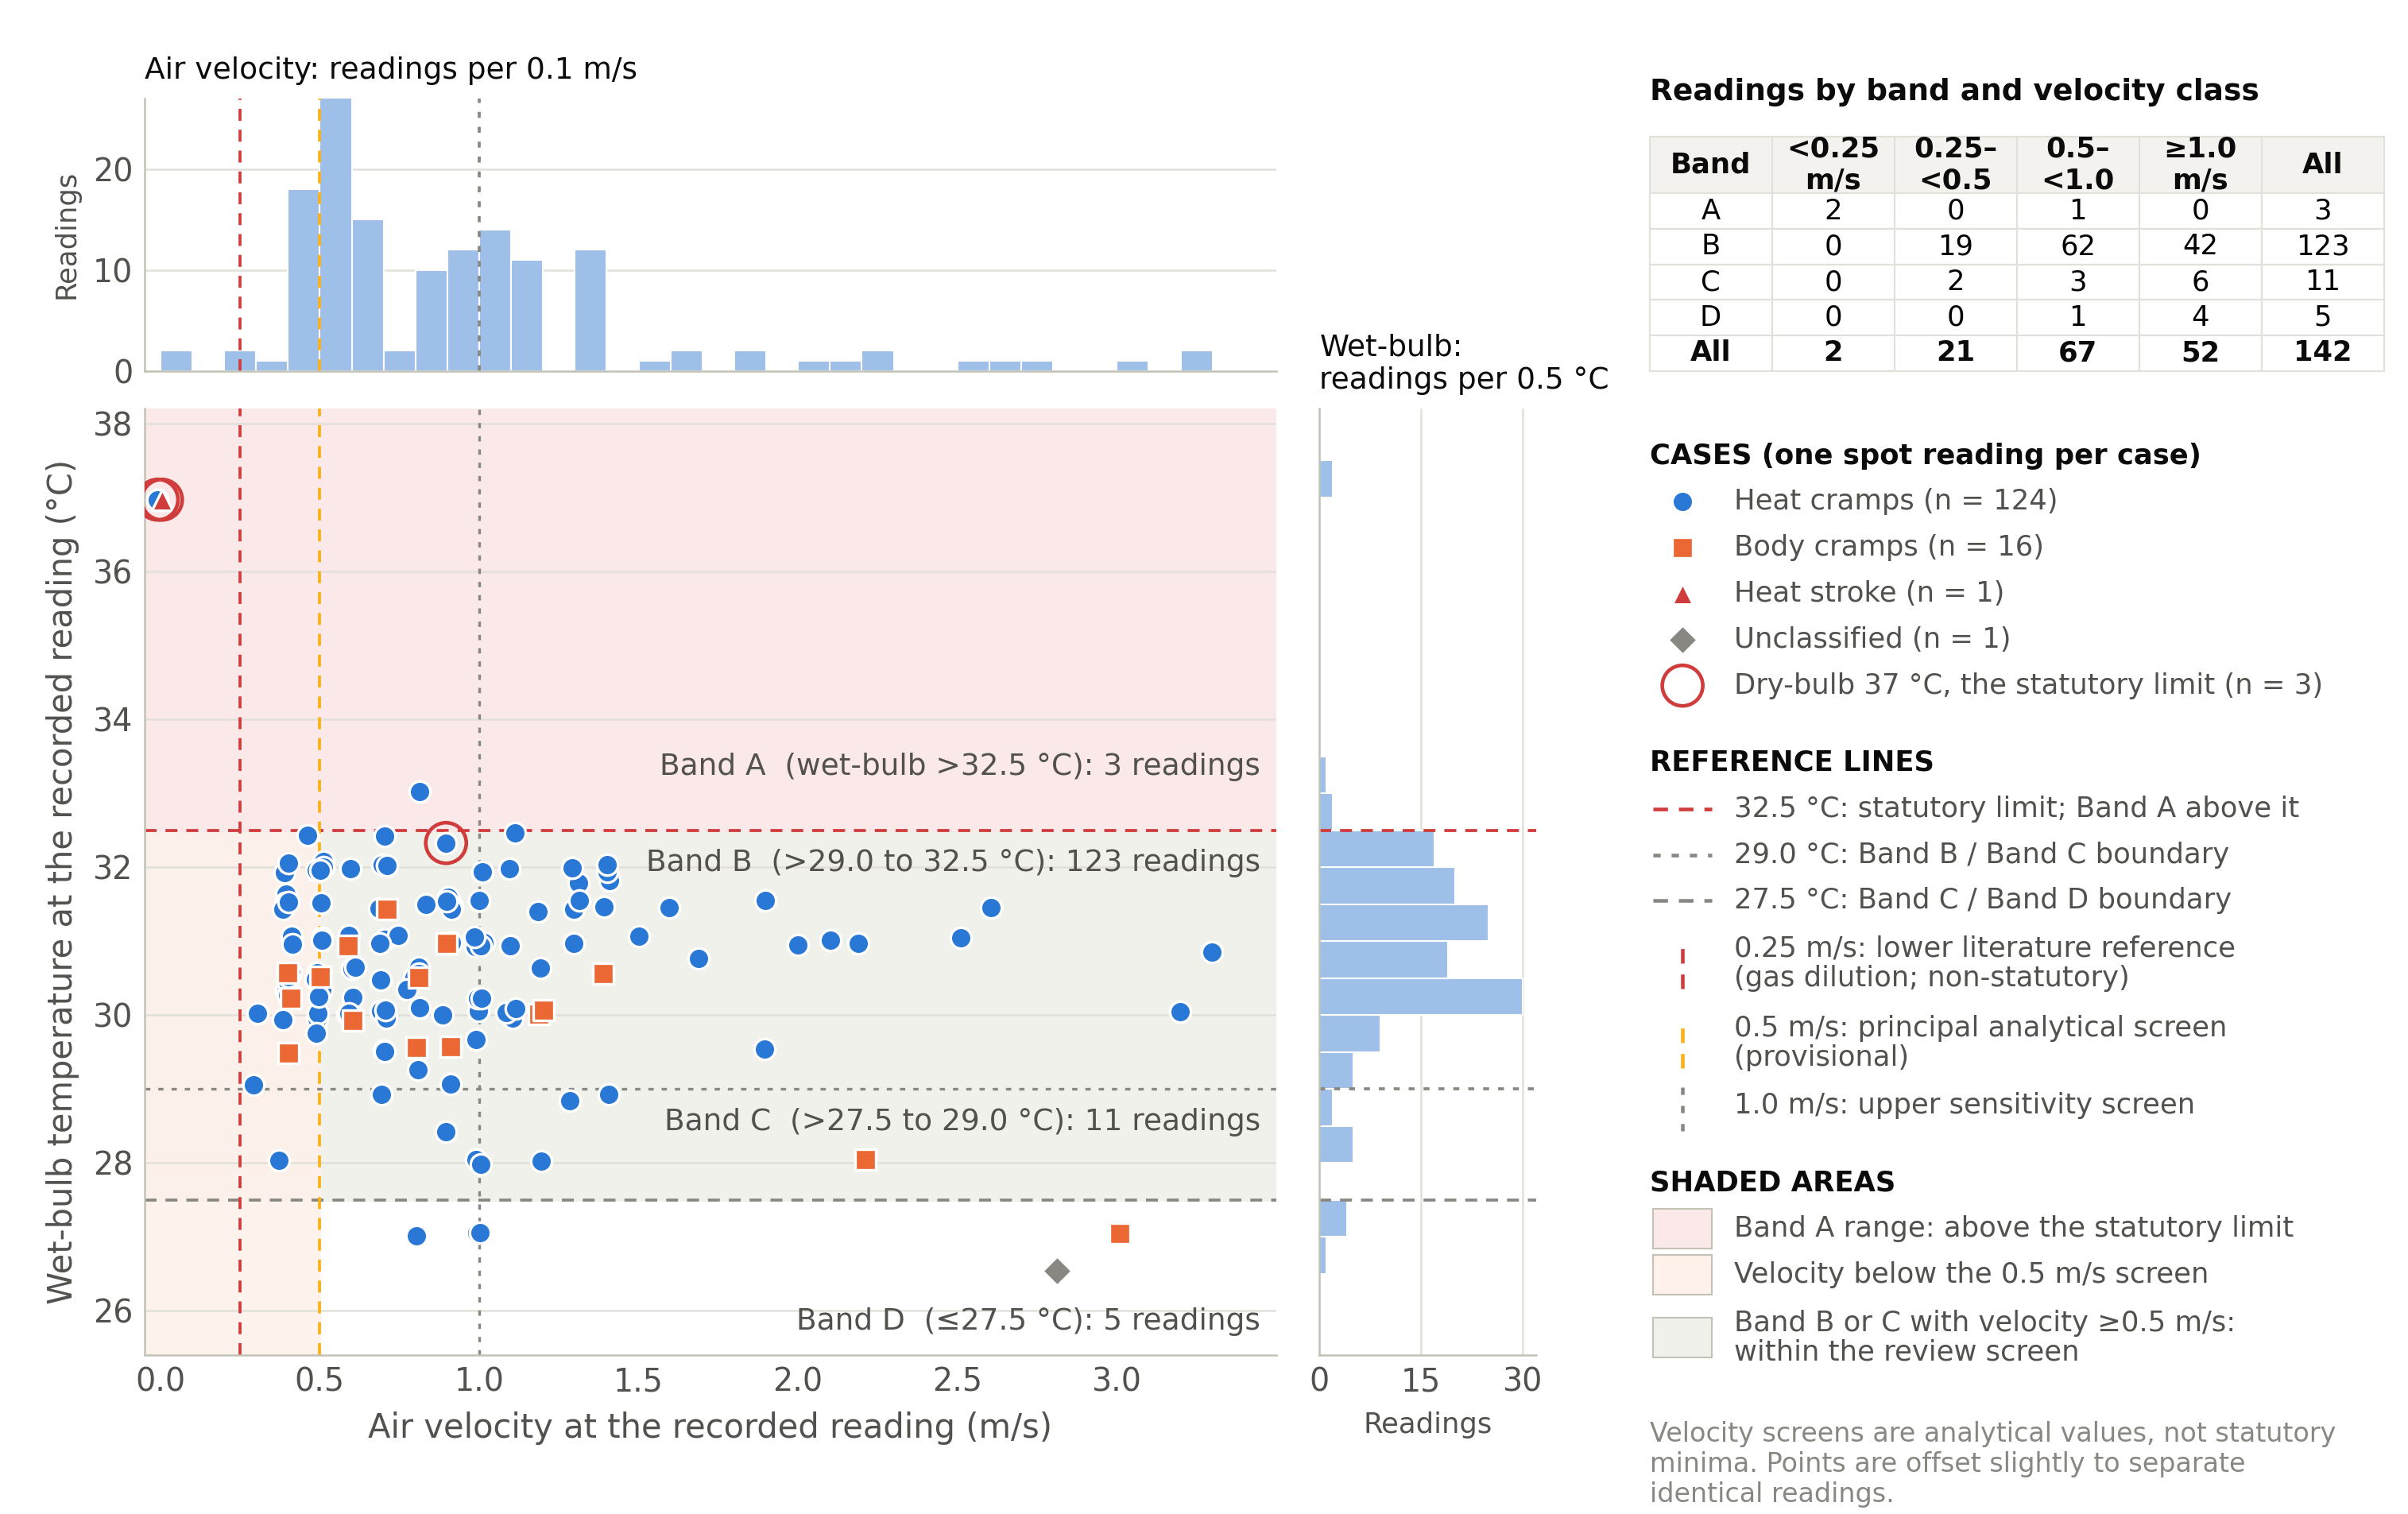

**Figure_2_weekday_profile.png**

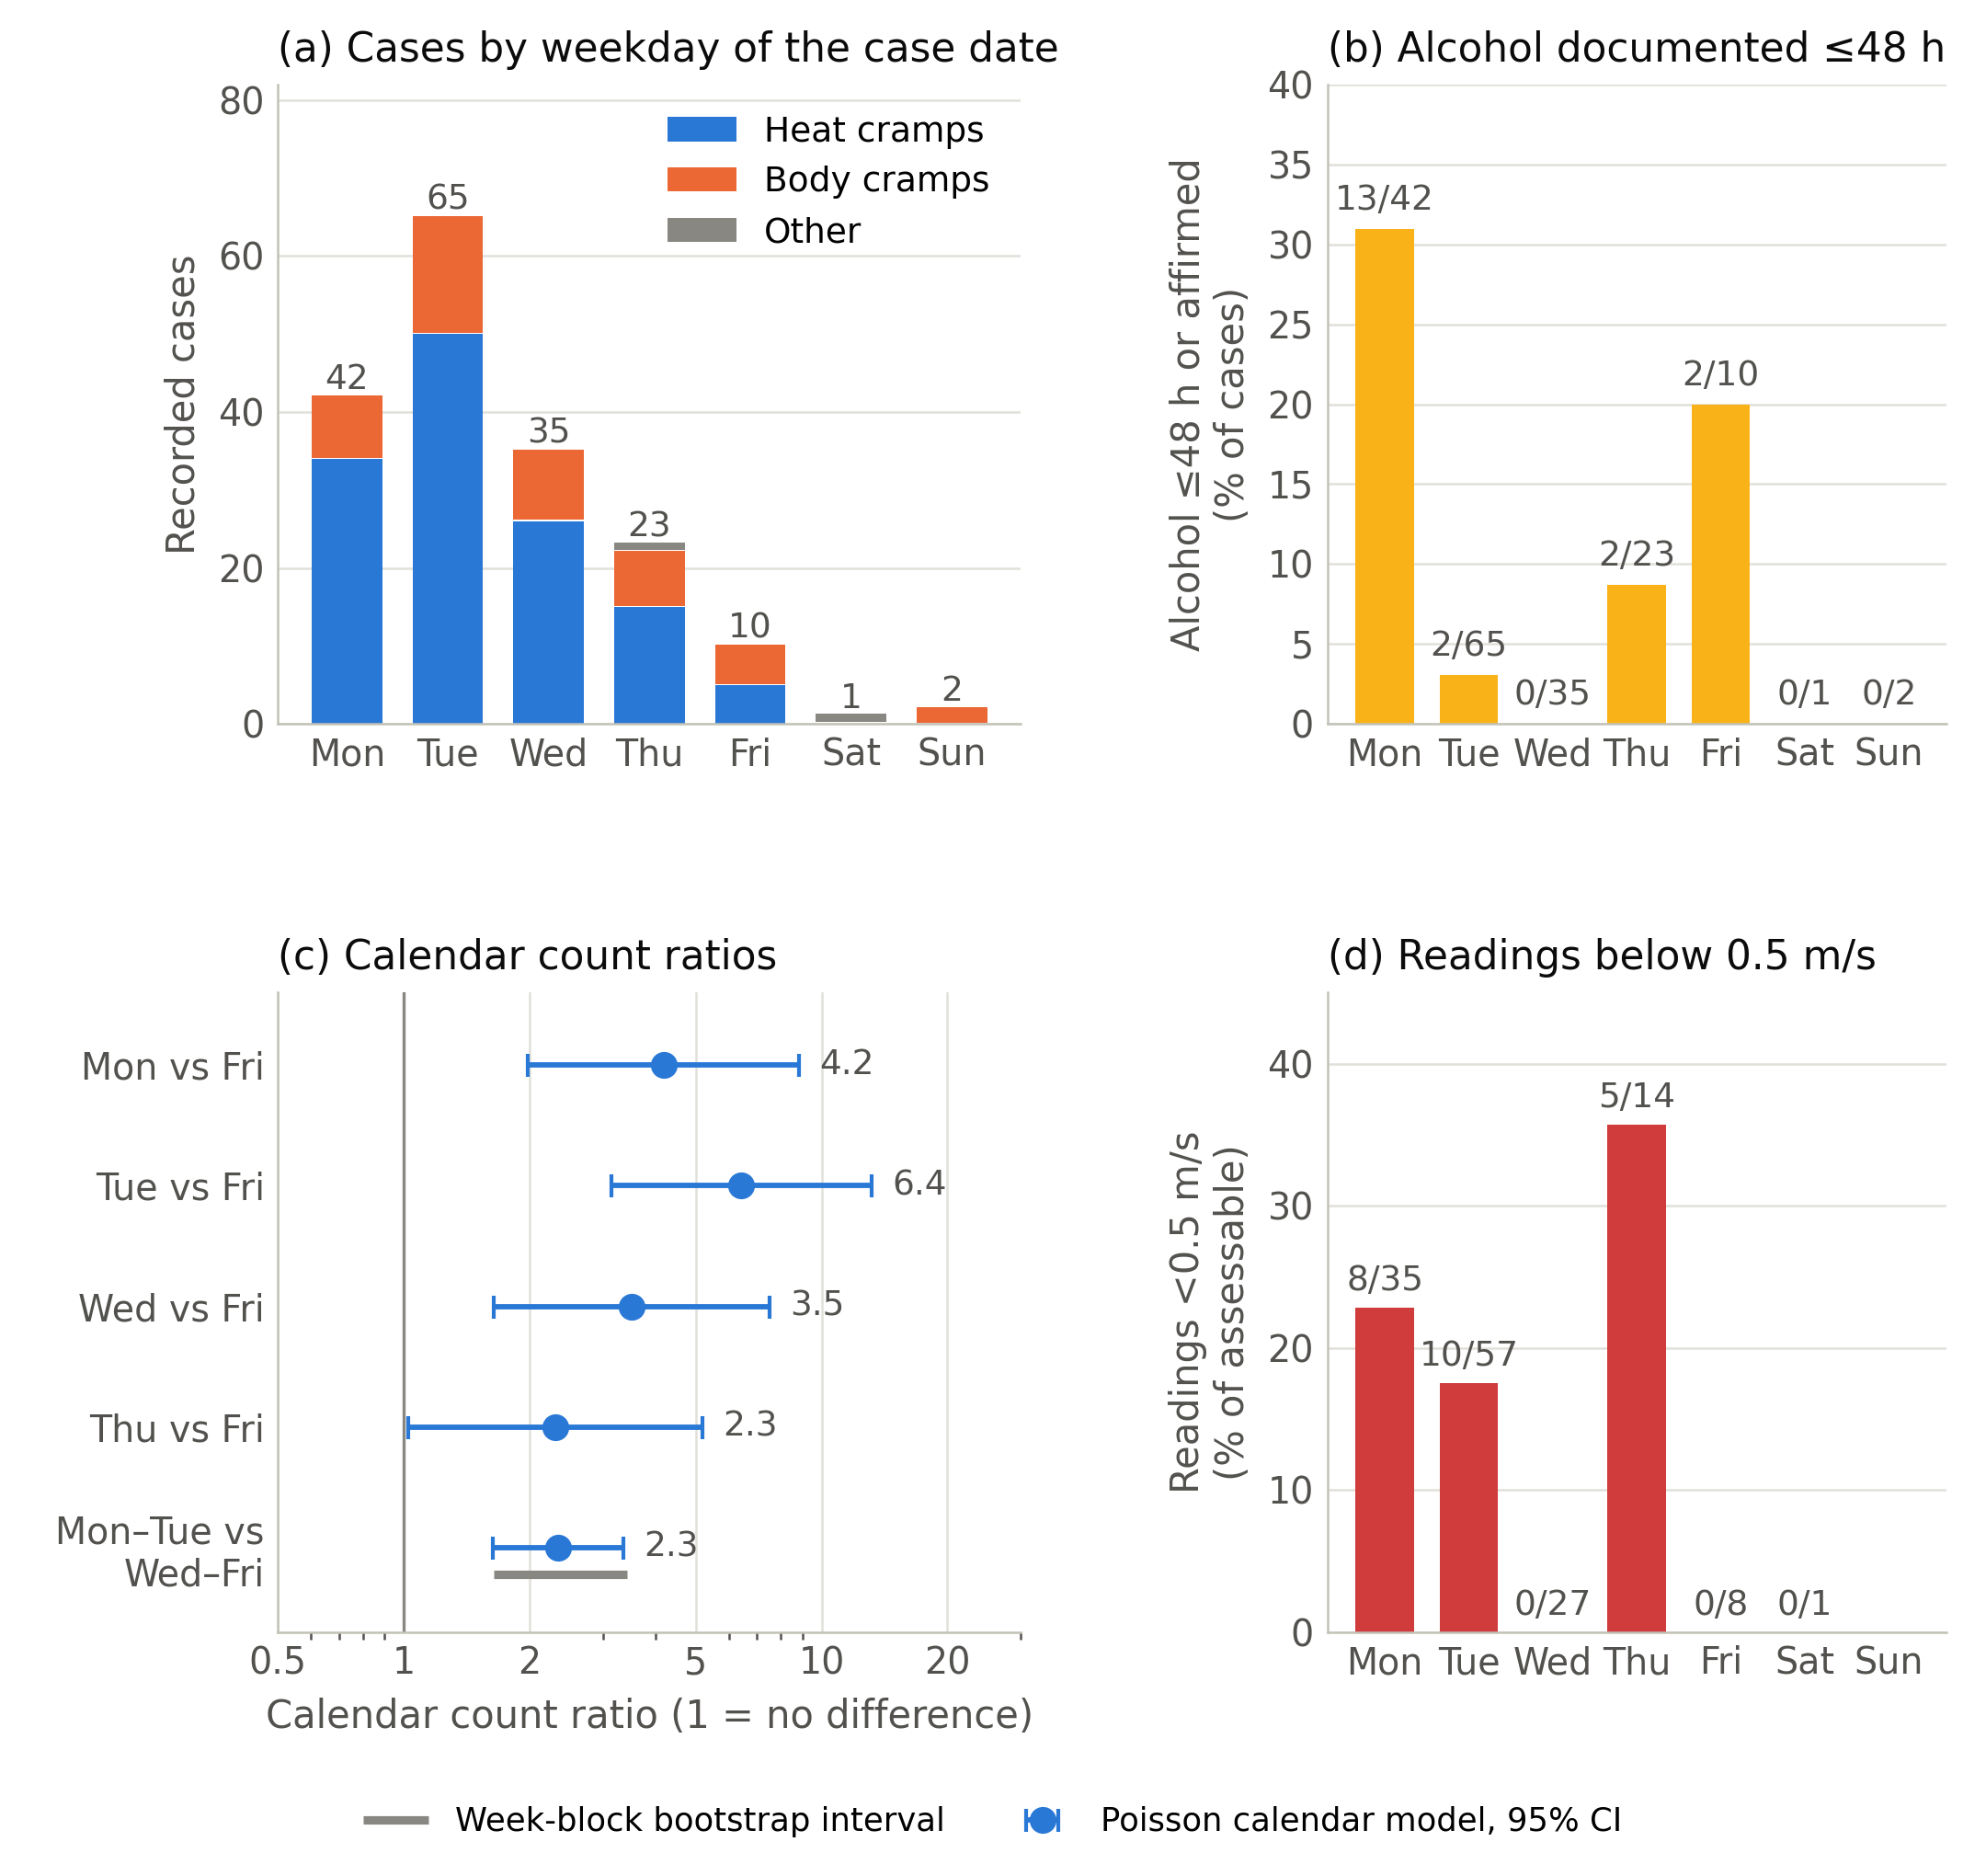

**Figure_3_monthly_cases_by_shaft.png**

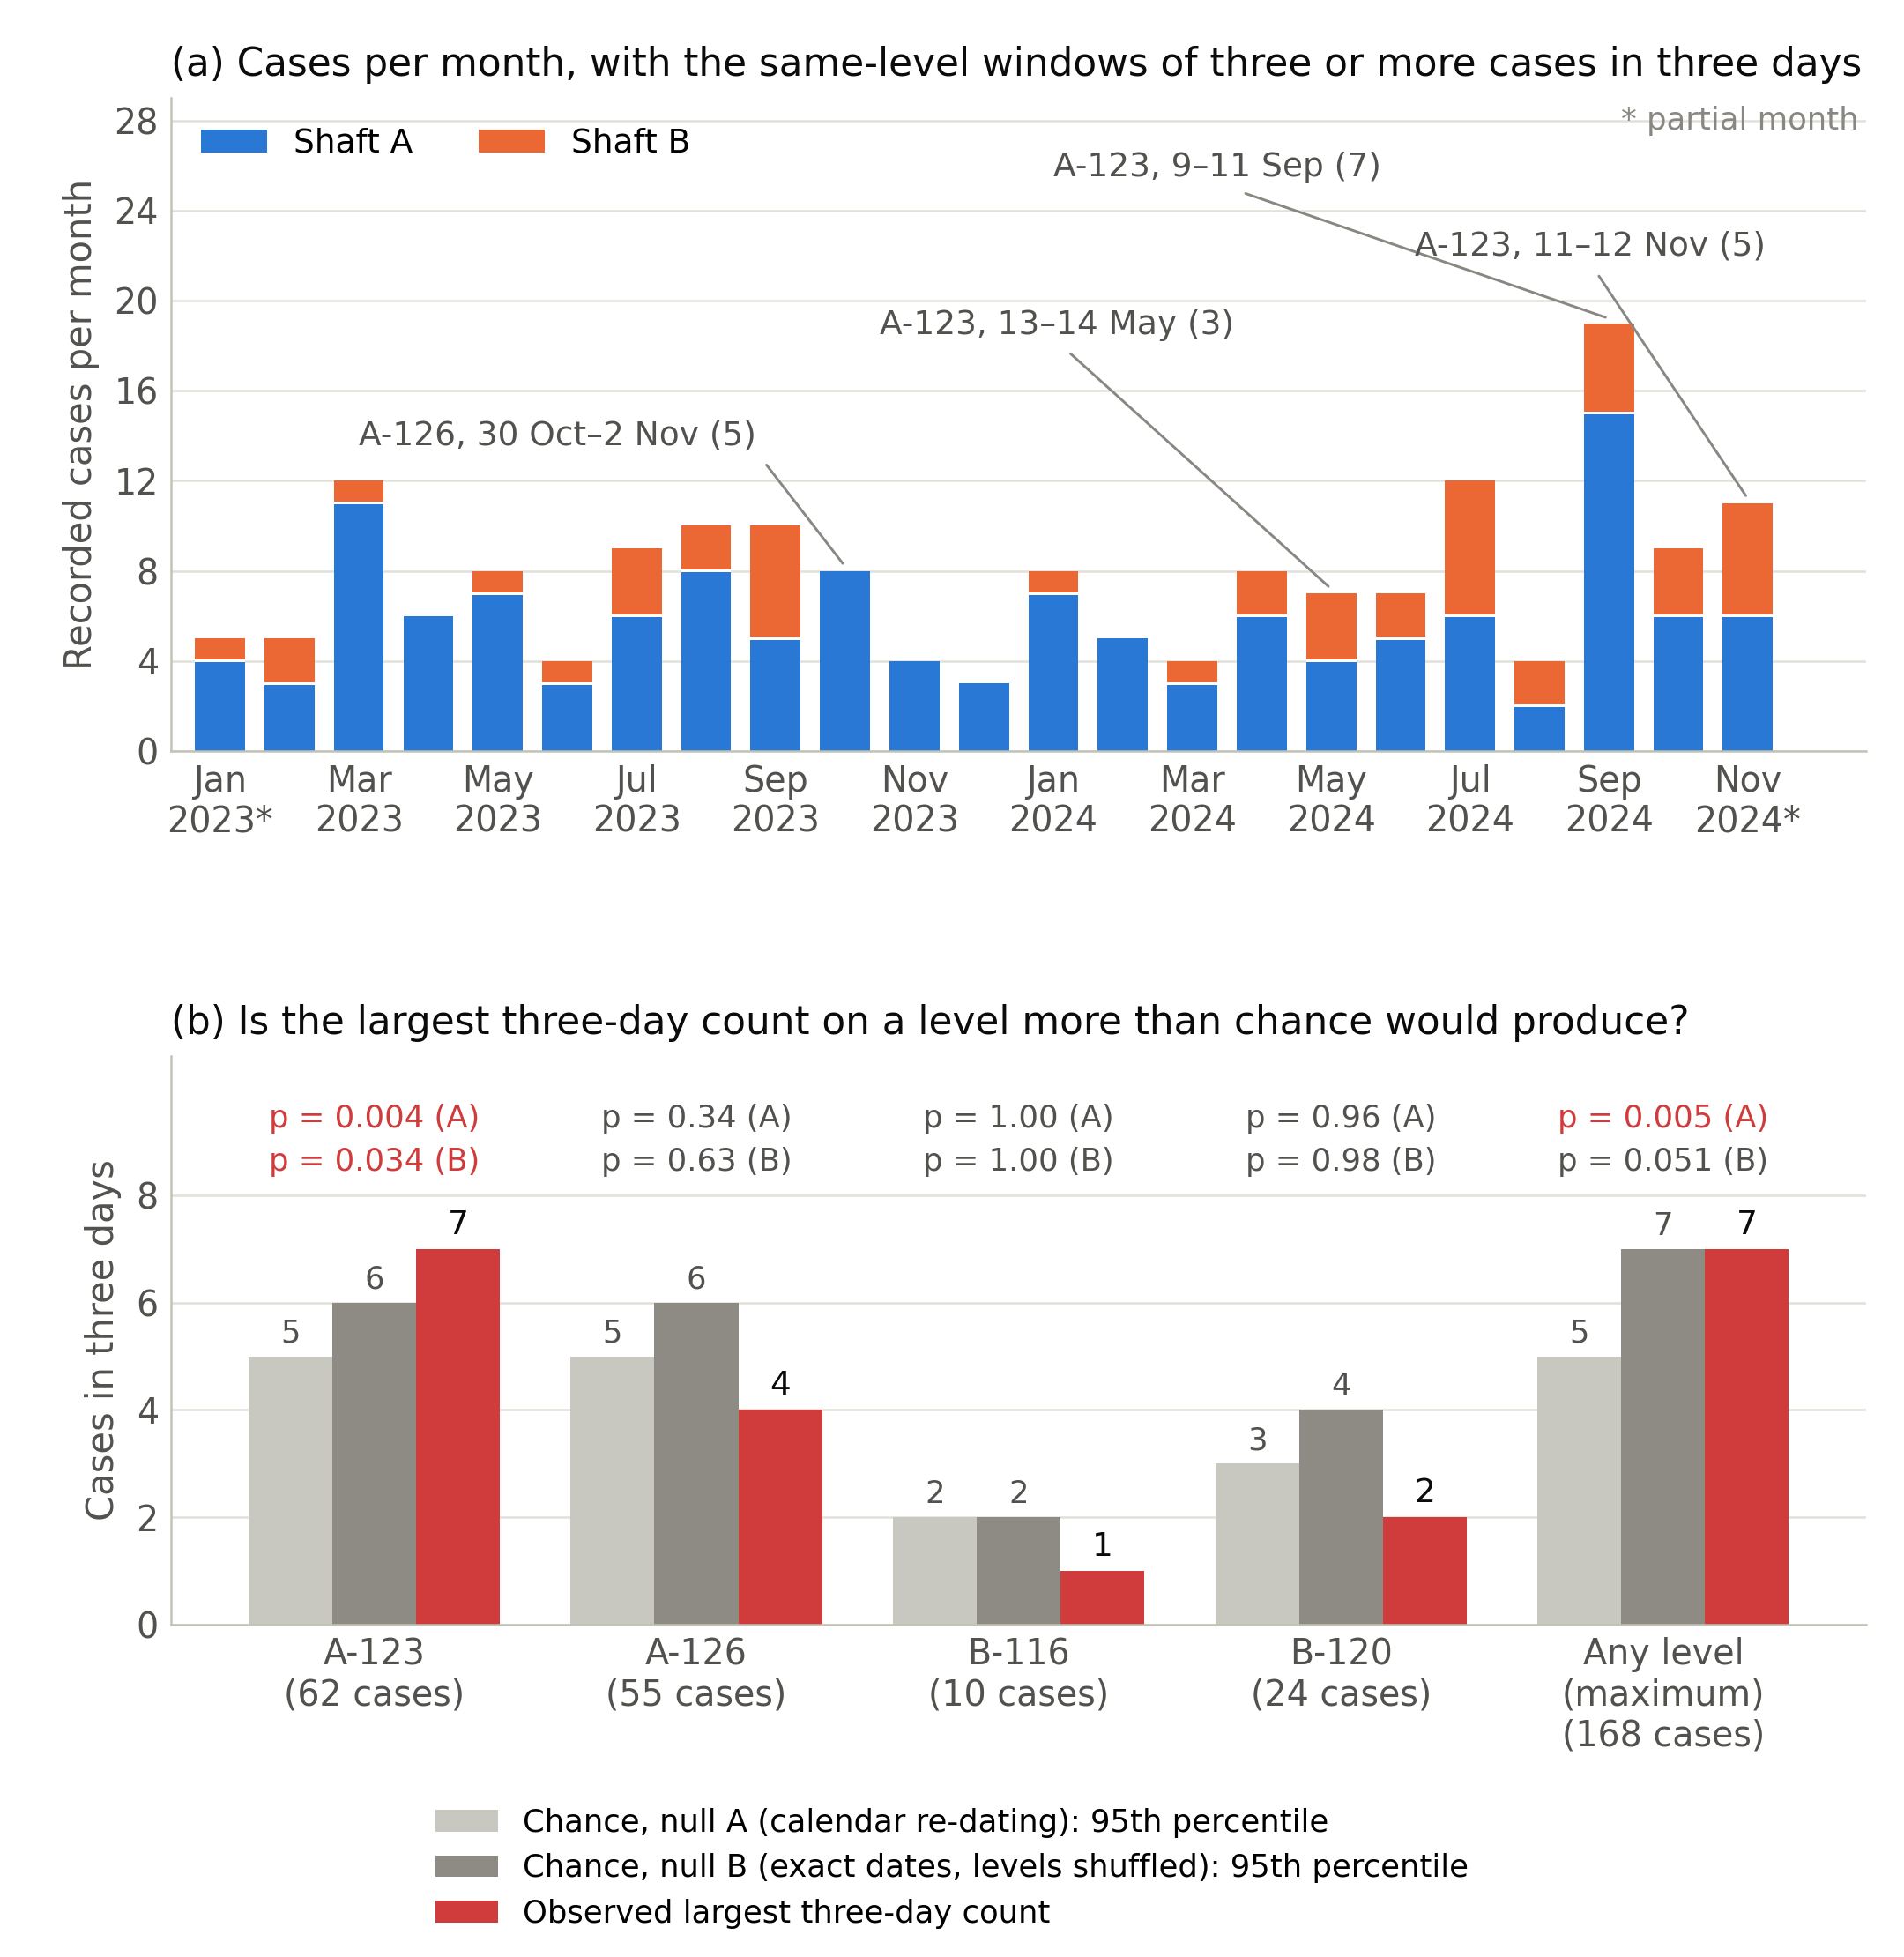

**Figure_4_raise_line_recurrence.png**

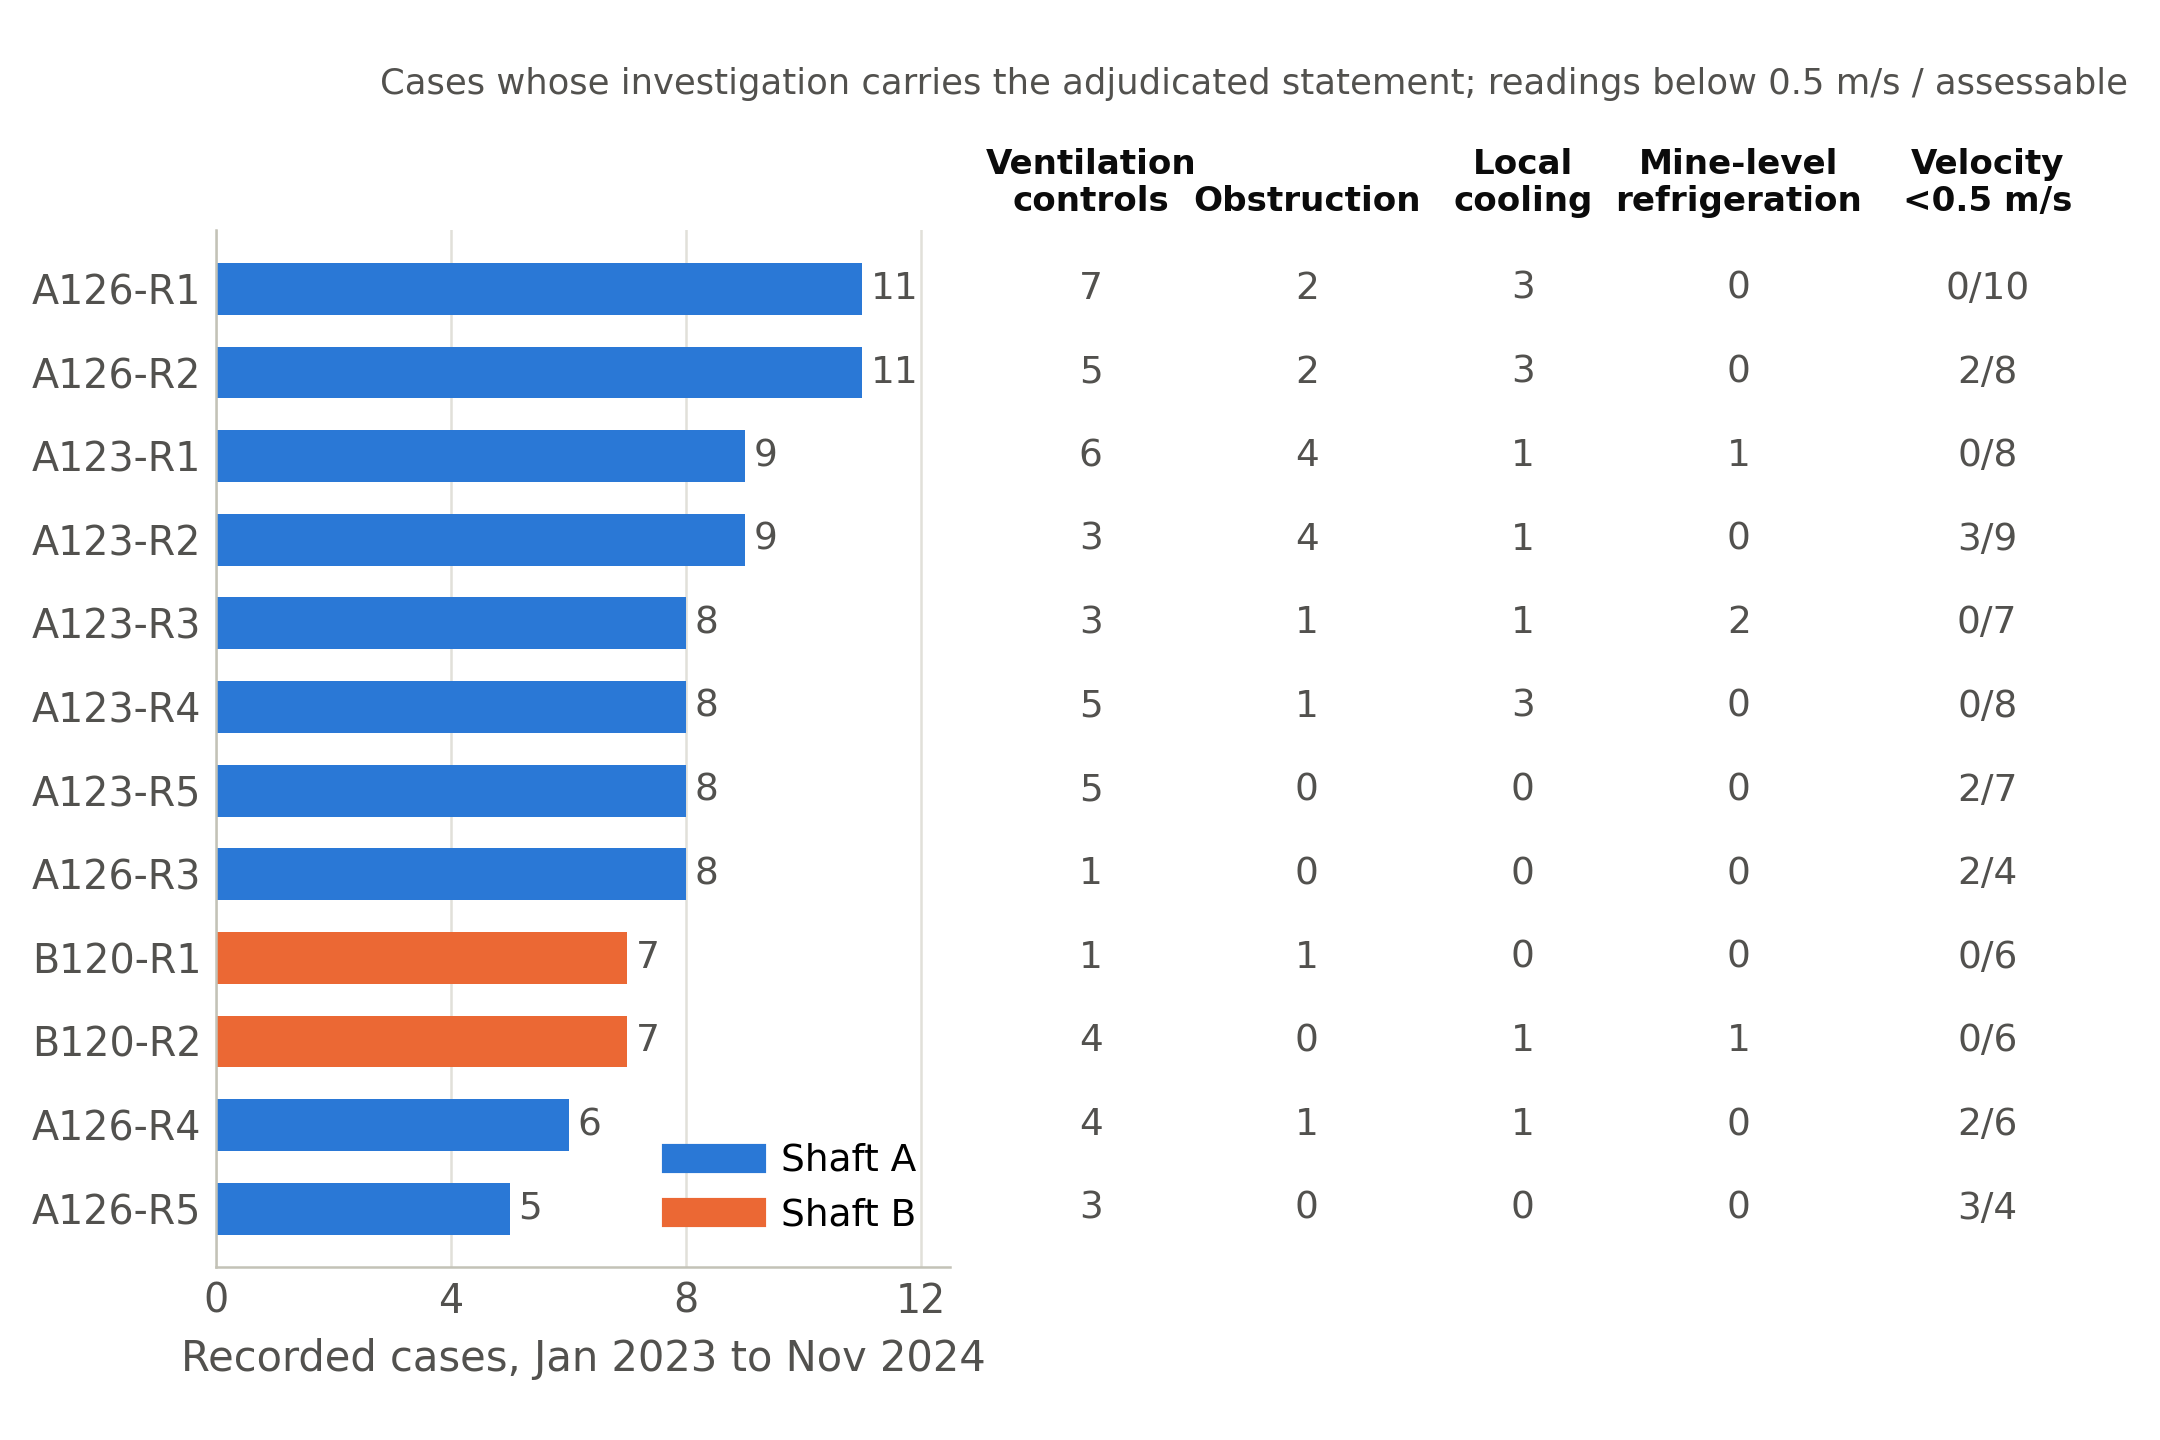

**Figure_5_coded_statements.png**

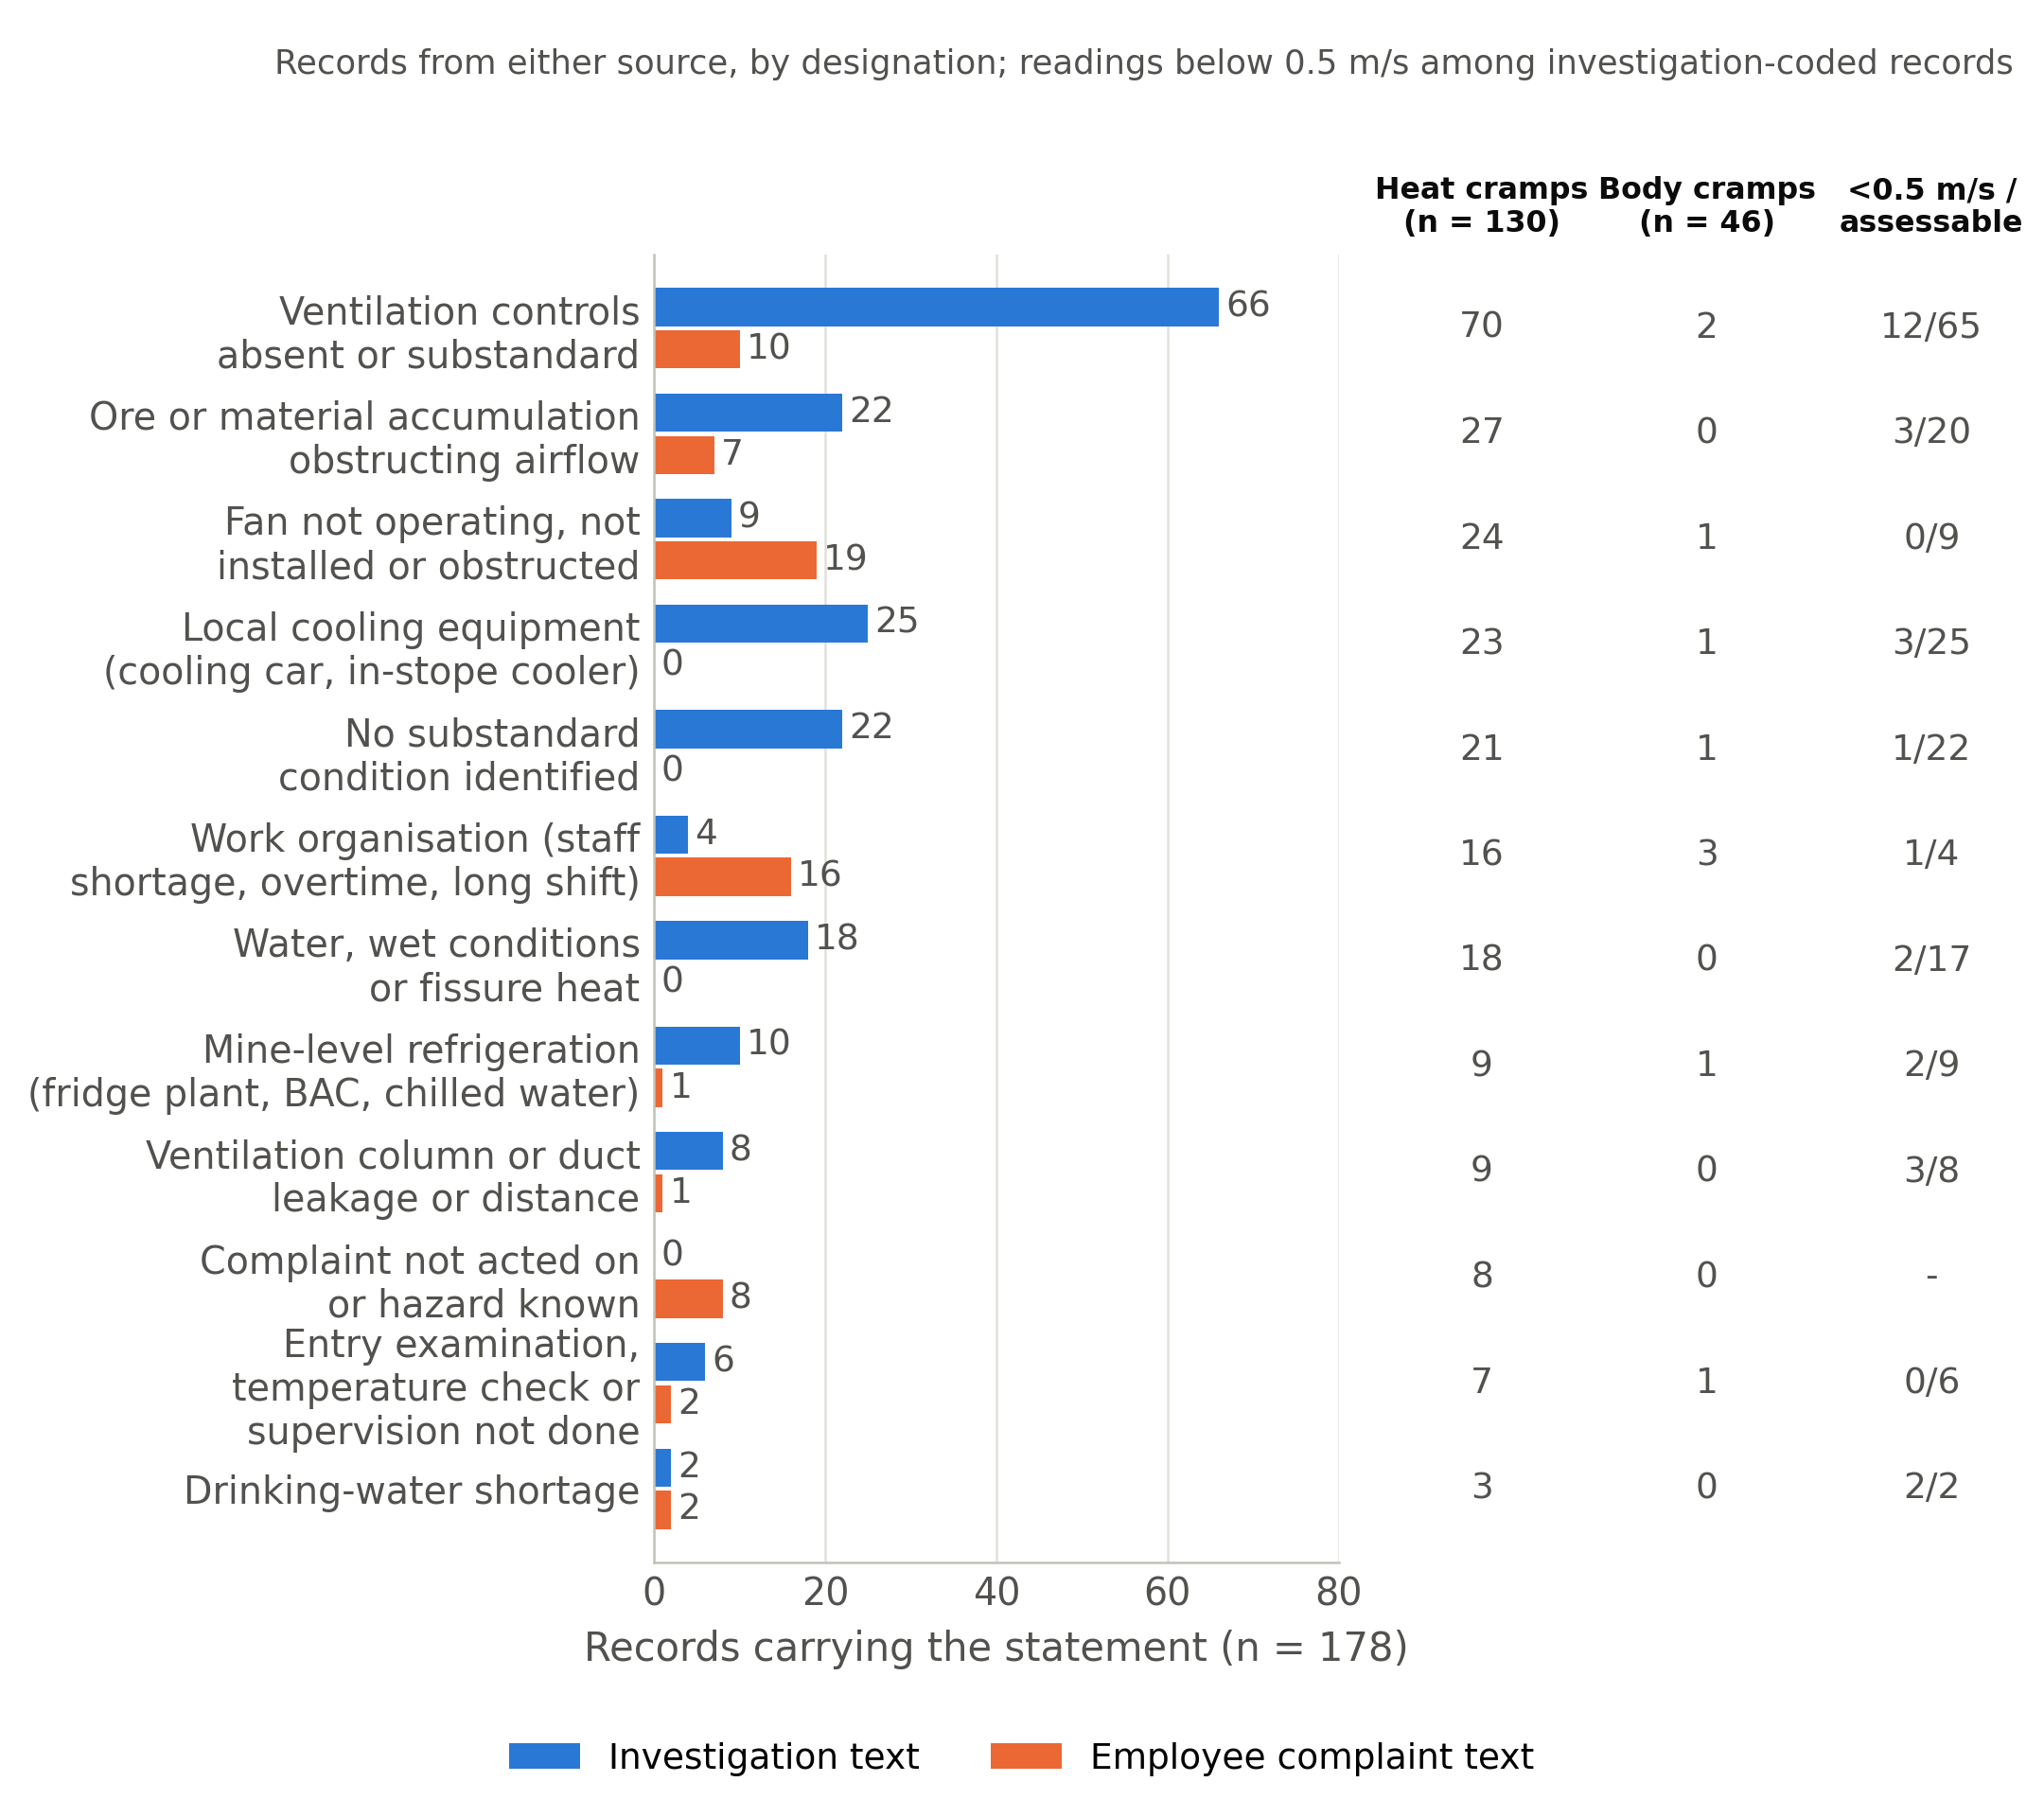

**Figure_6_worker_context_by_designation.png**

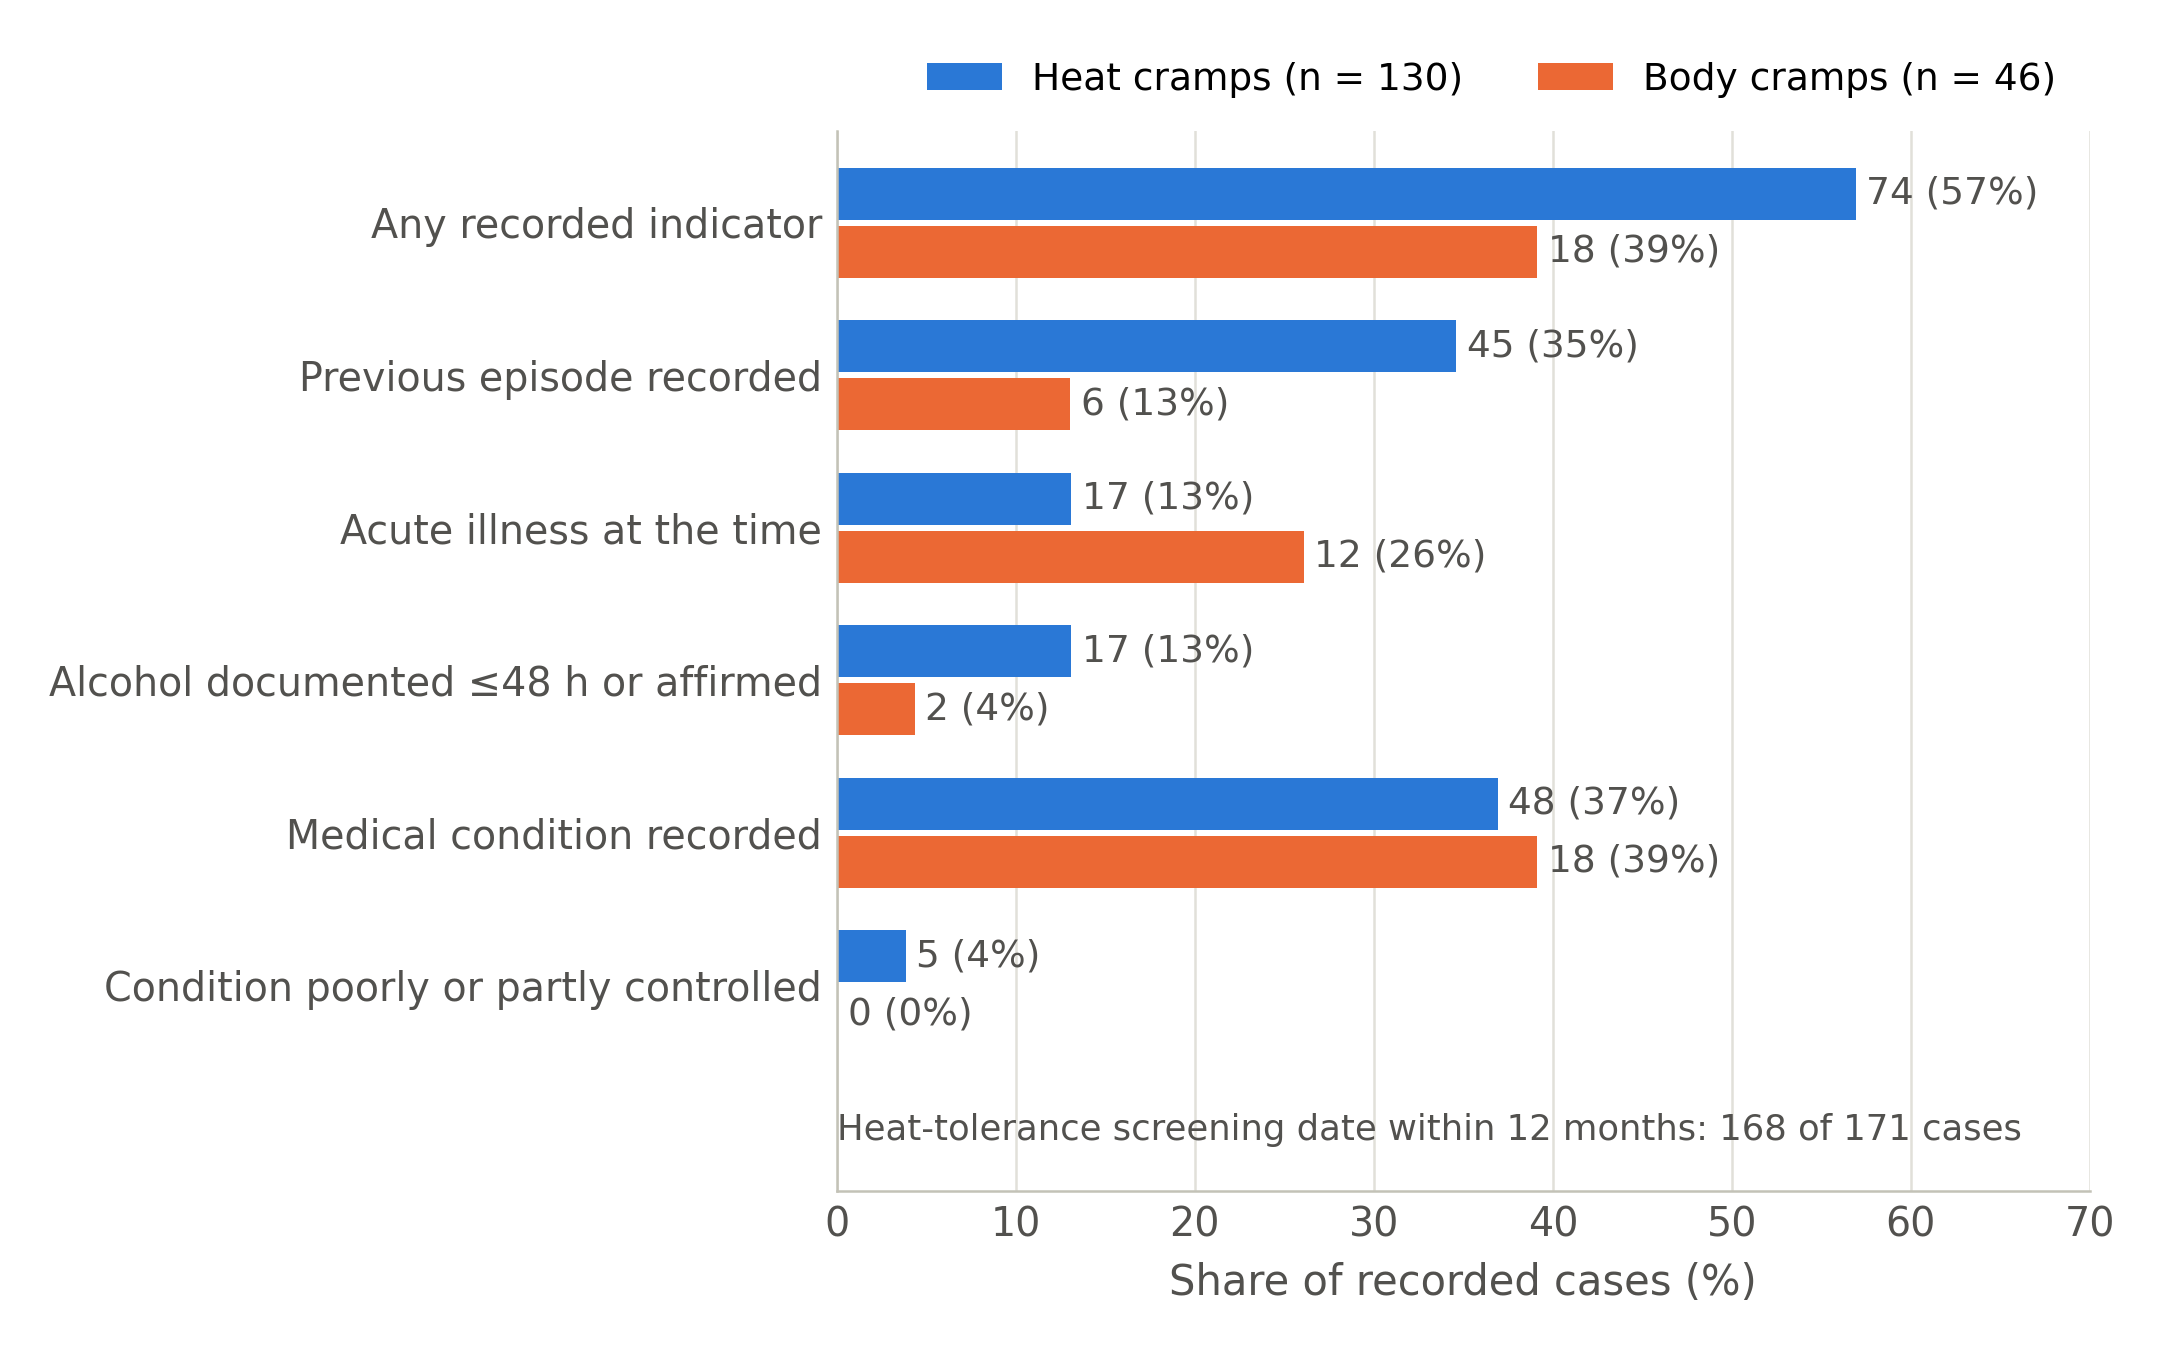

**Figure_7_CRA_integration.png**

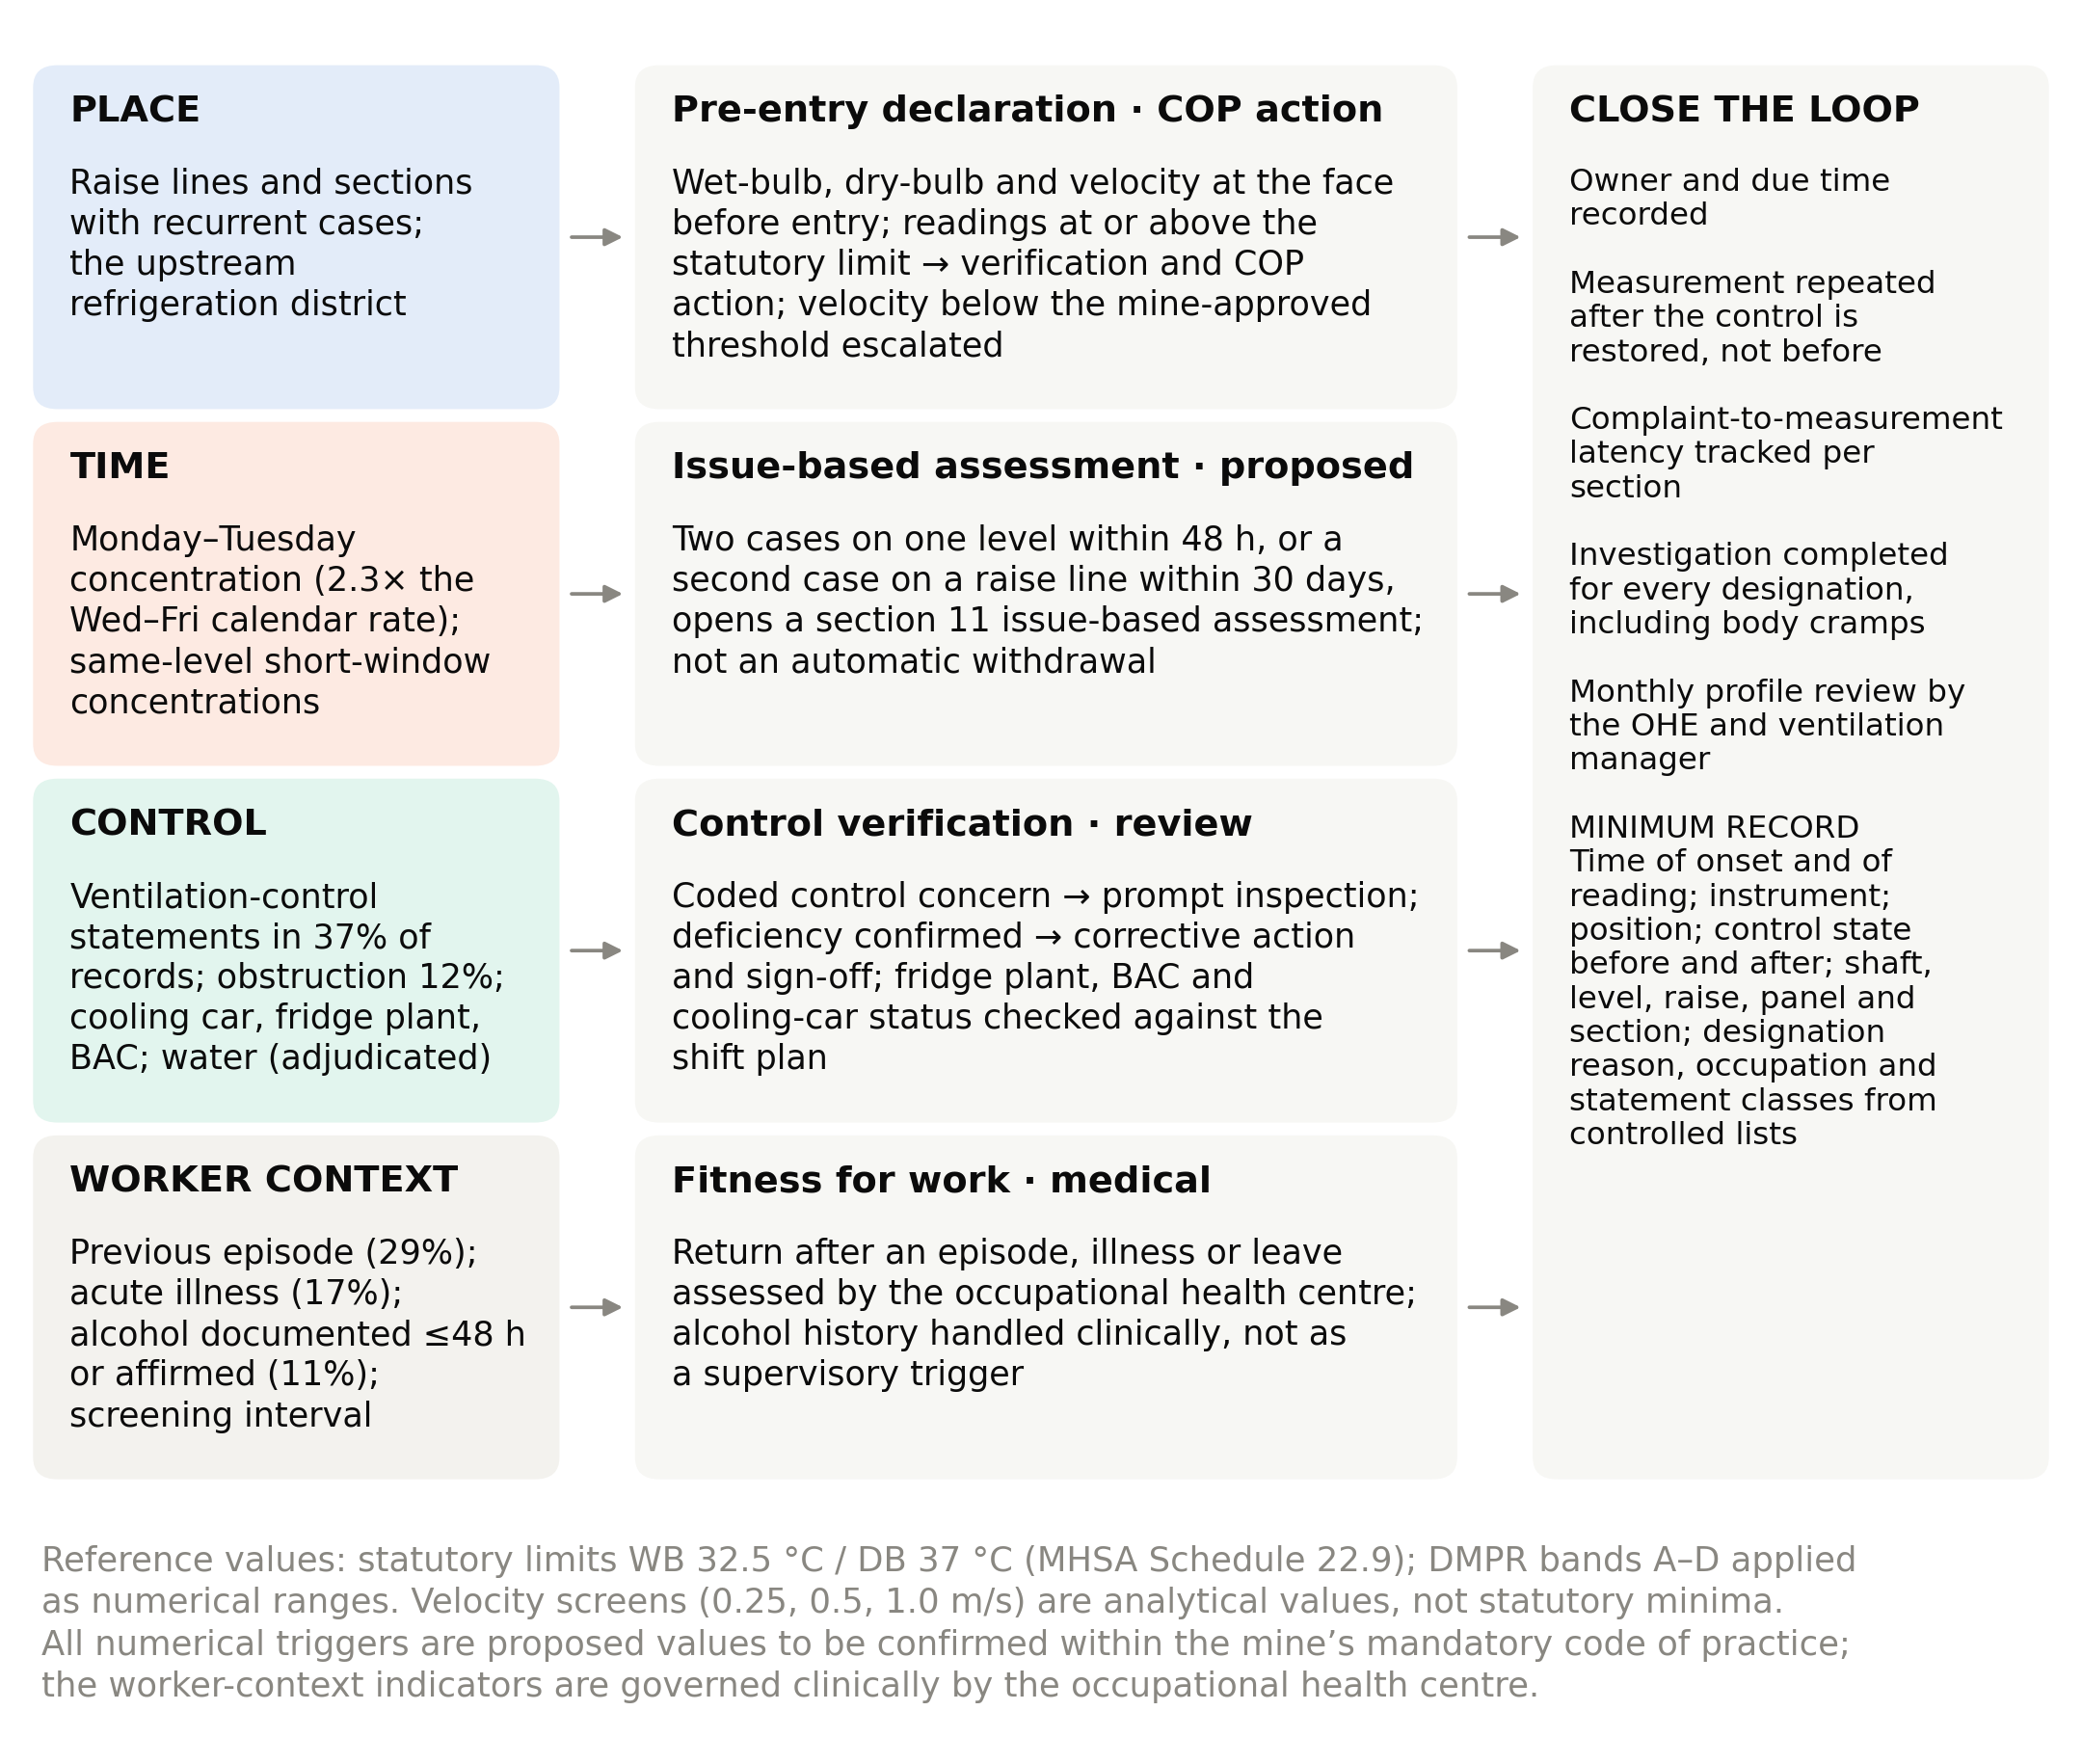

**Figure_8_hybrid_architecture.png**

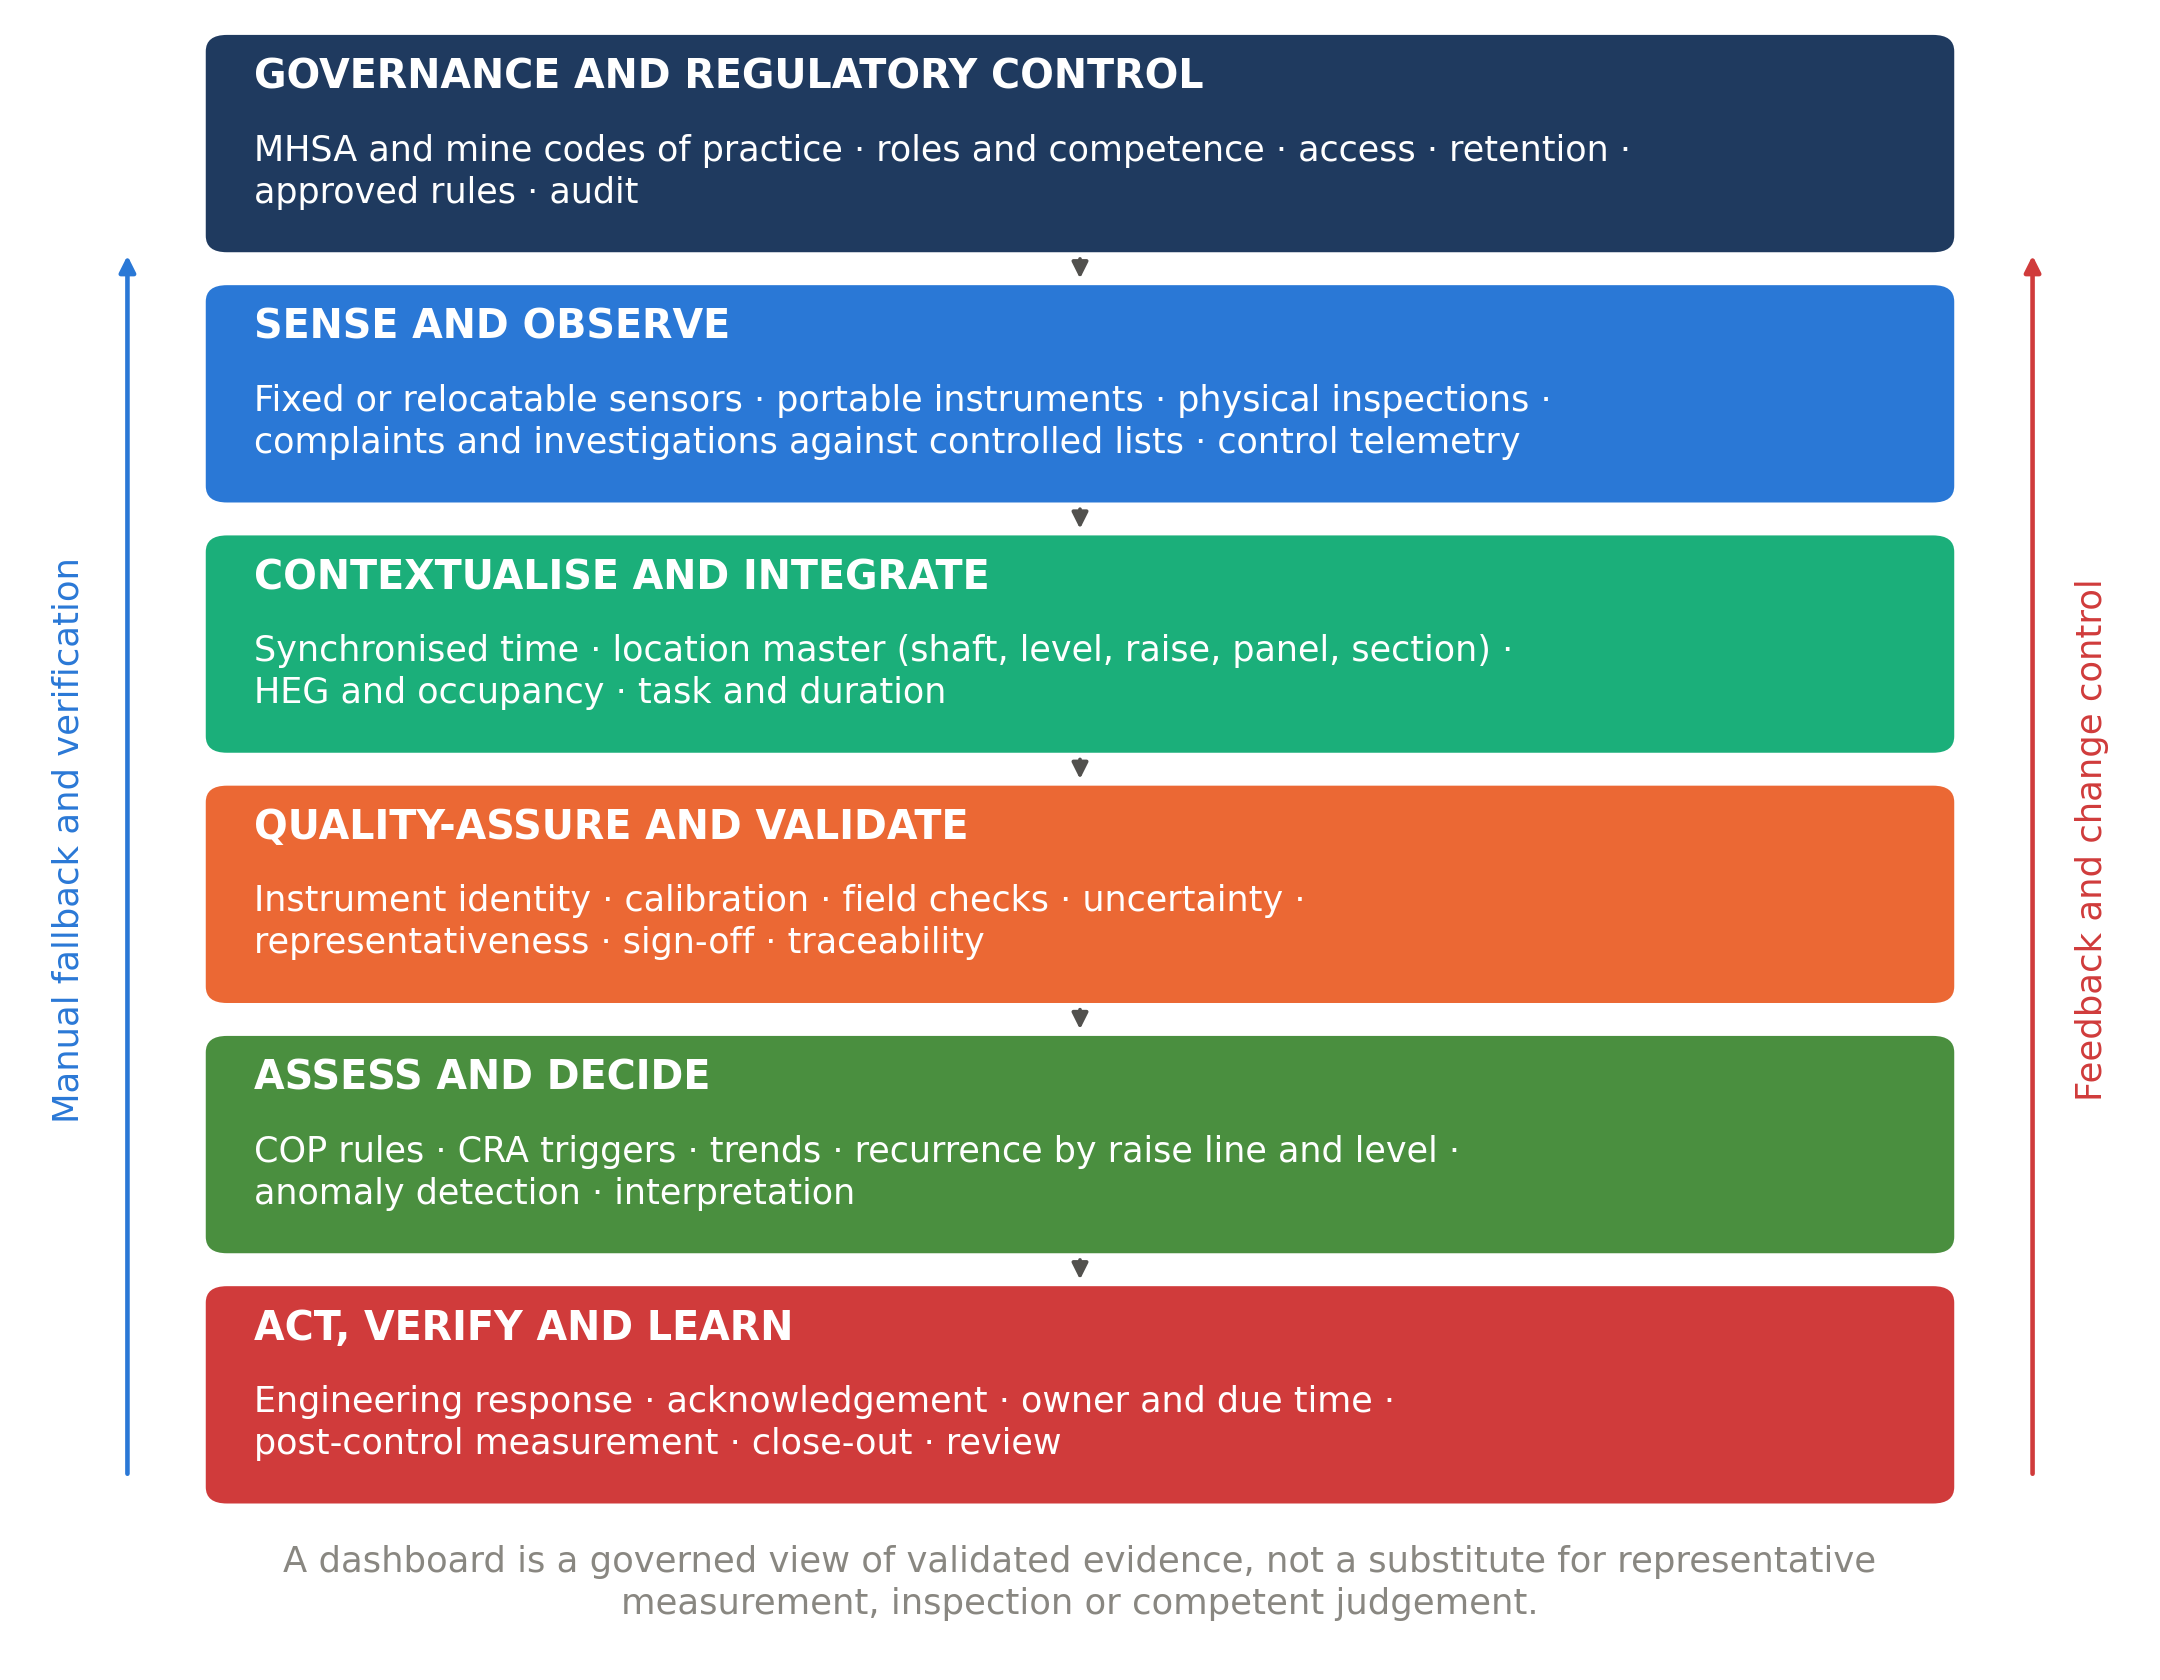

**Figure_9_historical_dashboard.png**

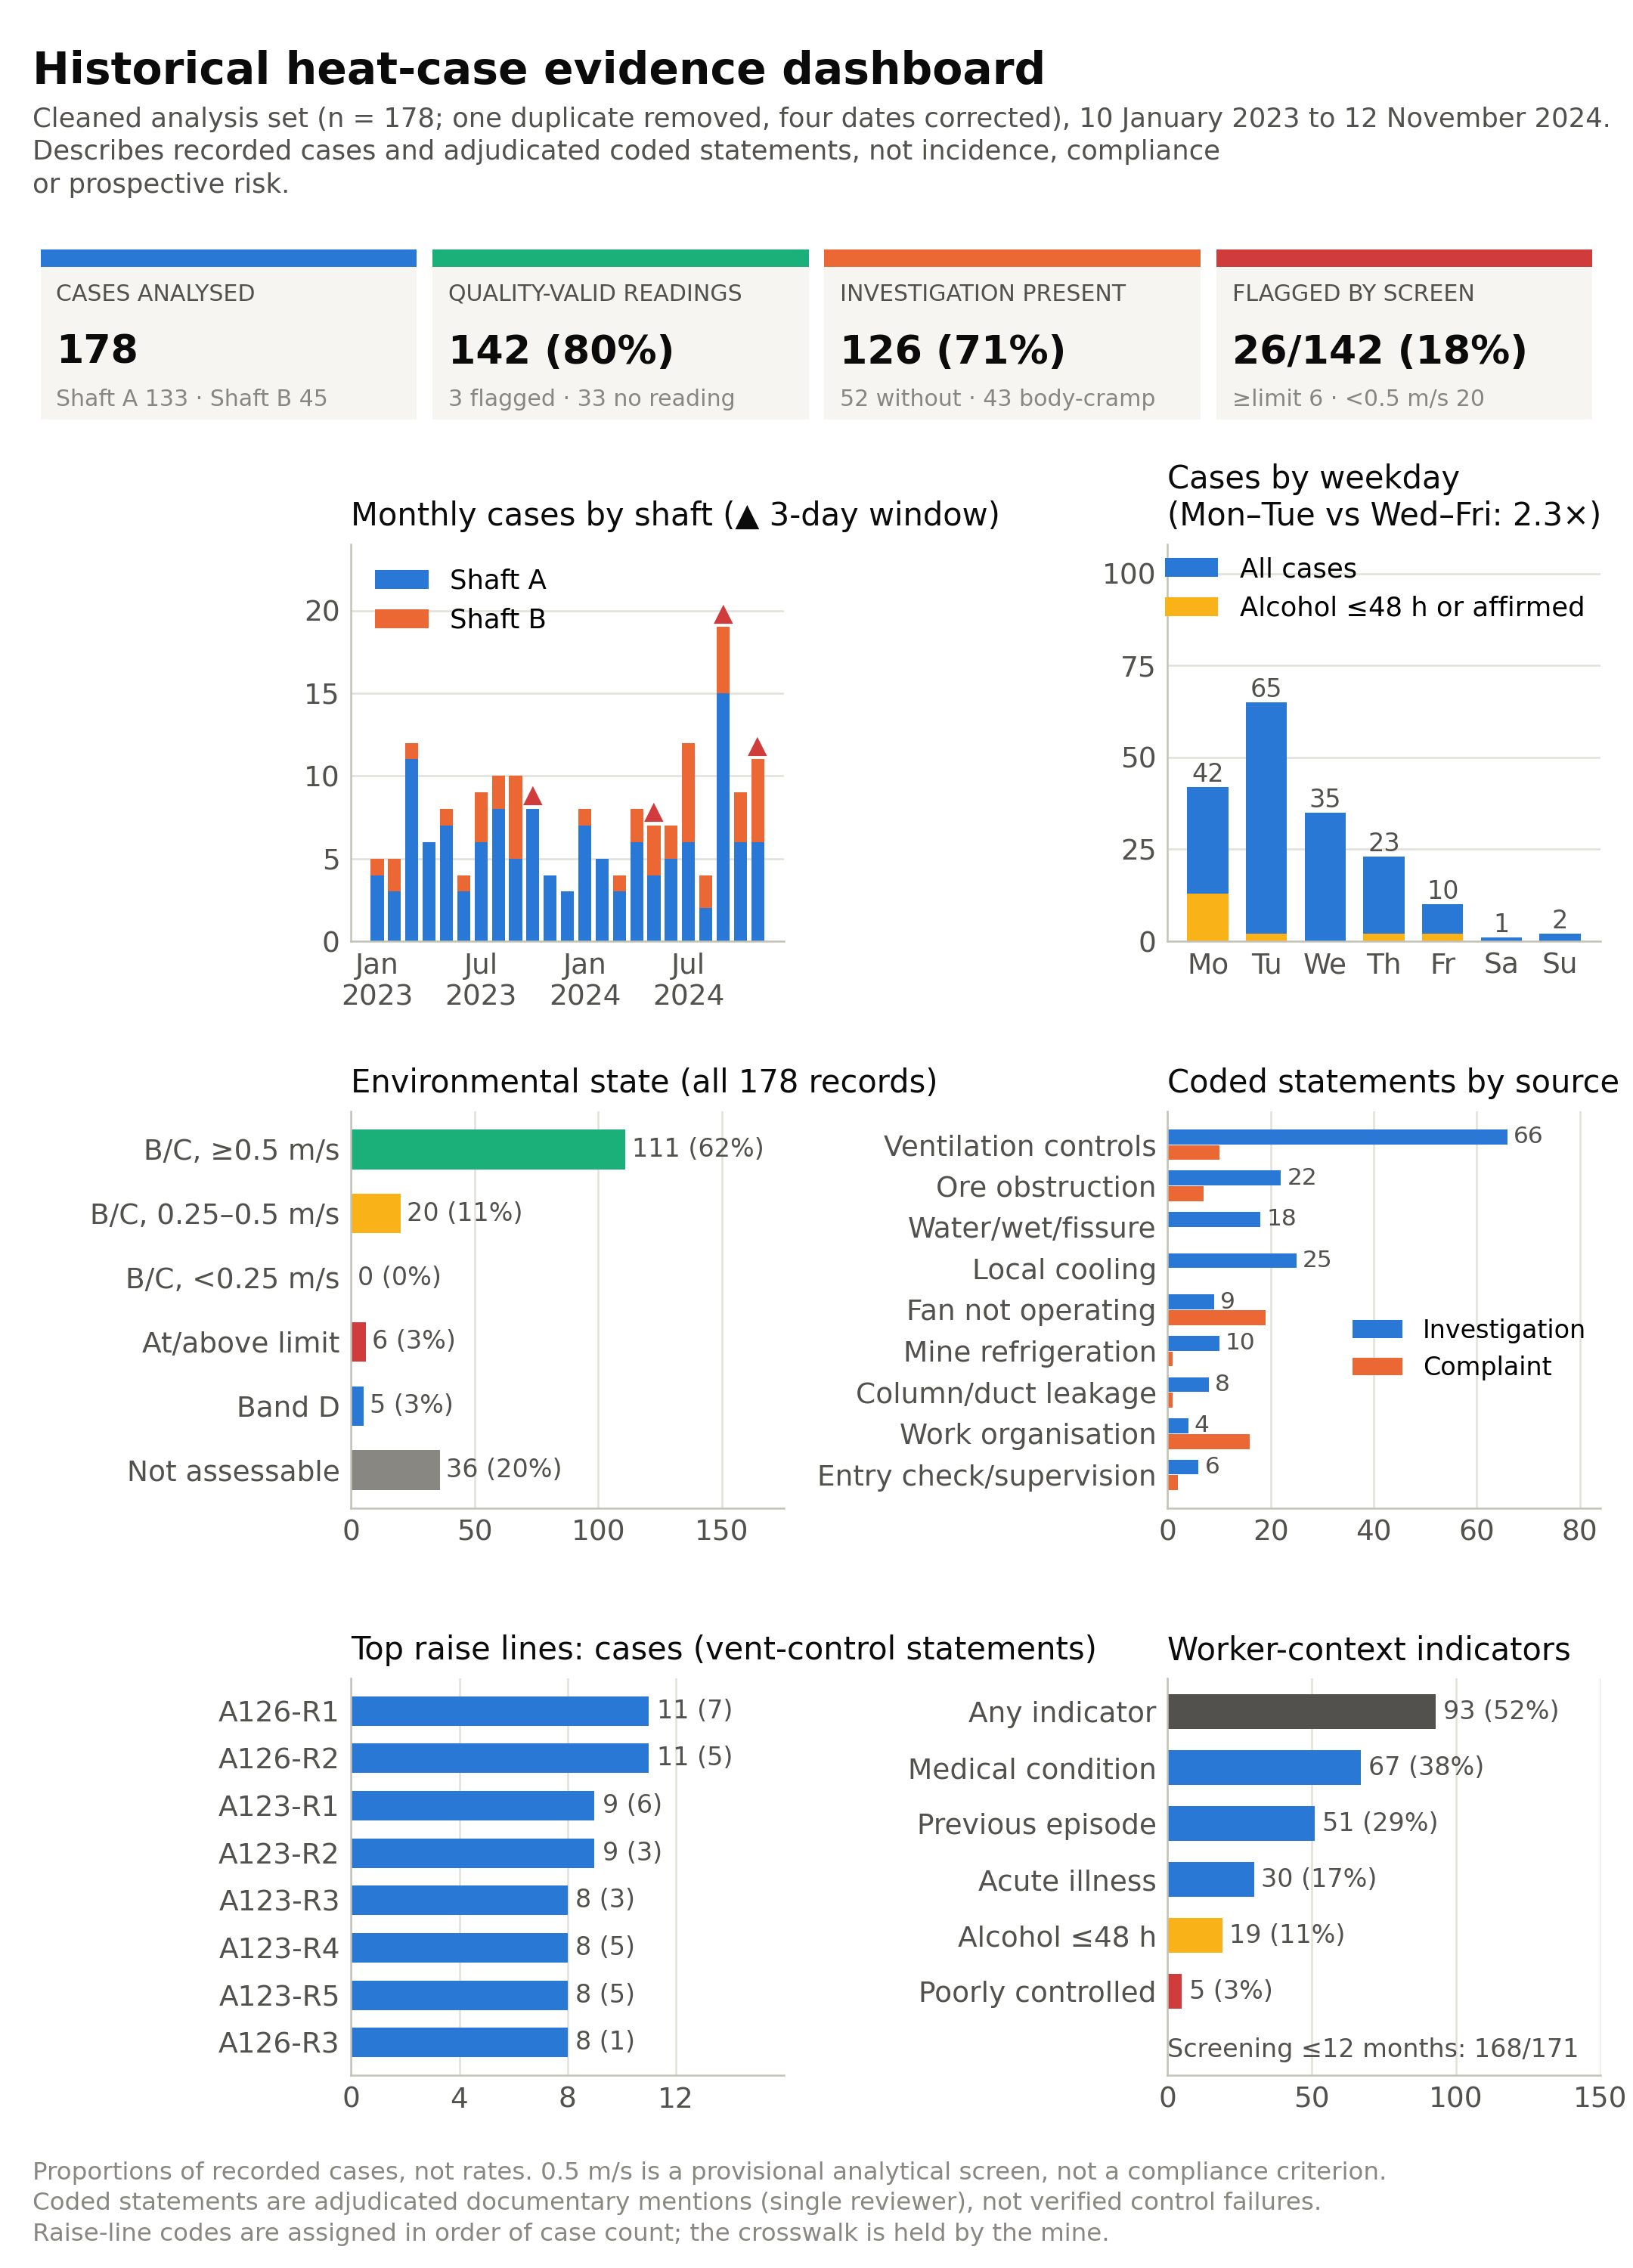

**Figure_10_future_state_dashboard_SYNTHETIC.png**

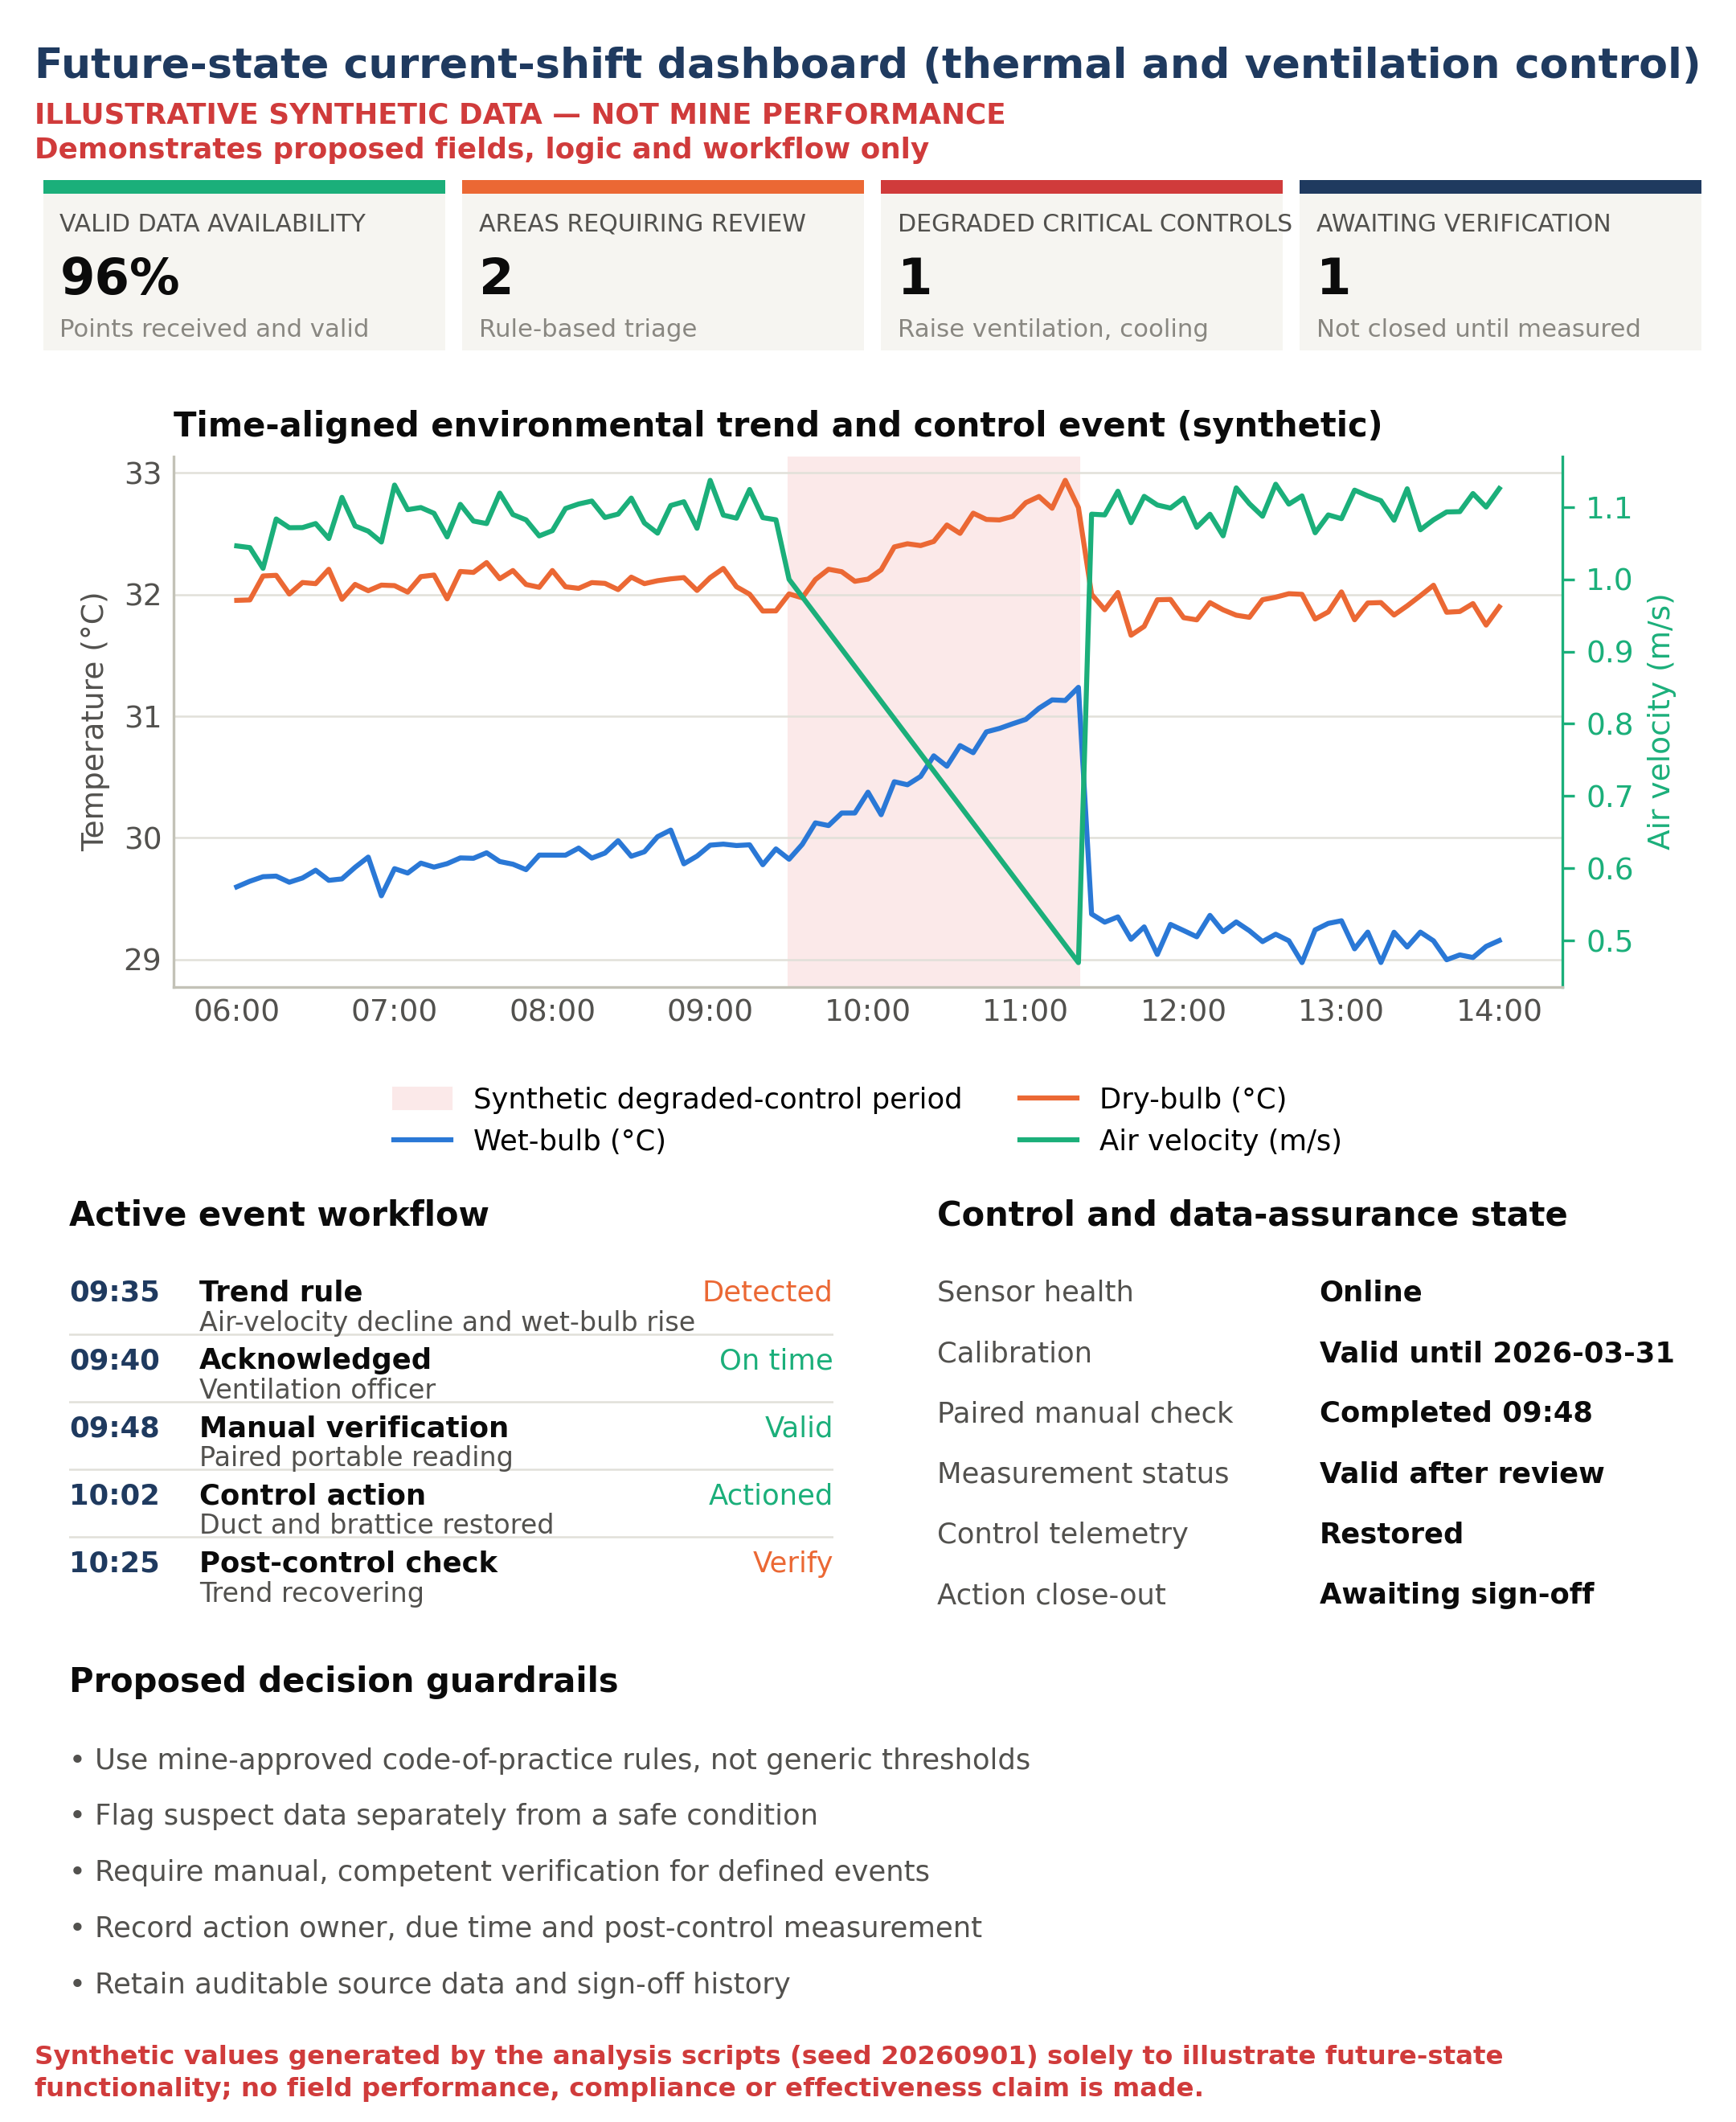

In [31]:
import runpy, glob
os.environ['DATASET'] = os.path.join(DATA, 'cases.csv')
runpy.run_path('figures_v4.py', run_name='__main__')
from IPython.display import Image, display
for f in sorted(glob.glob('/content/figures/Figure_*.png'), key=lambda p: (len(os.path.basename(p).split('_')[1]), os.path.basename(p))):
    display(Markdown(f'**{os.path.basename(f)}**')); display(Image(filename=f, width=900))

## 10. The adjudication record

The adjudication of the 275 automated matches of the refined rules (254 accepted, 13 rejected, 8 recoded; 29 accepted matches marked ambiguous) is recorded match by match, with the decision, the evidence strength and the reason, in `coding_audit_ADJUDICATED.csv` (and, for the register as recorded, `coding_audit_as_recorded_ADJUDICATED.csv`). Those files contain the narratives and are held by the mine and the author. In `register` mode the cell below summarises the decisions by source field and class (no narrative text is printed); in `dataset` mode it prints the decision counts from `adjudication_version.json` if that file sits beside the datasets.

**Caution.** The adjudication was performed by a single reviewer applying the class definitions; no blinded re-coding by an independent occupational hygienist or ventilation engineer was performed, so inter-rater agreement is unknown. The function `apply_adjudication.validation_agreement()` computes positive and negative agreement, confirmation rates and kappa should a blinded re-coding of the validation sample be done later.

In [32]:
if MODE == 'register':
    for tag in ('analysis set',):
        done = pd.read_csv(os.path.join(SOURCE, 'coding_audit_ADJUDICATED.csv'), dtype=str).fillna('')
        done['decision'] = done['adjudication_decision'].str.lower().replace('', 'pending')
        display(Markdown(f'**Decisions by source field and provisional class ({tag})**'))
        display(pd.crosstab([done.source_field, done.provisional_category], done.decision, margins=True))
        rec = done[done.decision == 'recode']
        if len(rec): display(Markdown('**Recodes (from → to)**')); display(rec.groupby(['source_field', 'provisional_category', 'final_category']).size().rename('matches').reset_index())
else:
    vf = os.path.join(DATA, 'adjudication_version.json')
    print(json.load(open(vf)) if os.path.exists(vf) else 'adjudication_version.json not found beside the datasets; the datasets are the adjudicated ones supplied with the package')

{'applied': '2026-09-04T08:32:37', 'audits': {'main': {'file': 'coding_audit_ADJUDICATED.csv', 'sha256': 'f1b5262413bfd4205ffe977af73b2ff031465173f25ccebf459d76a83b82d553'}, 'as_recorded': {'file': 'coding_audit_as_recorded_ADJUDICATED.csv', 'sha256': 'f1b5262413bfd4205ffe977af73b2ff031465173f25ccebf459d76a83b82d553'}}, 'decisions': {'main': {'accept': 254, 'reject': 13, 'recode': 8}, 'as_recorded': {'accept': 254, 'reject': 13, 'recode': 8}}, 'results_dir': 'results_v4_adjudicated', 'datasets': {'main': {'file': 'cases_adjudicated.csv', 'sha256': '41627b9e4067ee253092daa7cebf77d26c13e23a66f50729612df646965ffc62'}, 'as_recorded': {'file': 'cases_as_recorded_adjudicated.csv', 'sha256': 'c43a763cf959002c6f76f93c5bd04fe53a542e8874eb47def76f3b1250a70f09'}}}


## 11. Save or download the outputs

Zips `results/` and `figures/`. In `register` mode the zip also contains `results/restricted/`, which must stay with the mine — delete that folder first if the zip is to leave the custodian's control.

In [33]:
import shutil
if MODE == 'register':
    print('RESTRICTED files present in results/restricted — remove them before sharing this archive outside the mine.')
shutil.make_archive('/content/heat_case_analysis_v4_outputs', 'zip', '/content', base_dir='results'); shutil.make_archive('/content/heat_case_analysis_v4_figures', 'zip', '/content', base_dir='figures')
try:
    from google.colab import files
    files.download('/content/heat_case_analysis_v4_outputs.zip'); files.download('/content/heat_case_analysis_v4_figures.zip')
except ImportError:
    print('archives written to /content')

archives written to /content
